# EDA 02 — Interim (preprocessed_from_raw) metadata file exploration

This notebook performs an exploratory analysis of the preprocessed raw metadata file after EDA_01 noteboook (file generated by *scripts/preprocess_data.py*).

The objective of this notebook is to explore the structure and content of the preprocessed metadata dataset. The analysis focuses on understanding the available candidate predictors for metadata-based machine learning models through descriptive statistics, missing value assessment, variable distributions, and basic exploratory analyses.

No feature engineering, feature selection, imputation, encoding, scaling, or other preprocessing steps are performed in this notebook.

In [ ]:
# Libraries + plot style

import numpy as np
import pandas as pd
import sys
from subprocess import run
from scipy import stats
from scipy.stats import chi2_contingency

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Project utilities
from skin_lesion_ai.utils.data_utils import (
    get_project_root,
    load_metadata_parquet,
)

# Custom plotting utilities
from skin_lesion_ai.visualisation.eda_plots import (
    set_eda_style,
    add_bar_labels,
    clean_axis_labels,
    apply_label_mapping,
    simplify_attribution_series,
    format_percent_axis,
    SEX_LABELS,
    SEX_PALETTE,
    ATTRIBUTION_PALETTE,
    STATISTIC_PALETTE,
    PREDICTIVE_PALETTE,
    ANATOM_SITE_PALETTE,
    EDA_STYLE,
    ANATOM_SITE_DISPLAY_LABELS,
)


set_eda_style()
figures = {}

In [243]:
# Reload custom plotting module after editing eda_plots.py
import importlib
import skin_lesion_ai.visualisation.eda_plots as ep

ep = importlib.reload(ep)

print(ep.__file__)
print([name for name in dir(ep) if not name.startswith("_")])

/Users/carlesraichbros/my-image-classifier/src/skin_lesion_ai/visualisation/eda_plots.py
['ANATOM_SITE_DISPLAY_LABELS', 'ANATOM_SITE_LABELS', 'ANATOM_SITE_ORDER', 'ANATOM_SITE_PALETTE', 'ATTRIBUTION_LABELS', 'ATTRIBUTION_PALETTE', 'DIAGNOSTIC_LABELS', 'EDA_PALETTE', 'EDA_STYLE', 'PREDICTIVE_PALETTE', 'Path', 'PercentFormatter', 'SEX_LABELS', 'SEX_ORDER', 'SEX_PALETTE', 'SIZE_GROUP_PALETTE', 'STATISTIC_PALETTE', 'add_bar_labels', 'apply_label_mapping', 'clean_axis_labels', 'datetime', 'format_percent_axis', 'plt', 'save_plot', 'set_eda_style', 'simplify_attribution_name', 'simplify_attribution_series', 'sns']


In [2]:
# Get latest 'preprocessed_from_raw' parquet file or generate it if it doesn't exist

repo_root = get_project_root()
script_path = repo_root / "scripts" / "preprocess_data.py"

try:
    df = load_metadata_parquet(
        stage="interim",
        filename="preprocessed_from_raw",
        timestamp_flag=True,
    )
except FileNotFoundError:
    run(
        [sys.executable, str(script_path)],
        cwd=str(repo_root),
        check=True,
    )
    df = load_metadata_parquet(
        stage="interim",
        filename="preprocessed_from_raw",
        timestamp_flag=True,
    )

In [3]:
# Preprocessed data

df

,isic_id,patient_id,attribution,copyright_license,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,tbp_lv_nevi_confidence,tbp_lv_dnn_lesion_confidence,tbp_lv_location,tbp_lv_location_simple,diagnostic_group
0,ISIC_0015670,IP_1235828,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,lower extremity,3.04,2.628592e-03,97.517282,Right Leg - Upper,Right Leg,benign_non_biopsied
1,ISIC_0015845,IP_8170065,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,head/neck,1.10,1.334303e-07,3.141455,Head & Neck,Head & Neck,benign_non_biopsied
2,ISIC_0015864,IP_6724798,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,posterior torso,3.40,2.959177e-04,99.804040,Torso Back Top Third,Torso Back,benign_non_biopsied
3,ISIC_0015902,IP_4111386,ACEMID MIA,CC-0,65.0,male,anterior torso,3.22,2.198945e+01,99.989998,Torso Front Top Half,Torso Front,benign_non_biopsied
4,ISIC_0024200,IP_8313778,Memorial Sloan Kettering Cancer Center,CC-BY,55.0,male,anterior torso,2.73,1.378832e-03,70.442510,Torso Front Top Half,Torso Front,benign_non_biopsied
...,...,...,...,...,...,...,...,...,...,...,...,...,...
401054,ISIC_9999937,IP_1140263,"Department of Dermatology, Hospital Clínic de ...",CC-BY-NC,70.0,male,anterior torso,6.80,9.936233e+01,99.999988,Torso Front Top Half,Torso Front,benign_non_biopsied
401055,ISIC_9999951,IP_5678181,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,posterior torso,3.11,2.311562e-01,99.999820,Torso Back Top Third,Torso Back,benign_non_biopsied
401056,ISIC_9999960,IP_0076153,"Frazer Institute, The University of Queensland...",CC-BY,65.0,female,anterior torso,2.05,5.994798e+01,99.999416,Torso Front Top Half,Torso Front,benign_non_biopsied
401057,ISIC_9999964,IP_5231513,University Hospital of Basel,CC-BY-NC,30.0,female,anterior torso,2.80,9.931933e+01,100.000000,Torso Front Bottom Half,Torso Front,benign_non_biopsied


# SEX

### 1) BASIC DESCRIPTION

In [4]:
df["sex"].dtype

<StringDtype(na_value=nan)>

| Atributo                    | Valor                                              |
| --------------------------- | -------------------------------------------------- |
| Nombre de la variable       | `sex`                                              |
| Tipo de variable            | Cualitativa                                        |
| Subtipo                     | Binaria                                            |
| Tipo de almacenamiento      | `string`                                           |
| Valores observados          | `male`, `female`                                   |
| Presencia de *missing*      | Sí (`NA`)                                          |
| Nivel de observación        | Atributo del paciente almacenado a nivel de lesión |
| Codificación recomendada    | Binaria (`0/1`)                                    |


### 2) MISSING VALUES

In [5]:
# Missing sex analysis

# Lesion-level missing sex records
sex_missing_lesions = df.loc[df["sex"].isna()].copy()

# IDs of lesions and patients with missing sex
missing_sex_isic_ids = sex_missing_lesions["isic_id"].unique()
missing_sex_patient_ids = sex_missing_lesions["patient_id"].unique()

# Patient-level sex consistency
sex_per_patient = (
    df.groupby("patient_id")["sex"]
    .nunique(dropna=False)
    .reset_index(name="n_unique_sex_values")
)

patients_with_inconsistent_sex = sex_per_patient.query("n_unique_sex_values > 1")

# Missingness at lesion level
lesion_missing_summary = pd.DataFrame(
    {
        "level": ["Lesion-level"],
        "total_records": [len(df)],
        "missing_sex_records": [df["sex"].isna().sum()],
        "missing_sex_percentage": [round(100 * df["sex"].isna().mean(), 2)],
    }
)

# Missingness at patient level
patient_sex_summary = (
    df.groupby("patient_id")["sex"]
    .agg(
        sex_values=lambda x: sorted(x.dropna().unique()),
        has_missing_sex=lambda x: x.isna().any(),
        all_missing_sex=lambda x: x.isna().all(),
        n_lesions="size",
    )
    .reset_index()
)

patients_with_missing_sex = patient_sex_summary.query("has_missing_sex == True").copy()

patient_missing_summary = pd.DataFrame(
    {
        "level": ["Patient-level"],
        "total_records": [df["patient_id"].nunique()],
        "missing_sex_records": [patients_with_missing_sex["patient_id"].nunique()],
        "missing_sex_percentage": [
            round(
                100
                * patients_with_missing_sex["patient_id"].nunique()
                / df["patient_id"].nunique(),
                2,
            )
        ],
    }
)

# Combined summary
sex_missing_summary = pd.concat(
    [lesion_missing_summary, patient_missing_summary], ignore_index=True
)

sex_missing_summary

,level,total_records,missing_sex_records,missing_sex_percentage
0,Lesion-level,401059,11517,2.87
1,Patient-level,1042,33,3.17


| Nivel de análisis            |                  Total |       Registros con `sex` missing | % missing | Comentario                                                  |
| ---------------------------- | ---------------------: | --------------------------------: | --------: | ----------------------------------------------------------- |
| Lesión                       |                401,059 |                            11,517 |     2.88% | Corresponde a lesiones sin información de sexo del paciente |
| Paciente                     |                  1,042 |                                33 |     3.17% | Corresponde a pacientes sin sexo registrado                 |
| Consistencia paciente-lesión | 33 pacientes afectados | 33 con todas sus lesiones missing |   100.00% | La ausencia de `sex` es consistente dentro de cada paciente |

La variable `sex` presenta valores *missing* en 11,517 lesiones, equivalentes al 2.88% del total de registros a nivel de lesión. A nivel de paciente, estos valores corresponden a 33 pacientes de un total de 1,042, lo que representa un 3.17%.

Dado que `sex` es una característica propia del paciente y no de la lesión, se evaluó la consistencia de la ausencia de información dentro de cada paciente. En todos los pacientes afectados, la variable `sex` aparece como missing en todas sus lesiones, sin observarse casos de ausencia parcial. Por tanto, el patrón de missingness es coherente con la naturaleza patient-level de la variable.


### 3) SEX AND CLASSIFCATION

In [ ]:
# Sex summary table


# Lesion-level counts
lesion_counts = df.groupby("sex", dropna=False).size().rename("n_lesions")

# Patient-level counts
patient_counts = (
    df.groupby("sex", dropna=False)["patient_id"].nunique().rename("n_patients")
)

# Diagnostic group counts
diagnostic_counts = pd.crosstab(df["sex"].fillna("Missing"), df["diagnostic_group"])

# Main table
sex_summary = pd.concat(
    [
        lesion_counts.rename_axis("sex"),
        patient_counts,
    ],
    axis=1,
).reset_index()

# Replace missing label
sex_summary["sex"] = sex_summary["sex"].fillna("Missing")

# Lesion and patient percentages
sex_summary["pct_lesions"] = round(
    100 * sex_summary["n_lesions"] / len(df),
    2,
)

sex_summary["pct_patients"] = round(
    100 * sex_summary["n_patients"] / df["patient_id"].nunique(),
    2,
)

# Merge diagnostic counts
sex_summary = sex_summary.merge(
    diagnostic_counts.reset_index(),
    on="sex",
    how="left",
)

# All biopsied
sex_summary["all_biopsied"] = (
    sex_summary["benign_biopsied"]
    + sex_summary["malignant_biopsied"]
    + sex_summary["indeterminate_biopsied"]
)

# Percentages within sex
diagnostic_cols = [
    "benign_non_biopsied",
    "benign_biopsied",
    "malignant_biopsied",
    "indeterminate_biopsied",
    "all_biopsied",
]

for col in diagnostic_cols:
    sex_summary[f"pct_{col}"] = round(
        100 * sex_summary[col] / sex_summary["n_lesions"],
        2,
    )

# Total row
total_row = {
    "sex": "Total",
    "n_lesions": len(df),
    "pct_lesions": 100.0,
    "n_patients": df["patient_id"].nunique(),
    "pct_patients": 100.0,
    "benign_non_biopsied": (df["diagnostic_group"] == "benign_non_biopsied").sum(),
    "benign_biopsied": (df["diagnostic_group"] == "benign_biopsied").sum(),
    "malignant_biopsied": (df["diagnostic_group"] == "malignant_biopsied").sum(),
    "indeterminate_biopsied": (
        df["diagnostic_group"] == "indeterminate_biopsied"
    ).sum(),
}

total_row["all_biopsied"] = (
    total_row["benign_biopsied"]
    + total_row["malignant_biopsied"]
    + total_row["indeterminate_biopsied"]
)

for col in diagnostic_cols:
    total_row[f"pct_{col}"] = round(
        100 * total_row[col] / total_row["n_lesions"],
        2,
    )

sex_summary = pd.concat(
    [sex_summary, pd.DataFrame([total_row])],
    ignore_index=True,
)

sex_summary

       sex  n_lesions  n_patients  pct_lesions  pct_patients  benign_biopsied  \
0   female     123996         458        30.92         43.95              238   
1     male     265546         551        66.21         52.88              306   
2  Missing      11517          33         2.87          3.17               17   
3    Total     401059        1042       100.00        100.00              561   

   benign_non_biopsied  indeterminate_biopsied  malignant_biopsied  \
0               123596                      53                 109   
1               264910                      56                 274   
2                11485                       5                  10   
3               399991                     114                 393   

   all_biopsied  pct_benign_non_biopsied  pct_benign_biopsied  \
0           400                    99.68                 0.19   
1           636                    99.76                 0.12   
2            32                    99.72        

To evaluate the potential predictive value of `sex`, its distribution was examined across the different diagnostic groups. As the project considers two potential classification tasks:

1. **Biopsy recommendation model**: predicting whether a lesion should be biopsied (`biopsied` vs `non-biopsied`).
2. **Malignancy model**: predicting whether a biopsied lesion is malignant (`malignant` vs `non-malignant`).

the relationship between `sex` and both classification targets was explored.

For categorical variables, association can be assessed using contingency tables and the Chi-square test of independence. However, given the very large sample size, statistical significance alone is not informative, as even negligible differences may produce extremely small p-values.

Therefore, the main quantity of interest is **Cramér's V**, which measures the strength of association between two categorical variables independently of sample size.

Interpretation guideline:

| Cramér's V | Interpretation |
|------------|---------------|
| < 0.10 | Very weak association |
| 0.10 – 0.30 | Weak association |
| 0.30 – 0.50 | Moderate association |
| > 0.50 | Strong association |

The following analyses evaluate whether `sex` contains information that may be useful for either classification task.

**Model 1: Biopsy vs non-biopsy**

In [7]:
from scipy.stats.contingency import association

# Binary target for biopsy recommendation
df["biopsied"] = df["diagnostic_group"] != "benign_non_biopsied"

# Contingency table
sex_vs_biopsy = pd.crosstab(df["sex"].fillna("Missing"), df["biopsied"])

sex_vs_biopsy

biopsied,False,True
sex,,
Missing,11485,32
female,123596,400
male,264910,636


In [ ]:
# Row percentages
sex_vs_biopsy_pct = round(
    100
    * pd.crosstab(
        df["sex"].fillna("Missing"),
        df["biopsied"],
        normalize="index",
    ),
    2,
)

sex_vs_biopsy_pct

biopsied  False  True 
sex                   
Missing   99.72   0.28
female    99.68   0.32
male      99.76   0.24


In [9]:
# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(sex_vs_biopsy)

# Cramer's V
cramers_v_biopsy = association(
    sex_vs_biopsy,
    method="cramer",
)

print(f"Chi-square p-value: {p_value:.4e}")
print(f"Cramer's V: {cramers_v_biopsy:.4f}")

Chi-square p-value: 1.6457e-05
Cramer's V: 0.0074


Although the association between sex and biopsy status is statistically significant (χ² test, p < 0.001), the effect size is negligible (Cramér's V = 0.007), suggesting that patient sex provides very limited predictive information for distinguishing biopsied from non-biopsied lesions.

**Model 2: Malignant vs non-malignant among biopsied lesions**

In [10]:
# Only biopsied lesions
df_biopsied = df.loc[df["diagnostic_group"] != "benign_non_biopsied"].copy()

# Binary target for malignancy prediction
df_biopsied["malignant"] = df_biopsied["diagnostic_group"] == "malignant_biopsied"

# Contingency table
sex_vs_malignancy = pd.crosstab(
    df_biopsied["sex"].fillna("Missing"), df_biopsied["malignant"]
)

sex_vs_malignancy

malignant,False,True
sex,,
Missing,22,10
female,291,109
male,362,274


In [ ]:
# Row percentages
sex_vs_malignancy_pct = round(
    100
    * pd.crosstab(
        df_biopsied["sex"].fillna("Missing"),
        df_biopsied["malignant"],
        normalize="index",
    ),
    2,
)

sex_vs_malignancy_pct

malignant  False  True 
sex                    
Missing    68.75  31.25
female     72.75  27.25
male       56.92  43.08


In [12]:
# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(sex_vs_malignancy)

# Cramer's V
cramers_v_malignancy = association(
    sex_vs_malignancy,
    method="cramer",
)

print(f"Chi-square p-value: {p_value:.4e}")
print(f"Cramer's V: {cramers_v_malignancy:.4f}")

Chi-square p-value: 1.4406e-06
Cramer's V: 0.1587


The association between sex and malignancy status among biopsied lesions is statistically significant (χ² test, p < 0.001) and shows a weak but meaningful effect size (Cramér's V = 0.159). This suggests that patient sex may provide useful predictive information when distinguishing malignant from non-malignant biopsied lesions.

#### Sexo y clasificación

El potencial valor predictivo de la variable `sex` se evaluó analizando su asociación con las dos tareas de clasificación consideradas en este proyecto:

1. **Modelo de recomendación de biopsia:** clasificación de lesiones como biopsiadas o no biopsiadas.
2. **Modelo de malignidad:** clasificación de lesiones biopsiadas como malignas o no malignas (agrupando las lesiones benignas e indeterminadas en una única categoría).

#### Distribución de los grupos diagnósticos según el sexo

| Sexo | Lesiones (n) | Pacientes (n) | No biopsiadas (%) | Benignas biopsiadas (%) | Indeterminadas biopsiadas (%) | Malignas biopsiadas (%) | Total biopsiadas (%) |
|------|-------------:|--------------:|------------------:|------------------------:|------------------------------:|------------------------:|---------------------:|
| Female | 123,996 | 458 | 99.68 | 0.19 | 0.04 | 0.09 | 0.32 |
| Male | 265,546 | 551 | 99.76 | 0.12 | 0.02 | 0.10 | 0.24 |
| Missing | 11,517 | 33 | 99.72 | 0.15 | 0.04 | 0.09 | 0.28 |
| **Total** | **401,059** | **1,042** | **99.73** | **0.14** | **0.03** | **0.10** | **0.27** |

#### Evaluación estadística de la asociación

La asociación entre `sex` y cada una de las variables objetivo se evaluó mediante el **test Chi-cuadrado de independencia**.

Este test permite determinar si la distribución de la variable objetivo difiere significativamente entre las categorías de sexo. No obstante, dado el gran tamaño muestral disponible (>400.000 lesiones), incluso diferencias muy pequeñas pueden producir valores de p extremadamente bajos. Por este motivo, la significación estadística por sí sola no resulta suficiente para valorar la relevancia práctica de la asociación observada.

Para cuantificar la magnitud real de la asociación se utilizó **V de Cramér**, una medida basada en el estadístico Chi-cuadrado y acotada entre 0 y 1:

| V de Cramér | Interpretación |
|------------|---------------|
| < 0.10 | Asociación muy débil |
| 0.10 – 0.30 | Asociación débil |
| 0.30 – 0.50 | Asociación moderada |
| > 0.50 | Asociación fuerte |

A diferencia del p-valor, V de Cramér permite evaluar si una asociación es potencialmente relevante desde el punto de vista predictivo.

#### Resultados: modelo de recomendación de biopsia

Para la clasificación de lesiones biopsiadas frente a no biopsiadas se obtuvo:

- Chi-cuadrado: p < 0.001
- V de Cramér = 0.007

Aunque la asociación resulta estadísticamente significativa, el tamaño del efecto es prácticamente nulo. Las proporciones de lesiones biopsiadas son muy similares entre hombres (0.24%), mujeres (0.32%) y registros con sexo desconocido (0.28%).

Por tanto, la variable `sex` aporta una capacidad discriminativa muy limitada para predecir si una lesión será biopsiada y no parece constituir un predictor relevante para este modelo.

#### Resultados: modelo de malignidad

Para la clasificación de lesiones malignas frente a no malignas dentro del subconjunto de lesiones biopsiadas se obtuvo:

- Chi-cuadrado: p < 0.001
- V de Cramér = 0.159

En este caso se observa una asociación significativamente más intensa. Entre las lesiones biopsiadas, la proporción de malignidad es del 43.08% en hombres frente al 27.25% en mujeres.

Aunque la magnitud de la asociación sigue siendo moderada-baja, el valor de V de Cramér indica que el sexo contiene información potencialmente útil para la predicción de malignidad.

En consecuencia, `sex` parece tener un interés predictivo limitado para el modelo de recomendación de biopsia, pero podría constituir una variable relevante en modelos destinados a distinguir lesiones malignas de no malignas entre aquellas que ya han sido biopsiadas. Asimismo, dado que la literatura médica ha descrito diferencias en la distribución anatómica de las lesiones cutáneas entre hombres y mujeres, no puede descartarse que parte de su utilidad predictiva se manifieste de forma indirecta mediante su relación con la localización anatómica.

### 4) TYPE OF MISSINGNESS

Before deciding how to handle the missing values of `sex`, it is important to investigate the potential missingness mechanism.

In practice, missing values may occur completely at random (MCAR), depend on other observed variables (MAR), or depend on unobserved factors (MNAR). Although it is generally not possible to determine the exact mechanism from the available data alone, exploratory analyses can provide evidence supporting one mechanism over another.

To better understand the origin of the missing values in `sex`, the following aspects were evaluated:

1. **Data source (`attribution`)**, to determine whether missing values are concentrated in specific datasets or collection centres.
2. **Age distribution**, to assess whether patients with missing sex information differ systematically from the rest of the cohort.
3. **Diagnostic group distribution**, to evaluate whether missingness is associated with lesion outcome or diagnostic category.

These analyses help determine whether the observed missing values are compatible with a random recording issue or whether they may introduce systematic bias into subsequent modelling.

In [17]:
sex_missing_by_attribution = df.groupby("attribution")["sex"].agg(
    total="size",
    missing=lambda x: x.isna().sum(),
)

sex_missing_by_attribution["pct_missing"] = round(
    100 * sex_missing_by_attribution["missing"] / sex_missing_by_attribution["total"],
    2,
)

sex_missing_by_attribution.sort_values(
    "pct_missing",
    ascending=False,
)

print(sex_missing_by_attribution)

                                                     total  missing  \
attribution                                                           
ACEMID MIA                                           28665        0   
Department of Dermatology, Hospital Clínic de B...  105724      454   
Department of Dermatology, University of Athens...    7976        0   
Frazer Institute, The University of Queensland,...   51768     2319   
Memorial Sloan Kettering Cancer Center              129068        0   
University Hospital of Basel                         65218     8744   
ViDIR Group, Department of Dermatology, Medical...   12640        0   

                                                    pct_missing  
attribution                                                      
ACEMID MIA                                                 0.00  
Department of Dermatology, Hospital Clínic de B...         0.43  
Department of Dermatology, University of Athens...         0.00  
Frazer Institute, The Universi

In [20]:
attribution_patient_missing = (
    df.groupby(["attribution", "patient_id"])["sex"]
    .apply(lambda x: x.isna().all())
    .reset_index(name="sex_missing")
)

attribution_patient_summary = attribution_patient_missing.groupby("attribution").agg(
    n_patients=("patient_id", "nunique"),
    missing_patients=("sex_missing", "sum"),
)

attribution_patient_summary["pct_missing_patients"] = round(
    100
    * attribution_patient_summary["missing_patients"]
    / attribution_patient_summary["n_patients"],
    2,
)

attribution_patient_summary.sort_values(
    "pct_missing_patients",
    ascending=False,
)

print(attribution_patient_summary)

                                                    n_patients  \
attribution                                                      
ACEMID MIA                                                  44   
Department of Dermatology, Hospital Clínic de B...         163   
Department of Dermatology, University of Athens...          16   
Frazer Institute, The University of Queensland,...         176   
Memorial Sloan Kettering Cancer Center                     398   
University Hospital of Basel                               230   
ViDIR Group, Department of Dermatology, Medical...          15   

                                                    missing_patients  \
attribution                                                            
ACEMID MIA                                                         0   
Department of Dermatology, Hospital Clínic de B...                 1   
Department of Dermatology, University of Athens...                 0   
Frazer Institute, The University of Queenslan

In [18]:
sex_missing_age_summary = df.groupby(df["sex"].isna())["age_approx"].describe()

print(sex_missing_age_summary)

          count       mean        std   min   25%   50%   75%   max
sex                                                                
False  387655.0  58.060853  13.669418   5.0  50.0  60.0  70.0  85.0
True    10606.0  56.263436  10.426863  15.0  55.0  55.0  65.0  75.0


In [19]:
sex_missing_diagnostic = round(
    100
    * pd.crosstab(
        df["sex"].isna(),
        df["diagnostic_group"],
        normalize="index",
    ),
    2,
)

print(sex_missing_diagnostic)

diagnostic_group  benign_biopsied  benign_non_biopsied  \
sex                                                      
False                        0.14                99.73   
True                         0.15                99.72   

diagnostic_group  indeterminate_biopsied  malignant_biopsied  
sex                                                           
False                               0.03                0.10  
True                                0.04                0.09  


In [24]:
patients_to_remove = df.loc[df["sex"].isna(), "patient_id"].unique()

df_without_missing_sex = df.loc[~df["patient_id"].isin(patients_to_remove)].copy()

# Distribution before removal
before = 100 * df["diagnostic_group"].value_counts(normalize=True).sort_index()

# Distribution after removal
after = (
    100
    * df_without_missing_sex["diagnostic_group"]
    .value_counts(normalize=True)
    .sort_index()
)

comparison = pd.concat(
    [before, after],
    axis=1,
)

comparison.columns = [
    "Before removal (%)",
    "After removal (%)",
]

# Difference in percentage points
comparison["Difference (pp)"] = (
    comparison["After removal (%)"] - comparison["Before removal (%)"]
)

# Display formatting
comparison = comparison.round(
    {
        "Before removal (%)": 4,
        "After removal (%)": 4,
        "Difference (pp)": 6,
    }
)

print(comparison)

                        Before removal (%)  After removal (%)  Difference (pp)
diagnostic_group                                                              
benign_biopsied                     0.1399             0.1397        -0.000228
benign_non_biopsied                99.7337             99.734         0.000342
indeterminate_biopsied              0.0284              0.028        -0.000443
malignant_biopsied                   0.098             0.0983          0.00033


In [25]:
max_difference = comparison["Difference (pp)"].abs().max()

print(f"Maximum absolute difference: {max_difference:.6f} percentage points")

Maximum absolute difference: 0.000443 percentage points


In [22]:
print(patients_to_remove)

<ArrowStringArray>
['IP_3371534', 'IP_6187331', 'IP_9472195', 'IP_2914511', 'IP_5044083',
 'IP_6207479', 'IP_6975913', 'IP_1241473', 'IP_5887935', 'IP_8810058',
 'IP_8999199', 'IP_6732258', 'IP_6413837', 'IP_1474479', 'IP_0797650',
 'IP_2148283', 'IP_4579352', 'IP_7563441', 'IP_1715157', 'IP_1016097',
 'IP_7703522', 'IP_4080836', 'IP_8377208', 'IP_1822913', 'IP_6193088',
 'IP_0473747', 'IP_1433033', 'IP_6709102', 'IP_8036435', 'IP_2075317',
 'IP_7858959', 'IP_9550509', 'IP_5373245']
Length: 33, dtype: str


#### Conclusión sobre los valores missing de `sex`

Los análisis realizados muestran que la ausencia de información en la variable `sex` no se distribuye de forma homogénea entre las distintas fuentes de datos. Aunque algunos centros no presentan ningún valor ausente, la mayoría de los pacientes afectados se concentran en un número reducido de contribuyentes, especialmente en el *University Hospital of Basel*, donde el 11.74% de los pacientes carecen de información sobre el sexo, y en menor medida en el *Frazer Institute (The University of Queensland)*, con un 2.84%.

Asimismo, los pacientes con valores missing presentan una distribución diagnóstica prácticamente idéntica a la observada en el resto de la cohorte. Del mismo modo, aunque la edad mediana es ligeramente inferior en los registros con sexo desconocido, las distribuciones de edad son globalmente comparables y no sugieren la existencia de diferencias clínicas relevantes.

Estos resultados indican que la ausencia de información está probablemente relacionada con diferencias en los procedimientos de recogida o registro de datos de determinados centros, más que con características propias de los pacientes o de las lesiones. En consecuencia, el patrón observado parece más compatible con un mecanismo **Missing At Random (MAR)** asociado principalmente a la variable `attribution` que con un mecanismo **Missing Not At Random (MNAR)**.

En total, únicamente 33 pacientes (3.17% de la cohorte) presentan valores missing en la variable `sex`, lo que afecta a 11,517 lesiones (2.87% del conjunto de datos). Para evaluar el posible impacto de su exclusión, se comparó tanto la composición general del dataset como la distribución de las categorías diagnósticas antes y después de eliminar dichos pacientes.

#### Impacto sobre el tamaño de la cohorte

| Escenario                                 | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ----------------------------------------- | ------------: | ------------: | -----------: | -----------: |
| Dataset original                          |         1,042 |        100.00 |      401,059 |       100.00 |
| Tras eliminar pacientes con `sex` missing |         1,009 |         96.83 |      389,542 |        97.13 |
| Registros eliminados                      |            33 |          3.17 |       11,517 |         2.87 |

#### Impacto sobre la distribución de las etiquetas diagnósticas

| Categoría diagnóstica  | Antes (%) | Después (%) | Diferencia (pp) |
| ---------------------- | --------: | ----------: | ---------------: |
| Benign biopsied        |    0.1399 |      0.1397 |        -0.000228 |
| Benign non-biopsied    |   99.7337 |     99.7340 |         0.000342 |
| Indeterminate biopsied |    0.0284 |      0.0280 |        -0.000443 |
| Malignant biopsied     |    0.0980 |      0.0983 |         0.000330 |

Como puede observarse, la eliminación de los pacientes con valores missing en `sex` no produce ninguna modificación apreciable en la distribución de las categorías diagnósticas. La diferencia absoluta máxima observada es de únicamente **0.000443 puntos porcentuales**, correspondiente a la categoría `indeterminate_biopsied`. En el caso de las lesiones malignas biopsiadas, la proporción pasa de 0.0980% a 0.0983%, una variación de solo 0.000330 puntos porcentuales.

Por tanto, la exclusión de estos registros no introduce un incremento relevante del desbalanceo de las variables objetivo ni altera la composición clínica del conjunto de datos.

Dado el reducido número de pacientes afectados, la ausencia de evidencia de sesgos clínicamente relevantes, la concentración de los valores missing en un número limitado de centros y el impacto prácticamente nulo sobre la distribución de las etiquetas diagnósticas, se recomienda excluir estos 33 pacientes de los análisis posteriores. Esta decisión simplifica el preprocesamiento de la variable `sex`, evita la creación de una categoría artificial (`Unknown`) con escasa representación y permite trabajar con una cohorte homogénea sin pérdida apreciable de información.

Por motivos de reproducibilidad y trazabilidad, los 33 pacientes excluidos del análisis corresponden a los siguientes identificadores:

`IP_3371534`, `IP_6187331`, `IP_9472195`, `IP_2914511`, `IP_5044083`, `IP_6207479`, `IP_6975913`, `IP_1241473`, `IP_5887935`, `IP_8810058`, `IP_8999199`, `IP_6732258`, `IP_6413837`, `IP_1474479`, `IP_0797650`, `IP_2148283`, `IP_4579352`, `IP_7563441`, `IP_1715157`, `IP_1016097`, `IP_7703522`, `IP_4080836`, `IP_8377208`, `IP_1822913`, `IP_6193088`, `IP_0473747`, `IP_1433033`, `IP_6709102`, `IP_8036435`, `IP_2075317`, `IP_7858959`, `IP_9550509` e `IP_5373245`.


### 5) FINAL SEX PLOTS AND TABLES

#### Predictive value of sex

In [46]:
fig_sex = []

In [41]:
# Plot data: predictive value of sex

biopsy_plot_df = sex_vs_biopsy_pct[True].rename("biopsied_pct").reset_index()

malignancy_plot_df = sex_vs_malignancy_pct[True].rename("malignant_pct").reset_index()

n_plot_df = sex_summary.loc[sex_summary["sex"] != "Total", ["sex", "n_lesions"]]

sex_predictive_plot_df = biopsy_plot_df.merge(malignancy_plot_df, on="sex").merge(
    n_plot_df, on="sex"
)

sex_predictive_plot_df["sex"] = apply_label_mapping(
    sex_predictive_plot_df["sex"],
    SEX_LABELS,
)

sex_predictive_plot_df["sex_display"] = (
    sex_predictive_plot_df["sex"]
    + "\n(n="
    + sex_predictive_plot_df["n_lesions"].map(lambda x: f"{x:,}")
    + ")"
)

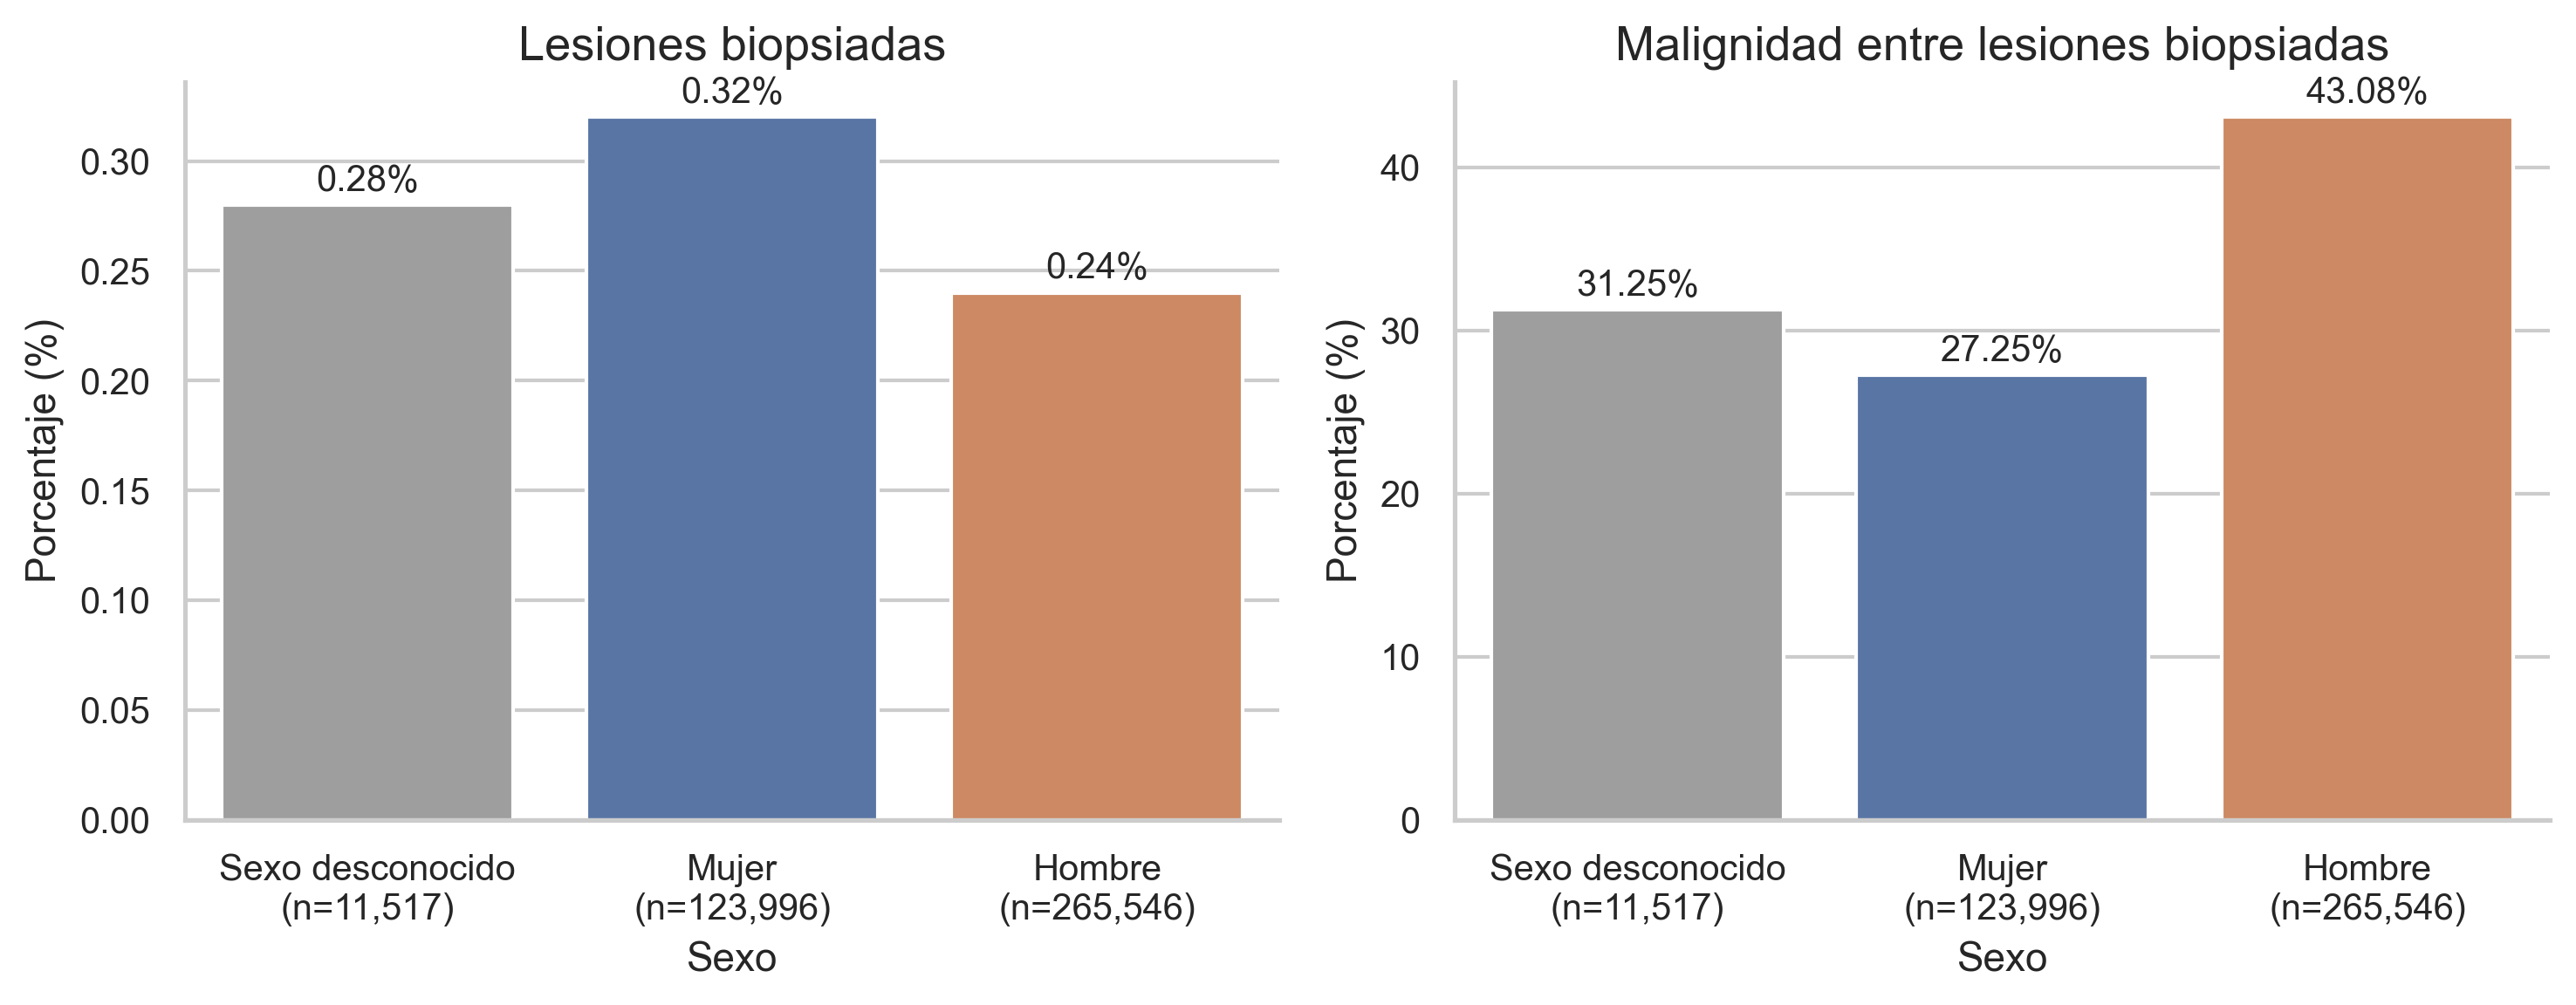

In [78]:
# Predictive value of sex

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

# Biopsy rate
sns.barplot(
    data=sex_predictive_plot_df,
    x="sex_display",
    y="biopsied_pct",
    hue="sex",
    palette=SEX_PALETTE,
    legend=False,
    ax=axes[0],
)

add_bar_labels(
    axes[0],
    fmt="{:.2f}",
    suffix="%",
)

clean_axis_labels(
    axes[0],
    xlabel="Sexo",
    ylabel="Porcentaje (%)",
    title="Lesiones biopsiadas",
)

# Malignancy rate among biopsied lesions
sns.barplot(
    data=sex_predictive_plot_df,
    x="sex_display",
    y="malignant_pct",
    hue="sex",
    palette=SEX_PALETTE,
    legend=False,
    ax=axes[1],
)

add_bar_labels(
    axes[1],
    fmt="{:.2f}",
    suffix="%",
)

clean_axis_labels(
    axes[1],
    xlabel="Sexo",
    ylabel="Porcentaje (%)",
    title="Malignidad entre lesiones biopsiadas",
)

plt.tight_layout()
plt.show()

figures["sex_predictive_value"] = fig

In [ ]:
# save_plot(
#     figures["sex_predictive_value"],
#     name="sex_predictive_value_biopsy_and_malignancy",
#     subfolder="EDA",
# )

#### Missing sex by attribution

In [70]:
# Plot data: missing sex by attribution

sex_missing_attribution_plot_df = attribution_patient_summary.reset_index().copy()

sex_missing_attribution_plot_df["attribution_label"] = simplify_attribution_series(
    sex_missing_attribution_plot_df["attribution"]
)

sex_missing_attribution_plot_df["label"] = (
    sex_missing_attribution_plot_df["pct_missing_patients"].map("{:.2f}%".format)
    + " ("
    + sex_missing_attribution_plot_df["missing_patients"].astype(int).astype(str)
    + "/"
    + sex_missing_attribution_plot_df["n_patients"].astype(int).astype(str)
    + ")"
)

sex_missing_attribution_plot_df = sex_missing_attribution_plot_df.sort_values(
    "pct_missing_patients",
    ascending=True,
)

attribution_legend = (
    sex_missing_attribution_plot_df[["attribution_label", "attribution"]]
    .drop_duplicates()
    .sort_values("attribution_label")
)

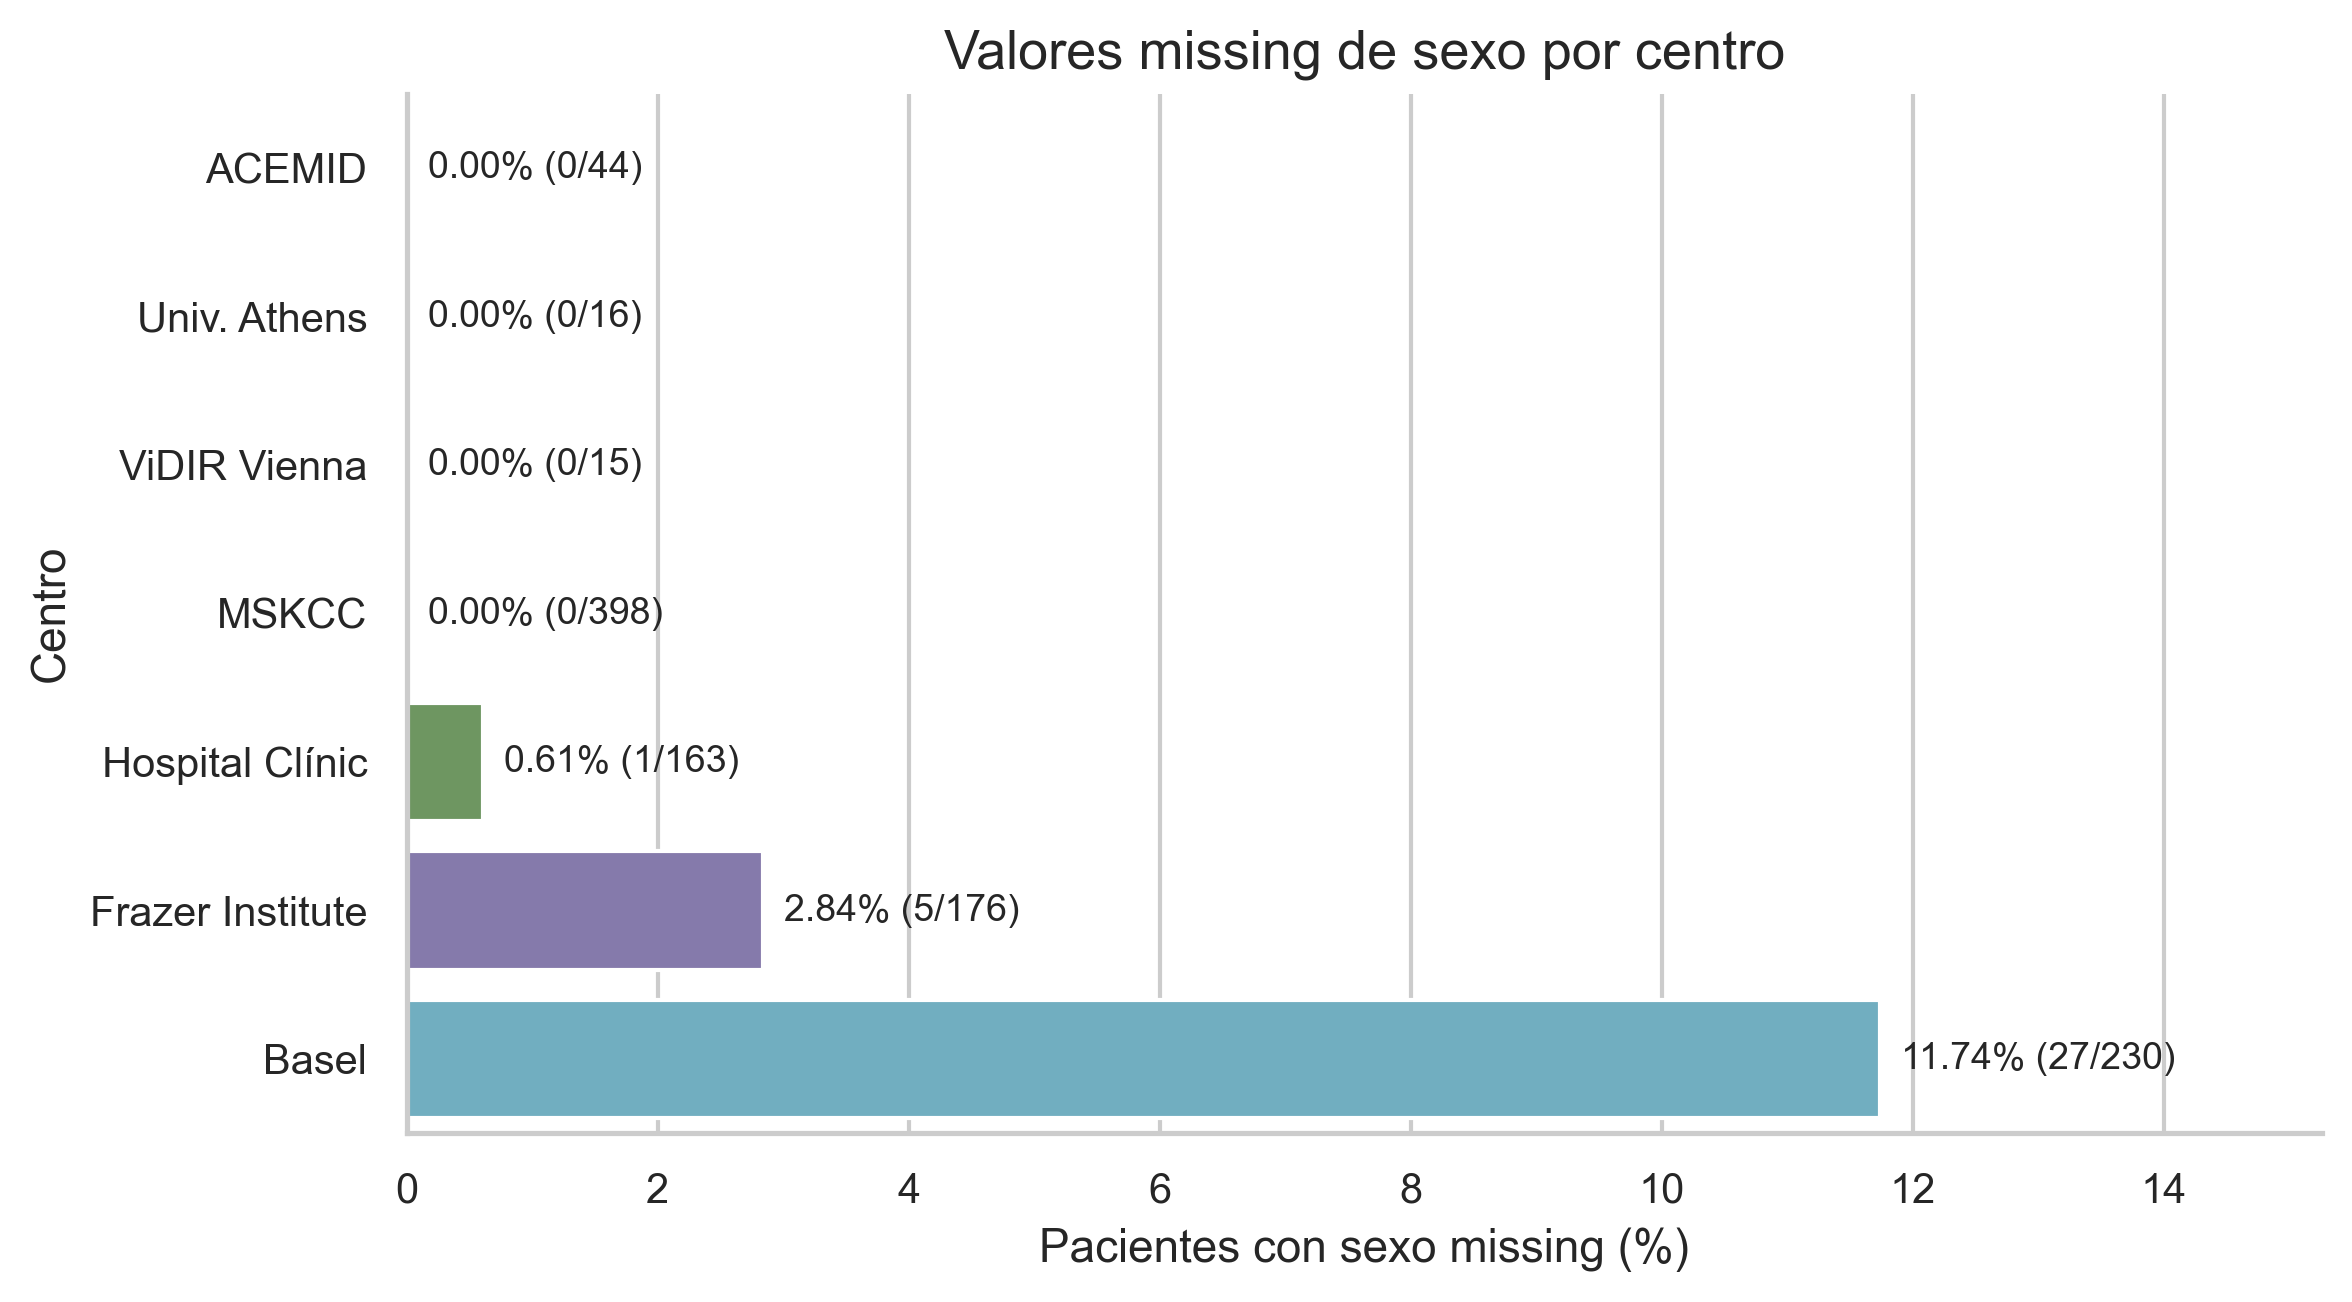

In [75]:
# Missing sex by attribution

fig, ax = plt.subplots(
    figsize=(8, 4.5),
)

sns.barplot(
    data=sex_missing_attribution_plot_df,
    x="pct_missing_patients",
    y="attribution_label",
    hue="attribution_label",
    palette=ATTRIBUTION_PALETTE,
    legend=False,
    ax=ax,
)

# Add percentage and count labels
for patch, (_, row) in zip(
    ax.patches,
    sex_missing_attribution_plot_df.iterrows(),
):
    width = patch.get_width()

    ax.annotate(
        row["label"],
        xy=(
            width,
            patch.get_y() + patch.get_height() / 2,
        ),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

clean_axis_labels(
    ax,
    xlabel="Pacientes con sexo missing (%)",
    ylabel="Centro",
    title="Valores missing de sexo por centro",
)

ax.set_xlim(
    0,
    sex_missing_attribution_plot_df["pct_missing_patients"].max() * 1.30,
)

plt.tight_layout()
plt.show()

figures["sex_missing_attribution"] = fig

# AGE

### 1) BASIC DESCRIPTION

In [80]:
df["age_approx"].dtype

dtype('float64')

In [3]:
df["age_approx"].describe()

count    398261.000000
mean         58.012986
std          13.596165
min           5.000000
25%          50.000000
50%          60.000000
75%          70.000000
max          85.000000
Name: age_approx, dtype: float64

| Atributo               | Valor                                             |
| ---------------------- | ------------------------------------------------- |
| Nombre de la variable  | `age_approx`                                      |
| Tipo de variable       | Cuantitativa                                      |
| Subtipo                | Continua discretizada                             |
| Tipo de almacenamiento | `float`                                           |
| Rango de valores       | 5–85 años                                         |
| Presencia de missing   | Sí (`NA`)                                         |
| Nivel de observación   | Variable de paciente registrada a nivel de lesión |

### 2) MISSING VALUES

| Aspecto evaluado                               | Resultado                                                                       |
| ---------------------------------------------- | ------------------------------------------------------------------------------- |
| Lesiones con `age_approx` missing              | 2,798 / 401,059 (0.70%)                                                         |
| Pacientes afectados                            | 13 / 1,042 (1.25%)                                                              |
| Patrón paciente-lesión                         | Los 13 pacientes presentan edad missing en todas sus lesiones                   |
| Centros afectados                              | Hospital Clínic, Frazer Institute y Basel                                       |
| Solapamiento con `sex` missing                 | 2 pacientes                                                                     |
| Solapamiento con localización missing completa | 2 pacientes                                                                     |
| Composición diagnóstica                        | 2,794 `benign_non_biopsied`, 1 `indeterminate_biopsied`, 3 `malignant_biopsied` |


In [10]:
# Missing-age flag at lesion level
df_age = df.assign(age_missing=df["age_approx"].isna())

# General dataset counts
n_lesions_total = len(df_age)
n_patients_total = df_age["patient_id"].nunique()

# Patients with missing age
patients_missing_age = (
    df_age.loc[df_age["age_missing"], "patient_id"].drop_duplicates().sort_values()
)

n_lesions_missing_age = df_age["age_missing"].sum()
n_patients_missing_age = patients_missing_age.nunique()

patients_missing_age.tolist()

['IP_0212694',
 'IP_0362830',
 'IP_1076642',
 'IP_1129512',
 'IP_3371534',
 'IP_3374234',
 'IP_3647018',
 'IP_6659956',
 'IP_6865940',
 'IP_7013759',
 'IP_7848492',
 'IP_7858959',
 'IP_9652562']

In [12]:
age_missing_patient_pattern = (
    df_age.groupby("patient_id")
    .agg(
        n_lesions=("isic_id", "size"),
        n_lesions_missing_age=("age_missing", "sum"),
    )
    .assign(
        all_lesions_missing_age=lambda x: x["n_lesions"].eq(x["n_lesions_missing_age"])
    )
    .loc[patients_missing_age]
    .reset_index()
)

print(age_missing_patient_pattern)

    patient_id  n_lesions  n_lesions_missing_age  all_lesions_missing_age
0   IP_0212694        319                    319                     True
1   IP_0362830         93                     93                     True
2   IP_1076642         47                     47                     True
3   IP_1129512         53                     53                     True
4   IP_3371534        903                    903                     True
5   IP_3374234          7                      7                     True
6   IP_3647018         86                     86                     True
7   IP_6659956         13                     13                     True
8   IP_6865940         24                     24                     True
9   IP_7013759        369                    369                     True
10  IP_7848492        687                    687                     True
11  IP_7858959          8                      8                     True
12  IP_9652562        189             

In [14]:
age_missing_by_attribution = (
    df_age.groupby("attribution")
    .agg(
        n_lesions_total=("isic_id", "size"),
        n_patients_total=("patient_id", "nunique"),
        n_lesions_missing_age=("age_missing", "sum"),
    )
    .reset_index()
)

# Number of affected patients by institution
missing_patients_by_attribution = (
    df_age.loc[df_age["age_missing"]]
    .groupby("attribution")["patient_id"]
    .nunique()
    .rename("n_patients_missing_age")
    .reset_index()
)

age_missing_by_attribution = (
    age_missing_by_attribution.merge(
        missing_patients_by_attribution,
        on="attribution",
        how="left",
    )
    .fillna({"n_patients_missing_age": 0})
    .assign(
        n_patients_missing_age=lambda x: x["n_patients_missing_age"].astype(int),
        perc_lesions_missing_age=lambda x: 100
        * x["n_lesions_missing_age"]
        / x["n_lesions_total"],
        perc_patients_missing_age=lambda x: 100
        * x["n_patients_missing_age"]
        / x["n_patients_total"],
    )
    .sort_values("perc_patients_missing_age", ascending=False)
)

print(age_missing_by_attribution)

                                         attribution  n_lesions_total  \
3  Frazer Institute, The University of Queensland...            51768   
1  Department of Dermatology, Hospital Clínic de ...           105724   
5                       University Hospital of Basel            65218   
2  Department of Dermatology, University of Athen...             7976   
0                                         ACEMID MIA            28665   
4             Memorial Sloan Kettering Cancer Center           129068   
6  ViDIR Group, Department of Dermatology, Medica...            12640   

   n_patients_total  n_lesions_missing_age  n_patients_missing_age  \
3               176                   1205                       5   
1               163                   1461                       4   
5               230                    132                       4   
2                16                      0                       0   
0                44                      0                       

In [15]:
patients_missing_sex = set(df_age.loc[df_age["sex"].isna(), "patient_id"].unique())

patients_missing_age_set = set(patients_missing_age)

patients_missing_age_and_sex = sorted(patients_missing_age_set & patients_missing_sex)

print(patients_missing_age_and_sex)

['IP_3371534', 'IP_7858959']


In [16]:
anatom_site_missing_by_patient = df_age.groupby("patient_id")[
    "anatom_site_general"
].agg(
    n_lesions="size",
    n_missing=lambda x: x.isna().sum(),
)

patients_all_anatom_site_missing = set(
    anatom_site_missing_by_patient.query("n_lesions == n_missing").index
)

patients_missing_age_and_anatom_site = sorted(
    patients_missing_age_set & patients_all_anatom_site_missing
)

print(patients_missing_age_and_anatom_site)

['IP_3374234', 'IP_7858959']


In [17]:
age_missing_diagnostic_summary = (
    df_age.loc[df_age["age_missing"]]
    .groupby("diagnostic_group")
    .size()
    .rename("n_lesions")
    .reset_index()
    .assign(percentage=lambda x: 100 * x["n_lesions"] / x["n_lesions"].sum())
    .sort_values("n_lesions", ascending=False)
)

print(age_missing_diagnostic_summary)

         diagnostic_group  n_lesions  percentage
1     benign_non_biopsied       2790   99.714081
0         benign_biopsied          4    0.142959
3      malignant_biopsied          3    0.107219
2  indeterminate_biopsied          1    0.035740


In [20]:
df_age = df_age.assign(
    biopsy_target=np.where(
        df_age["diagnostic_group"].eq("benign_non_biopsied"),
        "non_biopsied_benign",
        "biopsied",
    )
)

age_missing_impact_h1 = (
    df_age.groupby("biopsy_target")
    .agg(
        n_lesions_total=("isic_id", "size"),
        n_lesions_removed=("age_missing", "sum"),
        n_patients_total=("patient_id", "nunique"),
    )
    .reset_index()
)

h1_patients_removed = (
    df_age.loc[df_age["age_missing"]]
    .groupby("biopsy_target")["patient_id"]
    .nunique()
    .rename("n_patients_removed")
    .reset_index()
)

age_missing_impact_h1 = (
    age_missing_impact_h1.merge(h1_patients_removed, on="biopsy_target", how="left")
    .fillna({"n_patients_removed": 0})
    .assign(
        n_patients_removed=lambda x: x["n_patients_removed"].astype(int),
        perc_lesions_removed=lambda x: 100
        * x["n_lesions_removed"]
        / x["n_lesions_total"],
        perc_patients_removed=lambda x: 100
        * x["n_patients_removed"]
        / x["n_patients_total"],
    )
)

print(age_missing_impact_h1)

         biopsy_target  n_lesions_total  n_lesions_removed  n_patients_total  \
0             biopsied             1068                  8               660   
1  non_biopsied_benign           399991               2790              1040   

   n_patients_removed  perc_lesions_removed  perc_patients_removed  
0                   5              0.749064               0.757576  
1                  13              0.697516               1.250000  


In [21]:
df_biopsied_age = df_age.loc[
    df_age["diagnostic_group"].isin(
        [
            "benign_biopsied",
            "indeterminate_biopsied",
            "malignant_biopsied",
        ]
    )
].assign(
    malignancy_target=lambda x: np.where(
        x["diagnostic_group"].eq("malignant_biopsied"),
        "malignant",
        "non_malignant",
    )
)

age_missing_impact_h2 = (
    df_biopsied_age.groupby("malignancy_target")
    .agg(
        n_lesions_total=("isic_id", "size"),
        n_lesions_removed=("age_missing", "sum"),
        n_patients_total=("patient_id", "nunique"),
    )
    .reset_index()
)

h2_patients_removed = (
    df_biopsied_age.loc[df_biopsied_age["age_missing"]]
    .groupby("malignancy_target")["patient_id"]
    .nunique()
    .rename("n_patients_removed")
    .reset_index()
)

age_missing_impact_h2 = (
    age_missing_impact_h2.merge(h2_patients_removed, on="malignancy_target", how="left")
    .fillna({"n_patients_removed": 0})
    .assign(
        n_patients_removed=lambda x: x["n_patients_removed"].astype(int),
        perc_lesions_removed=lambda x: 100
        * x["n_lesions_removed"]
        / x["n_lesions_total"],
        perc_patients_removed=lambda x: 100
        * x["n_patients_removed"]
        / x["n_patients_total"],
    )
)

print(age_missing_impact_h2)

  malignancy_target  n_lesions_total  n_lesions_removed  n_patients_total  \
0         malignant              393                  3               259   
1     non_malignant              675                  5               475   

   n_patients_removed  perc_lesions_removed  perc_patients_removed  
0                   3              0.763359               1.158301  
1                   2              0.740741               0.421053  


In [30]:
# Patient-level dataset for missingness analysis

patient_level = (
    df_age.groupby("patient_id")
    .agg(
        age_missing=("age_missing", "all"),
        attribution=("attribution", "first"),
        sex=("sex", "first"),
        n_lesions=("isic_id", "size"),
        diagnostic_group_mode=(
            "diagnostic_group",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
        ),
        all_anatom_site_missing=(
            "anatom_site_general",
            lambda x: x.isna().all(),
        ),
    )
    .reset_index()
)

patient_level["sex_missing"] = patient_level["sex"].isna()

# Comparison of missing-age vs available-age patients

missingness_comparison = pd.DataFrame(
    {
        "Metric": [
            "Number of patients",
            "Median lesions per patient",
            "IQR lesions per patient",
            "Sex missing (%)",
            "Anatomical site missing in all lesions (%)",
        ],
        "Age available": [
            (~patient_level["age_missing"]).sum(),
            patient_level.loc[~patient_level["age_missing"], "n_lesions"].median(),
            (
                patient_level.loc[~patient_level["age_missing"], "n_lesions"].quantile(
                    0.75
                )
                - patient_level.loc[
                    ~patient_level["age_missing"], "n_lesions"
                ].quantile(0.25)
            ),
            100
            * patient_level.loc[~patient_level["age_missing"], "sex_missing"].mean(),
            100
            * patient_level.loc[
                ~patient_level["age_missing"], "all_anatom_site_missing"
            ].mean(),
        ],
        "Age missing": [
            patient_level["age_missing"].sum(),
            patient_level.loc[patient_level["age_missing"], "n_lesions"].median(),
            (
                patient_level.loc[patient_level["age_missing"], "n_lesions"].quantile(
                    0.75
                )
                - patient_level.loc[patient_level["age_missing"], "n_lesions"].quantile(
                    0.25
                )
            ),
            100 * patient_level.loc[patient_level["age_missing"], "sex_missing"].mean(),
            100
            * patient_level.loc[
                patient_level["age_missing"], "all_anatom_site_missing"
            ].mean(),
        ],
    }
)

print(missingness_comparison)

                                       Metric  Age available  Age missing
0                          Number of patients    1029.000000    13.000000
1                  Median lesions per patient     242.000000    86.000000
2                     IQR lesions per patient     363.000000   295.000000
3                             Sex missing (%)       3.012634    15.384615
4  Anatomical site missing in all lesions (%)       0.874636    15.384615


In [32]:
# Distribution by dominant diagnostic group

age_missing_by_diagnostic_group = (
    patient_level.groupby(["diagnostic_group_mode", "age_missing"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "age_available", True: "age_missing"})
)

age_missing_by_diagnostic_group["total"] = (
    age_missing_by_diagnostic_group["age_available"]
    + age_missing_by_diagnostic_group["age_missing"]
)

age_missing_by_diagnostic_group["perc_age_missing"] = (
    100
    * age_missing_by_diagnostic_group["age_missing"]
    / age_missing_by_diagnostic_group["total"]
)

age_missing_by_diagnostic_group.sort_values(
    "perc_age_missing",
    ascending=False,
)

print(age_missing_by_diagnostic_group)

age_missing            age_available  age_missing  total  perc_age_missing
diagnostic_group_mode                                                     
benign_non_biopsied             1027           13   1040              1.25
malignant_biopsied                 2            0      2              0.00


#### Análisis de valores missing en `age_approx`

| Nivel de análisis            |                  Total | Registros con `age_approx` missing | % missing | Comentario                                                        |
| ---------------------------- | ---------------------: | ---------------------------------: | --------: | ----------------------------------------------------------------- |
| Lesión                       |                401,059 |                              2,798 |     0.70% | Lesiones sin información sobre la edad aproximada del paciente    |
| Paciente                     |                  1,042 |                                 13 |     1.25% | Pacientes sin ninguna edad registrada                             |
| Consistencia paciente-lesión | 13 pacientes afectados |  13 con todas sus lesiones missing |   100.00% | La ausencia de edad es completa y consistente dentro del paciente |

La variable `age_approx` presenta valores *missing* en 2,798 lesiones, equivalentes al 0.70% del conjunto de datos. A nivel de paciente, estos registros corresponden a 13 de los 1,042 pacientes disponibles, lo que representa un 1.25% de la cohorte.

Dado que la edad es una característica del paciente registrada en el momento de adquisición de cada lesión, se evaluó la consistencia de su ausencia dentro de cada individuo. Los 13 pacientes afectados presentan `age_approx` missing en la totalidad de sus lesiones, sin observarse ningún caso de ausencia parcial. Por tanto, la información no puede recuperarse utilizando otras lesiones del mismo paciente.

#### Exploración del mecanismo de missingness

La ausencia de edad no se distribuye homogéneamente entre las distintas fuentes de datos. Los 13 pacientes afectados proceden exclusivamente de tres instituciones:

| Institución                                     | Pacientes con edad missing | Pacientes totales | % de pacientes afectados | Lesiones con edad missing |
| ----------------------------------------------- | -------------------------: | ----------------: | -----------------------: | ------------------------: |
| Frazer Institute / The University of Queensland |                          5 |               176 |                    2.84% |                     1,205 |
| Hospital Clínic de Barcelona                    |                          4 |               163 |                    2.45% |                     1,461 |
| University Hospital of Basel                    |                          4 |               230 |                    1.74% |                       132 |

Los cuatro centros restantes no presentan ningún paciente con información de edad ausente. Esta concentración por institución sugiere que el missingness podría estar relacionado con diferencias en los procedimientos de recogida, anonimización o integración de los datos.

Además, se compararon algunas características observadas entre los pacientes con edad disponible y los pacientes con edad missing:

| Característica                                                     | Edad disponible | Edad missing |
| ------------------------------------------------------------------ | --------------: | -----------: |
| Número de pacientes                                                |           1,029 |           13 |
| Mediana de lesiones por paciente                                   |             242 |           86 |
| IQR de lesiones por paciente                                       |             363 |          295 |
| Pacientes con `sex` missing                                        |           3.01% |       15.38% |
| Pacientes con localización anatómica missing en todas sus lesiones |           0.87% |       15.38% |

Los pacientes con edad missing presentan con mayor frecuencia ausencia simultánea de información en `sex` y en la localización anatómica. Esto refuerza la hipótesis de que la falta de edad forma parte de un problema más general de completitud de metadatos en determinados pacientes o fuentes de datos, y no de una ausencia aislada de esta variable.

El número de lesiones por paciente también es inferior en el grupo con edad missing, aunque existe una variabilidad considerable dentro de ambos grupos. Dado el reducido número de pacientes afectados, esta diferencia debe interpretarse con cautela.

En cuanto a la composición diagnóstica, las 2,798 lesiones afectadas se distribuyen de la siguiente manera:

| Categoría diagnóstica    | Lesiones | Porcentaje |
| ------------------------ | -------: | ---------: |
| `benign_non_biopsied`    |    2,794 |     99.86% |
| `indeterminate_biopsied` |        1 |      0.04% |
| `malignant_biopsied`     |        3 |      0.11% |
| `benign_biopsied`        |        0 |      0.00% |

Por tanto, la ausencia de edad se concentra casi exclusivamente en lesiones benignas no biopsiadas. No obstante, esta distribución debe interpretarse teniendo en cuenta el fuerte predominio de esta categoría en el conjunto de datos completo.

#### Tipo de missingness probable

No es posible determinar de forma definitiva el mecanismo de missingness únicamente a partir de los datos observados. En particular, no puede evaluarse si la probabilidad de ausencia depende de la edad real, ya que esta no se conoce en los pacientes afectados.

Sin embargo, los resultados muestran que:

* los valores missing están concentrados en determinadas instituciones;
* existe un mayor solapamiento con otras variables missing;
* la ausencia es completa a nivel de paciente;
* no parece tratarse de errores aislados a nivel de lesión.

Por tanto, el patrón observado no parece compatible con un mecanismo estrictamente **Missing Completely At Random (MCAR)**. Los resultados son más consistentes con un mecanismo **Missing At Random (MAR)** condicionado por variables observadas, principalmente `attribution` y la disponibilidad general de metadatos.

No obstante, esta clasificación debe considerarse una hipótesis razonable y no una demostración formal. Tampoco puede descartarse completamente un componente **Missing Not At Random (MNAR)** relacionado con características no observadas o con el proceso original de recogida de la edad.

#### Posibles estrategias de tratamiento

Una primera opción sería imputar la edad utilizando información observada, por ejemplo:

* la mediana de edad global;
* la mediana de edad del centro de procedencia;
* un modelo de imputación basado en `attribution`, `sex`, localización anatómica y otras variables clínicas;
* imputación múltiple para incorporar la incertidumbre asociada.

Sin embargo, en este caso la imputación presenta varias limitaciones. La edad está completamente ausente para todas las lesiones de los pacientes afectados, por lo que no existe información longitudinal o intra-paciente que permita recuperarla. Además, la fuerte discretización de la variable y la concentración del missingness por centro podrían hacer que una imputación simple introdujera valores artificiales excesivamente determinados por la fuente de datos.

La segunda opción es excluir los 13 pacientes afectados. El impacto global de esta decisión sería reducido:

| Escenario                                | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ---------------------------------------- | ------------: | ------------: | -----------: | -----------: |
| Dataset original                         |         1,042 |       100.00% |      401,059 |      100.00% |
| Tras eliminar pacientes con edad missing |         1,029 |        98.75% |      398,261 |       99.30% |
| Registros eliminados                     |            13 |         1.25% |        2,798 |        0.70% |

Respecto a las hipótesis de modelado:

* En el modelo de recomendación de biopsia se eliminarían 2,794 lesiones de la clase `benign_non_biopsied` y únicamente 4 lesiones de la clase biopsiada.
* En el modelo de malignidad restringido a lesiones biopsiadas se eliminarían 1 lesión no maligna y 3 lesiones malignas.

#### Decisión propuesta

Dado el pequeño número de pacientes afectados, la ausencia completa de edad dentro de cada paciente, la imposibilidad de recuperar la variable a partir de otras lesiones del mismo individuo y la pérdida global limitada de información, la exclusión de estos 13 pacientes constituye una estrategia de preprocesamiento razonable.

Esta decisión evita introducir edades artificiales mediante imputación y simplifica la construcción de una cohorte con metadatos completos. No obstante, antes de aplicarla definitivamente, deberá verificarse que la eliminación de las tres lesiones malignas no produzca un cambio relevante en la distribución de clases del modelo secundario de malignidad.

Por motivos de trazabilidad, los pacientes afectados son:

`IP_0212694`, `IP_0362830`, `IP_1076642`, `IP_1129512`, `IP_3371534`, `IP_3374234`, `IP_3647018`, `IP_6659956`, `IP_6865940`, `IP_7013759`, `IP_7848492`, `IP_7858959` e `IP_9652562`.


### 3) DISTRIBUTION AND CLASSIFCIATION

In [35]:
# Patient-level age summary

patient_age = (
    df.groupby("patient_id")
    .agg(
        age_min=("age_approx", "min"),
        age_max=("age_approx", "max"),
        n_unique_ages=("age_approx", lambda x: x.nunique(dropna=True)),
        n_lesions=("isic_id", "size"),
    )
    .reset_index()
)

patient_age["age_range"] = patient_age["age_max"] - patient_age["age_min"]

# Representative age for patient-level analyses
patient_age["age_patient"] = patient_age[["age_min", "age_max"]].mean(axis=1)

# Consistency checks

age_consistency_summary = (
    patient_age["n_unique_ages"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("n_unique_ages")
    .reset_index(name="n_patients")
)

age_consistency_summary["percentage"] = (
    100 * age_consistency_summary["n_patients"] / patient_age["patient_id"].nunique()
).round(2)

print(age_consistency_summary)

   n_unique_ages  n_patients  percentage
0              0          13        1.25
1              1         929       89.16
2              2         100        9.60


In [36]:
def summarize_numeric(series: pd.Series, level: str) -> pd.DataFrame:
    """Return a complete descriptive summary for a numeric variable."""

    values = series.dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    return pd.DataFrame(
        {
            "level": [level],
            "n": [values.size],
            "missing": [series.isna().sum()],
            "n_unique": [values.nunique()],
            "mean": [values.mean()],
            "std": [values.std()],
            "min": [values.min()],
            "q1": [q1],
            "median": [values.median()],
            "q3": [q3],
            "max": [values.max()],
            "iqr": [q3 - q1],
            "skewness": [values.skew()],
            "kurtosis": [values.kurt()],
        }
    )

In [37]:
age_descriptive_summary = pd.concat(
    [
        summarize_numeric(df["age_approx"], level="Lesion level"),
        summarize_numeric(patient_age["age_patient"], level="Patient level"),
    ],
    ignore_index=True,
).round(2)

print(age_descriptive_summary)

           level       n  missing  n_unique   mean    std  min    q1  median  \
0   Lesion level  398261     2798        16  58.01  13.60  5.0  50.0    60.0   
1  Patient level    1029       13        29  52.61  14.92  5.0  40.0    55.0   

     q3   max   iqr  skewness  kurtosis  
0  70.0  85.0  20.0     -0.26     -0.29  
1  65.0  85.0  25.0     -0.20     -0.46  


In [38]:
age_distribution_patient = (
    patient_age["age_patient"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("age")
    .reset_index(name="n_patients")
)

age_distribution_patient["percentage"] = (
    100
    * age_distribution_patient["n_patients"]
    / age_distribution_patient["n_patients"].sum()
).round(2)

print(age_distribution_patient)

     age  n_patients  percentage
0    5.0           1        0.10
1   15.0           7        0.67
2   20.0          16        1.54
3   22.5           3        0.29
4   25.0          25        2.40
5   27.5           1        0.10
6   30.0          55        5.28
7   32.5           1        0.10
8   35.0          58        5.57
9   37.5           4        0.38
10  40.0         103        9.88
11  42.5          10        0.96
12  45.0          75        7.20
13  47.5          12        1.15
14  50.0         107       10.27
15  52.5          13        1.25
16  55.0         119       11.42
17  57.5          19        1.82
18  60.0         104        9.98
19  62.5          16        1.54
20  65.0         113       10.84
21  67.5           9        0.86
22  70.0          67        6.43
23  72.5           6        0.58
24  75.0          40        3.84
25  77.5           5        0.48
26  80.0          28        2.69
27  82.5           1        0.10
28  85.0          11        1.06
29   NaN  

In [104]:
# Unique IDs of patients under 18 years old

underage_patient_ids = (
    patient_age.loc[
        patient_age["age_patient"] < 18,
        "patient_id",
    ]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

underage_patient_ids

['IP_1216329',
 'IP_1510720',
 'IP_3316592',
 'IP_3658490',
 'IP_3772472',
 'IP_3909069',
 'IP_5373245',
 'IP_8911703']

In [105]:
# Lesions belonging to underage patients

underage_lesions = df.loc[df["patient_id"].isin(underage_patient_ids)].copy()

n_underage_patients = underage_lesions["patient_id"].nunique()
n_underage_lesions = len(underage_lesions)

print(f"Underage patients: {n_underage_patients}")
print(f"Underage lesions: {n_underage_lesions}")

Underage patients: 8
Underage lesions: 645


In [107]:
# Diagnostic distribution among lesions from underage patients

underage_diagnostic_summary = (
    underage_lesions["diagnostic_group"]
    .value_counts(dropna=False)
    .rename_axis("diagnostic_group")
    .reset_index(name="n_lesions")
)

underage_diagnostic_summary["percentage"] = (
    100
    * underage_diagnostic_summary["n_lesions"]
    / underage_diagnostic_summary["n_lesions"].sum()
).round(2)

print(underage_diagnostic_summary)

      diagnostic_group  n_lesions  percentage
0  benign_non_biopsied        644       99.84
1      benign_biopsied          1        0.16


In [39]:
age_distribution_lesion = (
    df["age_approx"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("age")
    .reset_index(name="n_lesions")
)

age_distribution_lesion["percentage"] = (
    100
    * age_distribution_lesion["n_lesions"]
    / age_distribution_lesion["n_lesions"].sum()
).round(2)

print(age_distribution_lesion)

     age  n_lesions  percentage
0    5.0          1        0.00
1   15.0        644        0.16
2   20.0       1742        0.43
3   25.0       3433        0.86
4   30.0      10400        2.59
5   35.0      11543        2.88
6   40.0      31297        7.80
7   45.0      23580        5.88
8   50.0      47924       11.95
9   55.0      58123       14.49
10  60.0      54109       13.49
11  65.0      54946       13.70
12  70.0      39775        9.92
13  75.0      30801        7.68
14  80.0      21096        5.26
15  85.0       8847        2.21
16   NaN       2798        0.70


In [40]:
def detect_iqr_outliers(series: pd.Series) -> dict:
    """Identify outliers using the 1.5 × IQR rule."""

    values = series.dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = values[(values < lower_bound) | (values > upper_bound)]

    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": len(outliers),
        "percentage_outliers": 100 * len(outliers) / len(values),
        "outlier_values": sorted(outliers.unique()),
    }

In [41]:
age_outliers_lesion = detect_iqr_outliers(df["age_approx"])
age_outliers_patient = detect_iqr_outliers(patient_age["age_patient"])

age_outlier_summary = pd.DataFrame(
    [
        {"level": "Lesion level", **age_outliers_lesion},
        {"level": "Patient level", **age_outliers_patient},
    ]
)

print(age_outlier_summary)

           level    q1    q3   iqr  lower_bound  upper_bound  n_outliers  \
0   Lesion level  50.0  70.0  20.0         20.0        100.0         645   
1  Patient level  40.0  65.0  25.0          2.5        102.5           0   

   percentage_outliers outlier_values  
0             0.161954    [5.0, 15.0]  
1             0.000000             []  


In [44]:
df_age_model = df.loc[df["age_approx"].notna()].copy()

In [48]:
# Hypothesis 1: biopsy recommendation

df_age_model["biopsy_target"] = np.where(
    df_age_model["diagnostic_group"].eq("benign_non_biopsied"),
    0,
    1,
)

df_age_model["biopsy_group"] = np.where(
    df_age_model["biopsy_target"].eq(0),
    "Non-biopsied benign",
    "Biopsied",
)

In [49]:
# Hypothesis 2: malignancy classification among biopsied lesions

df_age_biopsied = df_age_model.loc[
    df_age_model["diagnostic_group"].isin(
        [
            "benign_biopsied",
            "indeterminate_biopsied",
            "malignant_biopsied",
        ]
    )
].copy()

df_age_biopsied["malignancy_target"] = np.where(
    df_age_biopsied["diagnostic_group"].eq("malignant_biopsied"),
    1,
    0,
)

df_age_biopsied["malignancy_group"] = np.where(
    df_age_biopsied["malignancy_target"].eq(1),
    "Malignant",
    "Non-malignant",
)

In [50]:
def summarize_age_by_group(
    data: pd.DataFrame,
    group_col: str,
    cohort_name: str,
) -> pd.DataFrame:
    """Summarize age distribution by classification group."""

    return (
        data.groupby(group_col)["age_approx"]
        .agg(
            n="size",
            mean="mean",
            std="std",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            min="min",
            max="max",
            skewness="skew",
        )
        .reset_index()
        .assign(
            iqr=lambda x: x["q3"] - x["q1"],
            cohort=cohort_name,
        )
    )

In [52]:
age_summary_h1 = summarize_age_by_group(
    data=df_age_model,
    group_col="biopsy_group",
    cohort_name="Hypothesis 1",
)

age_summary_h2 = summarize_age_by_group(
    data=df_age_biopsied,
    group_col="malignancy_group",
    cohort_name="Hypothesis 2",
)

age_summary_models = pd.concat(
    [age_summary_h1, age_summary_h2], ignore_index=True
).round(2)

print(age_summary_models)

          biopsy_group       n   mean    std  median    q1    q3   min   max  \
0             Biopsied    1060  54.67  14.01    55.0  45.0  65.0  15.0  85.0   
1  Non-biopsied benign  397201  58.02  13.59    60.0  50.0  70.0   5.0  85.0   
2                  NaN     390  61.37  11.93    60.0  55.0  70.0  20.0  85.0   
3                  NaN     670  50.76  13.66    50.0  40.0  60.0  15.0  85.0   

   skewness   iqr        cohort malignancy_group  
0     -0.24  20.0  Hypothesis 1              NaN  
1     -0.26  20.0  Hypothesis 1              NaN  
2     -0.31  15.0  Hypothesis 2        Malignant  
3     -0.14  20.0  Hypothesis 2    Non-malignant  


In [59]:
def rank_biserial_from_mannwhitney(
    group_0: pd.Series,
    group_1: pd.Series,
) -> float:
    """Compute rank-biserial correlation from Mann–Whitney U."""

    x = group_0.dropna()
    y = group_1.dropna()

    u_statistic, _ = stats.mannwhitneyu(
        x,
        y,
        alternative="two-sided",
    )

    return 1 - (2 * u_statistic) / (len(x) * len(y))

In [58]:
def compare_age_groups(
    data: pd.DataFrame,
    target_col: str,
    hypothesis: str,
) -> pd.DataFrame:
    """Compare age between binary target groups."""

    group_0 = data.loc[data[target_col] == 0, "age_approx"]

    group_1 = data.loc[data[target_col] == 1, "age_approx"]

    mann_whitney = stats.mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided",
    )

    point_biserial = stats.pointbiserialr(
        data[target_col],
        data["age_approx"],
    )

    spearman = stats.spearmanr(
        data["age_approx"],
        data[target_col],
    )

    return pd.DataFrame(
        {
            "hypothesis": [hypothesis],
            "n_group_0": [len(group_0)],
            "n_group_1": [len(group_1)],
            "median_group_0": [group_0.median()],
            "median_group_1": [group_1.median()],
            "mann_whitney_u": [mann_whitney.statistic],
            "mann_whitney_p": [mann_whitney.pvalue],
            "rank_biserial_correlation": [
                rank_biserial_from_mannwhitney(
                    group_0,
                    group_1,
                )
            ],
            "point_biserial_r": [point_biserial.statistic],
            "point_biserial_p": [point_biserial.pvalue],
            "spearman_rho": [spearman.statistic],
            "spearman_p": [spearman.pvalue],
        }
    )

In [61]:
age_association_results = pd.concat(
    [
        compare_age_groups(
            data=df_age_model,
            target_col="biopsy_target",
            hypothesis="Hypothesis 1: biopsy recommendation",
        ),
        compare_age_groups(
            data=df_age_biopsied,
            target_col="malignancy_target",
            hypothesis="Hypothesis 2: malignancy classification",
        ),
    ],
    ignore_index=True,
).round(4)

print(age_association_results)

                                hypothesis  n_group_0  n_group_1  \
0      Hypothesis 1: biopsy recommendation     397201       1060   
1  Hypothesis 2: malignancy classification        670        390   

   median_group_0  median_group_1  mann_whitney_u  mann_whitney_p  \
0            60.0            55.0     237906852.0             0.0   
1            50.0            60.0         74257.0             0.0   

   rank_biserial_correlation  point_biserial_r  point_biserial_p  \
0                    -0.1301           -0.0127               0.0   
1                     0.4316            0.3653               0.0   

   spearman_rho  spearman_p  
0       -0.0117         0.0  
1        0.3627         0.0  


In [62]:
age_biopsy_rate = (
    df_age_model.groupby("age_approx")
    .agg(
        n_lesions=("isic_id", "size"),
        n_biopsied=("biopsy_target", "sum"),
        biopsy_rate=("biopsy_target", "mean"),
        n_patients=("patient_id", "nunique"),
    )
    .reset_index()
)

age_biopsy_rate["biopsy_rate_percentage"] = 100 * age_biopsy_rate["biopsy_rate"]

print(age_biopsy_rate)

    age_approx  n_lesions  n_biopsied  biopsy_rate  n_patients  \
0          5.0          1           0     0.000000           1   
1         15.0        644           1     0.001553           7   
2         20.0       1742          10     0.005741          19   
3         25.0       3433          28     0.008156          29   
4         30.0      10400          40     0.003846          57   
5         35.0      11543          44     0.003812          63   
6         40.0      31297         103     0.003291         117   
7         45.0      23580          90     0.003817          97   
8         50.0      47924         115     0.002400         132   
9         55.0      58123         146     0.002512         151   
10        60.0      54109         152     0.002809         139   
11        65.0      54946         145     0.002639         138   
12        70.0      39775          96     0.002414          82   
13        75.0      30801          42     0.001364          51   
14        

In [63]:
age_malignancy_rate = (
    df_age_biopsied.groupby("age_approx")
    .agg(
        n_biopsied_lesions=("isic_id", "size"),
        n_malignant=("malignancy_target", "sum"),
        malignancy_rate=("malignancy_target", "mean"),
        n_patients=("patient_id", "nunique"),
    )
    .reset_index()
)

age_malignancy_rate["malignancy_rate_percentage"] = (
    100 * age_malignancy_rate["malignancy_rate"]
)

print(age_malignancy_rate)

    age_approx  n_biopsied_lesions  n_malignant  malignancy_rate  n_patients  \
0         15.0                   1            0         0.000000           1   
1         20.0                  10            1         0.100000           9   
2         25.0                  28            2         0.071429          18   
3         30.0                  40            3         0.075000          27   
4         35.0                  44            4         0.090909          31   
5         40.0                 103           15         0.145631          73   
6         45.0                  90           27         0.300000          65   
7         50.0                 115           27         0.234783          78   
8         55.0                 146           46         0.315068          96   
9         60.0                 152           86         0.565789          84   
10        65.0                 145           67         0.462069          93   
11        70.0                  96      

In [65]:
def add_wilson_interval(
    table: pd.DataFrame,
    successes_col: str,
    total_col: str,
) -> pd.DataFrame:
    """Add Wilson 95% confidence intervals for proportions."""

    result = table.copy()

    proportion = result[successes_col] / result[total_col]

    z = 1.96
    denominator = 1 + (z**2 / result[total_col])

    centre = (proportion + z**2 / (2 * result[total_col])) / denominator

    margin = (
        z
        * np.sqrt(
            proportion * (1 - proportion) / result[total_col]
            + z**2 / (4 * result[total_col] ** 2)
        )
        / denominator
    )

    result["ci_lower"] = 100 * (centre - margin)
    result["ci_upper"] = 100 * (centre + margin)

    return result

In [66]:
age_biopsy_rate = add_wilson_interval(
    table=age_biopsy_rate,
    successes_col="n_biopsied",
    total_col="n_lesions",
)

age_malignancy_rate = add_wilson_interval(
    table=age_malignancy_rate,
    successes_col="n_malignant",
    total_col="n_biopsied_lesions",
)
print(age_biopsy_rate)
print(age_malignancy_rate)

    age_approx  n_lesions  n_biopsied  biopsy_rate  n_patients  \
0          5.0          1           0     0.000000           1   
1         15.0        644           1     0.001553           7   
2         20.0       1742          10     0.005741          19   
3         25.0       3433          28     0.008156          29   
4         30.0      10400          40     0.003846          57   
5         35.0      11543          44     0.003812          63   
6         40.0      31297         103     0.003291         117   
7         45.0      23580          90     0.003817          97   
8         50.0      47924         115     0.002400         132   
9         55.0      58123         146     0.002512         151   
10        60.0      54109         152     0.002809         139   
11        65.0      54946         145     0.002639         138   
12        70.0      39775          96     0.002414          82   
13        75.0      30801          42     0.001364          51   
14        

#### Consistencia y nivel de análisis

La variable `age_approx` representa la edad aproximada del paciente en el momento de adquisición de la imagen. Aunque es una característica del paciente, se encuentra registrada a nivel de lesión.

De los 1,042 pacientes incluidos en el conjunto de datos:

* 13 pacientes presentan la edad ausente en todas sus lesiones.
* 929 pacientes presentan un único valor de edad.
* 100 pacientes presentan dos valores de edad distintos, siempre separados por exactamente cinco años.

Estas diferencias son compatibles con imágenes obtenidas durante visitas o periodos de seguimiento diferentes. Por este motivo, se utilizarán dos representaciones de la edad:

* **Análisis y modelado a nivel de lesión:** se conservará el valor original de `age_approx` asociado a cada imagen, ya que representa la edad aproximada del paciente en el momento de adquisición.
* **Análisis descriptivo a nivel de paciente:** se utilizará una única edad representativa. En los pacientes con dos valores, se empleará el punto medio del intervalo para evitar contabilizar al mismo individuo en dos grupos de edad.

#### Estadísticos descriptivos

| Nivel de análisis | n válido | Missing | Valores únicos | Media |    DE | Mediana |   Q1 |   Q3 |  IQR | Mínimo | Máximo | Skewness | Kurtosis |
| ----------------- | -------: | ------: | -------------: | ----: | ----: | ------: | ---: | ---: | ---: | -----: | -----: | -------: | -------: |
| Lesión            |  398,261 |   2,798 |             16 | 58.01 | 13.60 |    60.0 | 50.0 | 70.0 | 20.0 |    5.0 |   85.0 |    -0.26 |    -0.29 |
| Paciente          |    1,029 |      13 |             29 | 52.61 | 14.92 |    55.0 | 40.0 | 65.0 | 25.0 |    5.0 |   85.0 |    -0.20 |    -0.46 |

La diferencia entre los resúmenes a nivel de lesión y de paciente es relevante. La edad media es superior a nivel de lesión, 58.01 frente a 52.61 años, lo que indica que los pacientes de mayor edad aportan, en promedio, un mayor número de imágenes. 

La distribución presenta una ligera asimetría negativa tanto a nivel de lesión como de paciente, con valores de *skewness* próximos a cero. La *kurtosis* también es moderadamente negativa, lo que indica una distribución algo más plana que una distribución normal, pero sin colas especialmente extremas.

En conjunto, estos resultados no muestran una asimetría suficientemente importante como para justificar una transformación logarítmica u otra transformación destinada a corregir la distribución.

#### Evaluación de valores extremos

| Nivel de análisis | Límite inferior IQR | Límite superior IQR | Observaciones identificadas | Porcentaje | Valores     |
| ----------------- | ------------------: | ------------------: | --------------------------: | ---------: | ----------- |
| Lesión            |                20.0 |               100.0 |                         645 |      0.16% | 5 y 15 años |
| Paciente          |                 2.5 |               102.5 |                           0 |      0.00% | Ninguno     |

Aplicando la regla de 1.5 veces el rango intercuartílico a nivel de lesión, las edades de 5 y 15 años son identificadas como valores extremos. Estos valores se encuentran dentro de un rango clínicamente plausible y no existen indicios de que correspondan a errores de registro. Sin embargo, los cánceres de niños y adolescentes suelen tener un comportamiento distinto a los de los adultos, por lo que una opción podría ser restringir la cohorte a adultos solos.

#### Relación con las hipótesis de modelado

#### Resumen descriptivo por grupo

| Hipótesis   | Grupo                | n lesiones | Media |    DE | Mediana | Q1 | Q3 | IQR | Mínimo | Máximo | Skewness |
| ----------- | -------------------- | ---------: | ----: | ----: | ------: | -: | -: | --: | -----: | -----: | -------: |
| Hipótesis 1 | No biopsiada benigna |    397,201 | 58.02 | 13.59 |      60 | 50 | 70 |  20 |      5 |     85 |    -0.26 |
| Hipótesis 1 | Biopsiada            |      1,060 | 54.67 | 14.01 |      55 | 45 | 65 |  20 |     15 |     85 |    -0.24 |
| Hipótesis 2 | Biopsiada no maligna |        670 | 50.76 | 13.66 |      50 | 40 | 60 |  20 |     15 |     85 |    -0.14 |
| Hipótesis 2 | Biopsiada maligna    |        390 | 61.37 | 11.93 |      60 | 55 | 70 |  15 |     20 |     85 |    -0.31 |

En la primera hipótesis, las lesiones biopsiadas pertenecen a pacientes ligeramente más jóvenes que las lesiones benignas no biopsiadas. Sin embargo, la diferencia es pequeña y las distribuciones presentan un solapamiento amplio.

En la segunda hipótesis, la diferencia es considerablemente mayor. Las lesiones malignas biopsiadas presentan una edad mediana de 60 años, frente a 50 años en las lesiones biopsiadas no malignas. Esto sugiere que la edad puede aportar un valor predictivo relevante para distinguir malignidad dentro de la cohorte biopsiada.

#### Pruebas estadísticas utilizadas

La variable edad no presenta una desviación extrema respecto a una distribución simétrica. Sin embargo, está discretizada, contiene muchos valores repetidos y los tamaños de los grupos son muy diferentes, especialmente en la primera hipótesis.

Por este motivo, la comparación principal entre grupos se realizó mediante la prueba de **Mann–Whitney U**, que:

* no requiere asumir normalidad;
* es adecuada para comparar una variable ordinal o cuantitativa entre dos grupos independientes;
* es menos sensible que la prueba t a la discretización y a posibles desviaciones respecto a la normalidad.

No se utiliza la prueba t como análisis principal porque sus resultados podrían estar excesivamente condicionados por el tamaño muestral. Con cientos de miles de observaciones, incluso diferencias muy pequeñas resultarían estadísticamente significativas.

Por este mismo motivo, el valor p se complementa con medidas de magnitud de asociación:

* **Correlación biserial por rangos:** medida de tamaño del efecto derivada de Mann–Whitney, que cuantifica la separación entre las distribuciones.
* **Correlación punto-biserial:** equivalente a la correlación de Pearson cuando una variable es continua y la otra binaria. Evalúa principalmente una relación lineal.
* **Correlación de Spearman:** evalúa asociaciones monotónicas sin asumir linealidad ni normalidad.

Estas medidas permiten distinguir entre una diferencia estadísticamente significativa y una asociación potencialmente relevante desde el punto de vista predictivo.


| Hipótesis                   | Mediana grupo 0 | Mediana grupo 1 | Mann–Whitney p | Correlación biserial por rangos | Correlación punto-biserial | Spearman |
| --------------------------- | --------------: | --------------: | -------------: | ------------------------------: | -------------------------: | -------: |
| Recomendación de biopsia    |              60 |              55 |        < 0.001 |                         -0.1301 |                    -0.0127 |  -0.0117 |
| Malignidad entre biopsiadas |              50 |              60 |        < 0.001 |                          0.4316 |                     0.3653 |   0.3627 |

#### Hipótesis 1: recomendación de biopsia

La prueba de Mann–Whitney identifica diferencias estadísticamente significativas entre las lesiones benignas no biopsiadas y las lesiones biopsiadas. Sin embargo, las correlaciones punto-biserial y de Spearman son prácticamente nulas.

La correlación biserial por rangos presenta una magnitud pequeña, de -0.1301. Por tanto, aunque las lesiones biopsiadas tienden a proceder de pacientes algo más jóvenes (probable reacción defensiva del médico ante un paciente joven), la edad por sí sola tiene una capacidad muy limitada para distinguir ambos grupos.

La significación estadística se explica principalmente por el enorme tamaño del conjunto de datos y no debe interpretarse como evidencia de una asociación predictiva fuerte.

La tasa de biopsia tampoco muestra una tendencia monotónica clara con la edad. Los porcentajes más elevados se observan en edades jóvenes, especialmente entre 20 y 25 años, pero posteriormente disminuyen y se mantienen generalmente por debajo del 0.4%. Este patrón puede estar condicionado por:

* el fuerte desbalanceo entre lesiones biopsiadas y no biopsiadas;
* diferencias entre centros o protocolos de adquisición;
* el número reducido de pacientes en algunos grupos de edad;
* la posible dependencia entre múltiples lesiones del mismo paciente.

Por tanto, la edad parece tener un valor predictivo limitado para la primera hipótesis cuando se considera de manera aislada.

#### Hipótesis 2: malignidad entre lesiones biopsiadas

En la cohorte biopsiada se observa una relación mucho más clara entre edad y malignidad. Todas las medidas presentan una asociación positiva moderada:

* correlación biserial por rangos: 0.4316;
* correlación punto-biserial: 0.3653;
* correlación de Spearman: 0.3627.

La similitud entre las correlaciones punto-biserial y de Spearman sugiere una relación aproximadamente monotónica, aunque no necesariamente estrictamente lineal.

La proporción de malignidad aumenta de forma marcada con la edad:

| Edad aproximada | Lesiones biopsiadas | Lesiones malignas | Tasa de malignidad |
| --------------: | ------------------: | ----------------: | -----------------: |
|              20 |                  10 |                 1 |              10.0% |
|              30 |                  40 |                 3 |               7.5% |
|              40 |                 103 |                15 |              14.6% |
|              45 |                  90 |                27 |              30.0% |
|              55 |                 146 |                46 |              31.5% |
|              60 |                 152 |                86 |              56.6% |
|              65 |                 145 |                67 |              46.2% |
|              70 |                  96 |                49 |              51.0% |
|              75 |                  42 |                24 |              57.1% |
|              80 |                  31 |                24 |              77.4% |
|              85 |                  17 |                15 |              88.2% |

Aunque existen algunas fluctuaciones entre grupos consecutivos, probablemente relacionadas con el tamaño muestral, la tendencia general es claramente ascendente. A partir de aproximadamente 60 años, las lesiones malignas representan cerca de la mitad o más de las lesiones biopsiadas. Esto es coherente con el mecanismo celular conocido de los cánceres que necesitan de tiempo para acumular lesiones.

Los intervalos de confianza son más amplios en los extremos de edad debido al menor número de lesiones disponibles. Por tanto, las tasas observadas en los grupos de 80 y 85 años deben interpretarse con cautela, aunque son coherentes con la tendencia general.


#### Representación de la variable

Se recomienda utilizar el valor original de `age_approx` asociado a cada lesión. No se debe sustituir por la edad media o el punto medio del paciente durante el modelado, ya que las dos edades registradas pueden reflejar imágenes adquiridas en momentos diferentes.

El punto medio se reservará exclusivamente para análisis descriptivos a nivel de paciente.

#### Transformación

No se recomienda aplicar una transformación logarítmica, exponencial o similar porque:

* la distribución presenta poca asimetría;
* no existen colas extremas relevantes;
* el rango de valores es limitado;
* la edad tiene una interpretación clínica directa;
* una transformación reduciría la interpretabilidad sin resolver un problema evidente.

Para algoritmos sensibles a la escala, como regresión logística, KNN, redes neuronales o máquinas de vectores soporte, la edad deberá estandarizarse junto con el resto de variables numéricas dentro del pipeline de entrenamiento.

#### Dependencia entre lesiones

Las pruebas estadísticas anteriores tratan cada lesión como una observación. Sin embargo, múltiples lesiones pertenecen al mismo paciente y, por tanto, no son completamente independientes.

Esto puede producir valores p excesivamente pequeños y una aparente precisión superior a la real. Por tanto:

* los resultados inferenciales deben interpretarse principalmente como exploratorios;
* la partición entre entrenamiento, validación y test deberá realizarse por `patient_id`;
* cualquier análisis inferencial definitivo debería considerar agrupación por paciente, por ejemplo mediante errores estándar robustos o modelos mixtos.


### 4) FINAL AGE PLOTS AND TABLES

In [94]:
age_distribution_plot_df = patient_age.loc[
    patient_age["age_patient"].notna(),
    ["patient_id", "age_patient"],
].copy()

age_distribution_plot_df["age_bin"] = pd.cut(
    age_distribution_plot_df["age_patient"],
    bins=np.arange(0, 91, 5),
    right=False,
    include_lowest=True,
)

age_frequency_plot_df = (
    age_distribution_plot_df.groupby("age_bin", observed=True)
    .size()
    .rename("n_patients")
    .reset_index()
)

age_frequency_plot_df["age_midpoint"] = age_frequency_plot_df["age_bin"].apply(
    lambda x: x.left + 2.5
)

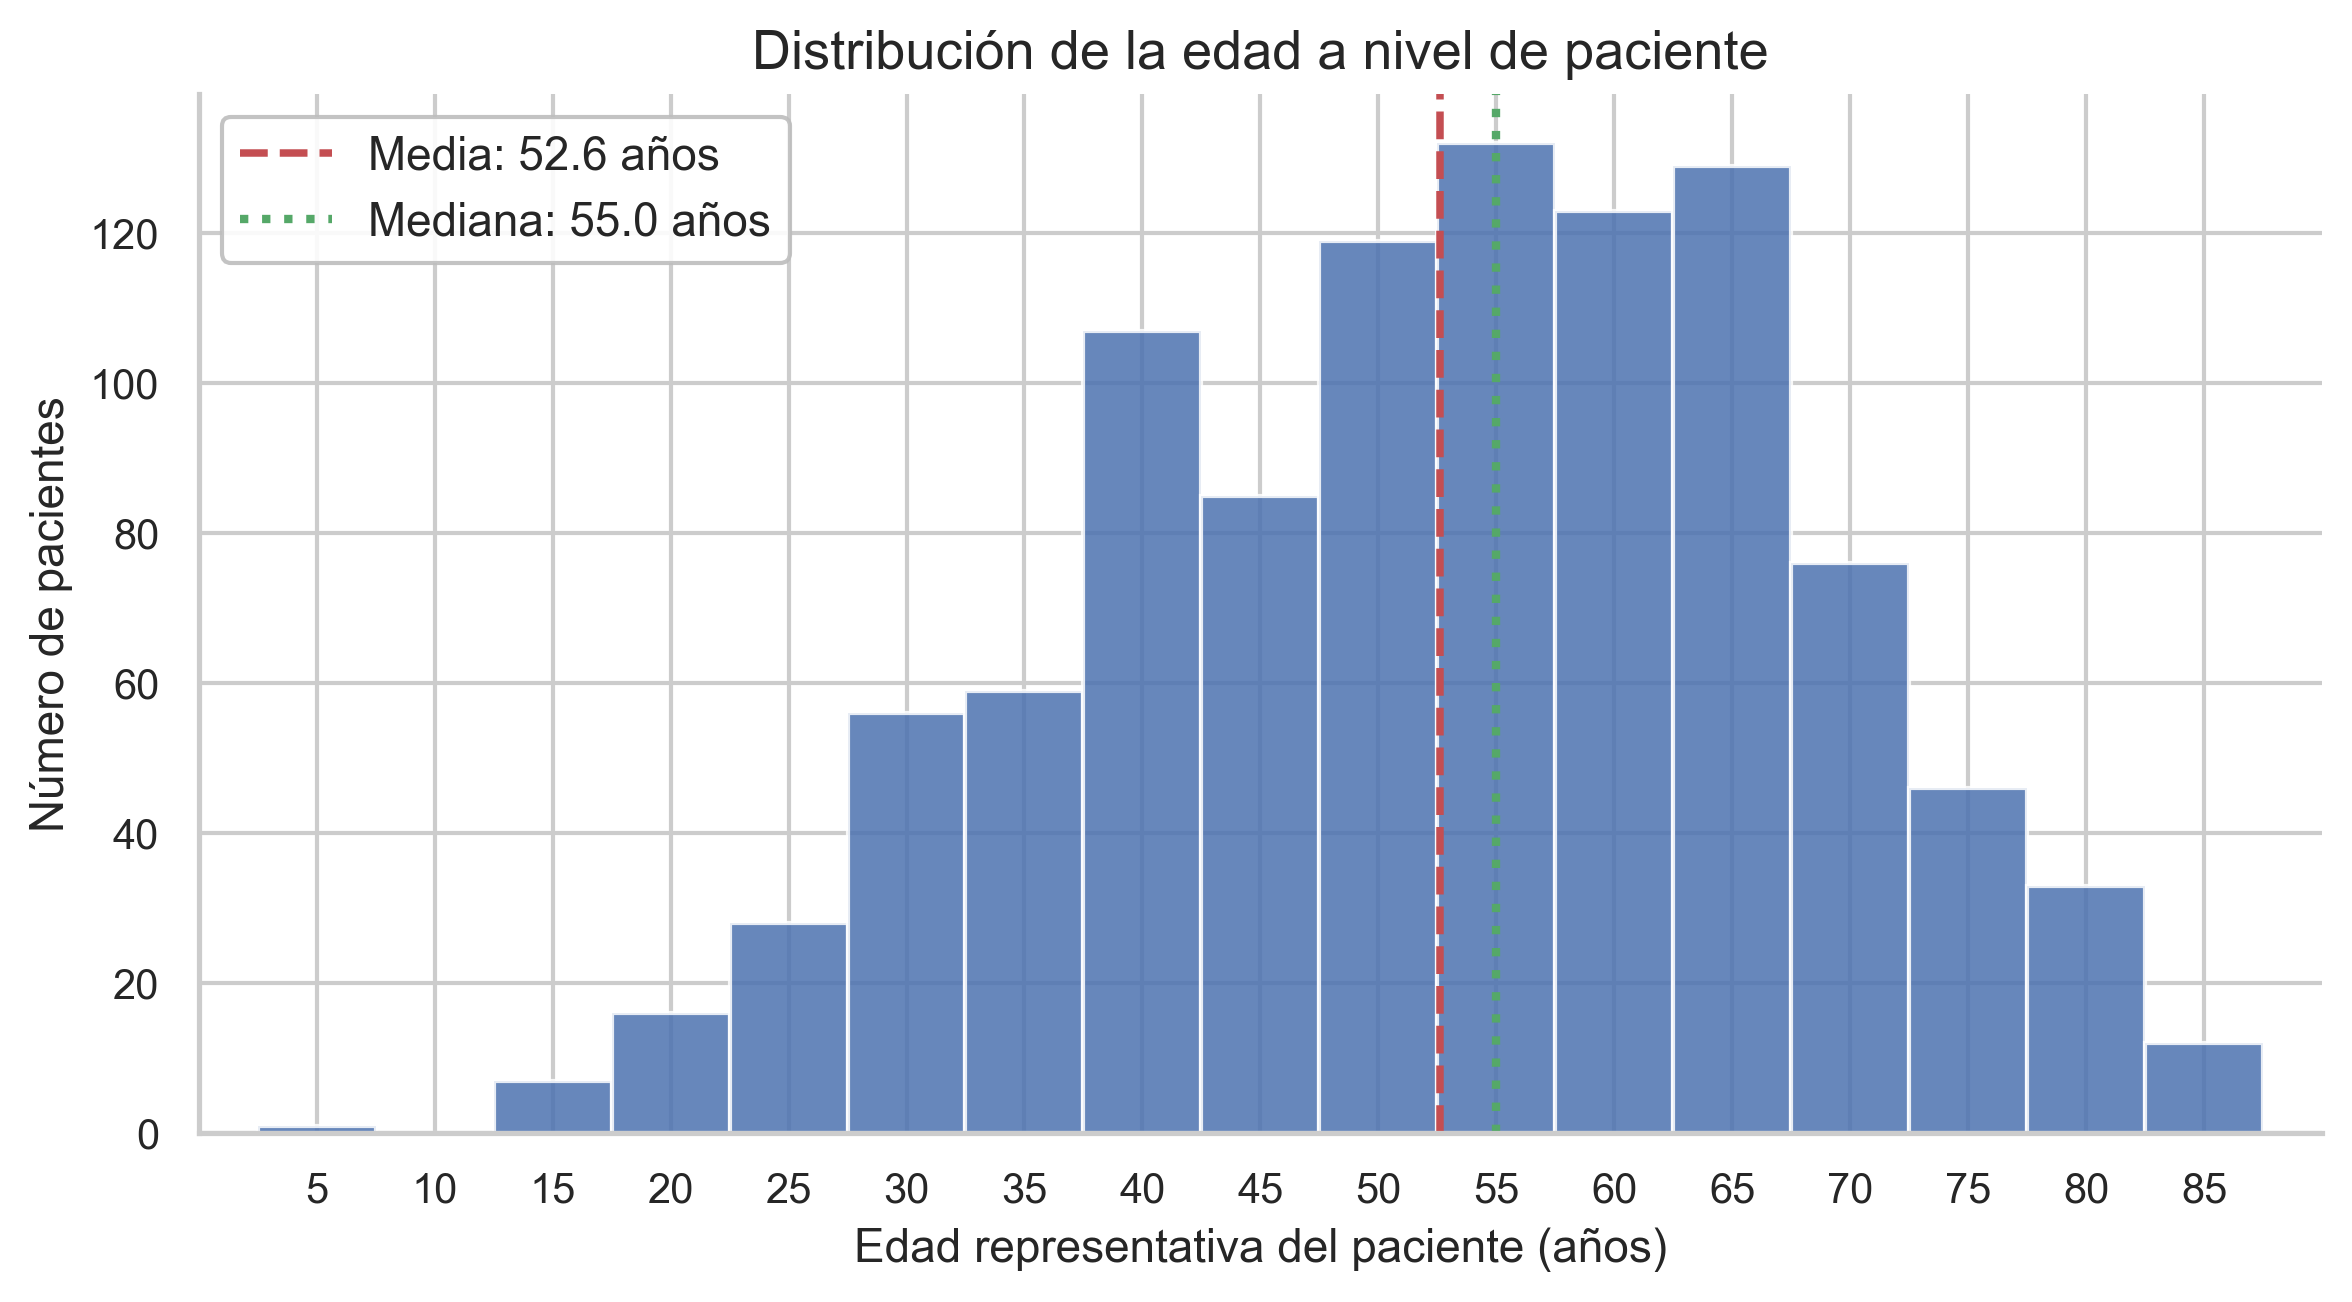

In [168]:
# Age distribution at patient level

age_values = age_distribution_plot_df["age_patient"]
age_mean = age_values.mean()
age_median = age_values.median()

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(
    age_values,
    bins=np.arange(2.5, 92.5, 5),
    color=STATISTIC_PALETTE["distribution"],
    alpha=0.85,
    edgecolor="white",
)

ax.axvline(
    age_mean,
    color=STATISTIC_PALETTE["mean"],
    linestyle="--",
    linewidth=1.8,
    label=f"Media: {age_mean:.1f} años",
)

ax.axvline(
    age_median,
    color=STATISTIC_PALETTE["median"],
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {age_median:.1f} años",
)

clean_axis_labels(
    ax,
    xlabel="Edad representativa del paciente (años)",
    ylabel="Número de pacientes",
    title="Distribución de la edad a nivel de paciente",
)

ax.set_xticks(np.arange(5, 90, 5))
ax.set_xlim(0, 90)

ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor="#BDBDBD",
)

plt.tight_layout()
plt.show()

figures["age_distribution_patient_level"] = fig

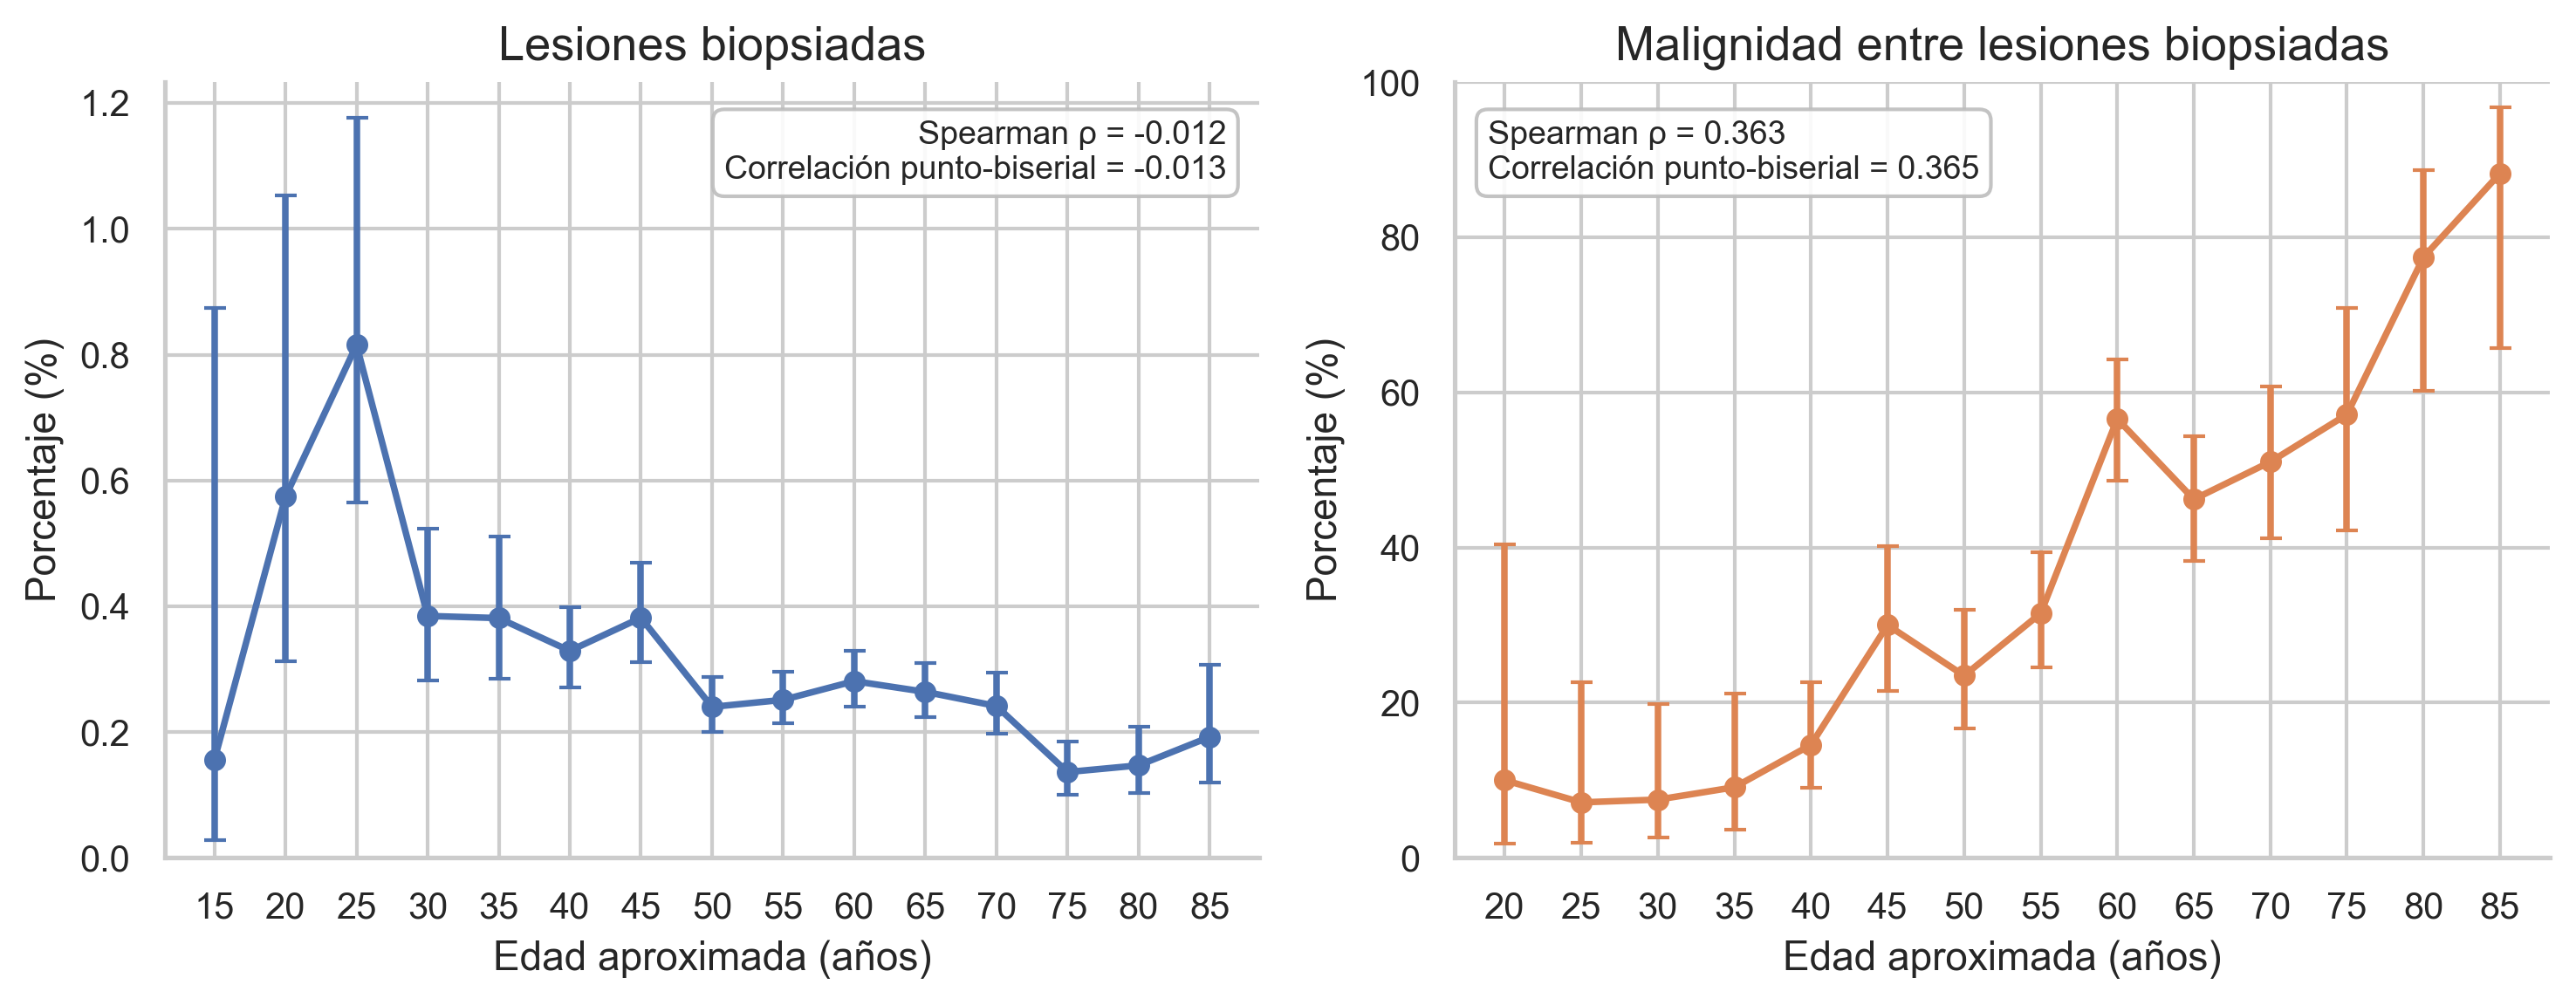

In [83]:
# Age relationship with the two modelling hypotheses

# Exclude age groups with very small denominators only for visualization
age_biopsy_plot_df = (
    age_biopsy_rate.query("n_lesions >= 20").sort_values("age_approx").copy()
)

age_malignancy_plot_df = (
    age_malignancy_rate.query("n_biopsied_lesions >= 10")
    .sort_values("age_approx")
    .copy()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

# Hypothesis 1: biopsy recommendation

axes[0].errorbar(
    age_biopsy_plot_df["age_approx"],
    age_biopsy_plot_df["biopsy_rate_percentage"],
    yerr=[
        age_biopsy_plot_df["biopsy_rate_percentage"] - age_biopsy_plot_df["ci_lower"],
        age_biopsy_plot_df["ci_upper"] - age_biopsy_plot_df["biopsy_rate_percentage"],
    ],
    fmt="o-",
    color=PREDICTIVE_PALETTE["hypothesis_1"],
    linewidth=1.8,
    markersize=5,
    capsize=3,
)

clean_axis_labels(
    axes[0],
    xlabel="Edad aproximada (años)",
    ylabel="Porcentaje (%)",
    title="Lesiones biopsiadas",
)

axes[0].set_xticks(age_biopsy_plot_df["age_approx"])

axes[0].set_ylim(bottom=0)

axes[0].text(
    0.97,
    0.95,
    "Spearman ρ = -0.012\nCorrelación punto-biserial = -0.013",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "alpha": 0.9,
    },
)

# Hypothesis 2: malignancy classification


axes[1].errorbar(
    age_malignancy_plot_df["age_approx"],
    age_malignancy_plot_df["malignancy_rate_percentage"],
    yerr=[
        age_malignancy_plot_df["malignancy_rate_percentage"]
        - age_malignancy_plot_df["ci_lower"],
        age_malignancy_plot_df["ci_upper"]
        - age_malignancy_plot_df["malignancy_rate_percentage"],
    ],
    fmt="o-",
    color=PREDICTIVE_PALETTE["hypothesis_2"],
    linewidth=1.8,
    markersize=5,
    capsize=3,
)

clean_axis_labels(
    axes[1],
    xlabel="Edad aproximada (años)",
    ylabel="Porcentaje (%)",
    title="Malignidad entre lesiones biopsiadas",
)

axes[1].set_xticks(age_malignancy_plot_df["age_approx"])

axes[1].set_ylim(0, 100)

axes[1].text(
    0.03,
    0.95,
    "Spearman ρ = 0.363\nCorrelación punto-biserial = 0.365",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "alpha": 0.9,
    },
)

plt.tight_layout()
plt.show()

figures["age_predictive_value"] = fig

In [84]:
# Plot data: missing age by attribution

age_missing_attribution_plot_df = age_missing_by_attribution.copy()

age_missing_attribution_plot_df["attribution_label"] = simplify_attribution_series(
    age_missing_attribution_plot_df["attribution"]
)

age_missing_attribution_plot_df["label"] = (
    age_missing_attribution_plot_df["perc_patients_missing_age"].map("{:.2f}%".format)
    + " ("
    + age_missing_attribution_plot_df["n_patients_missing_age"].astype(int).astype(str)
    + "/"
    + age_missing_attribution_plot_df["n_patients_total"].astype(int).astype(str)
    + ")"
)

age_missing_attribution_plot_df = age_missing_attribution_plot_df.sort_values(
    "perc_patients_missing_age",
    ascending=True,
)

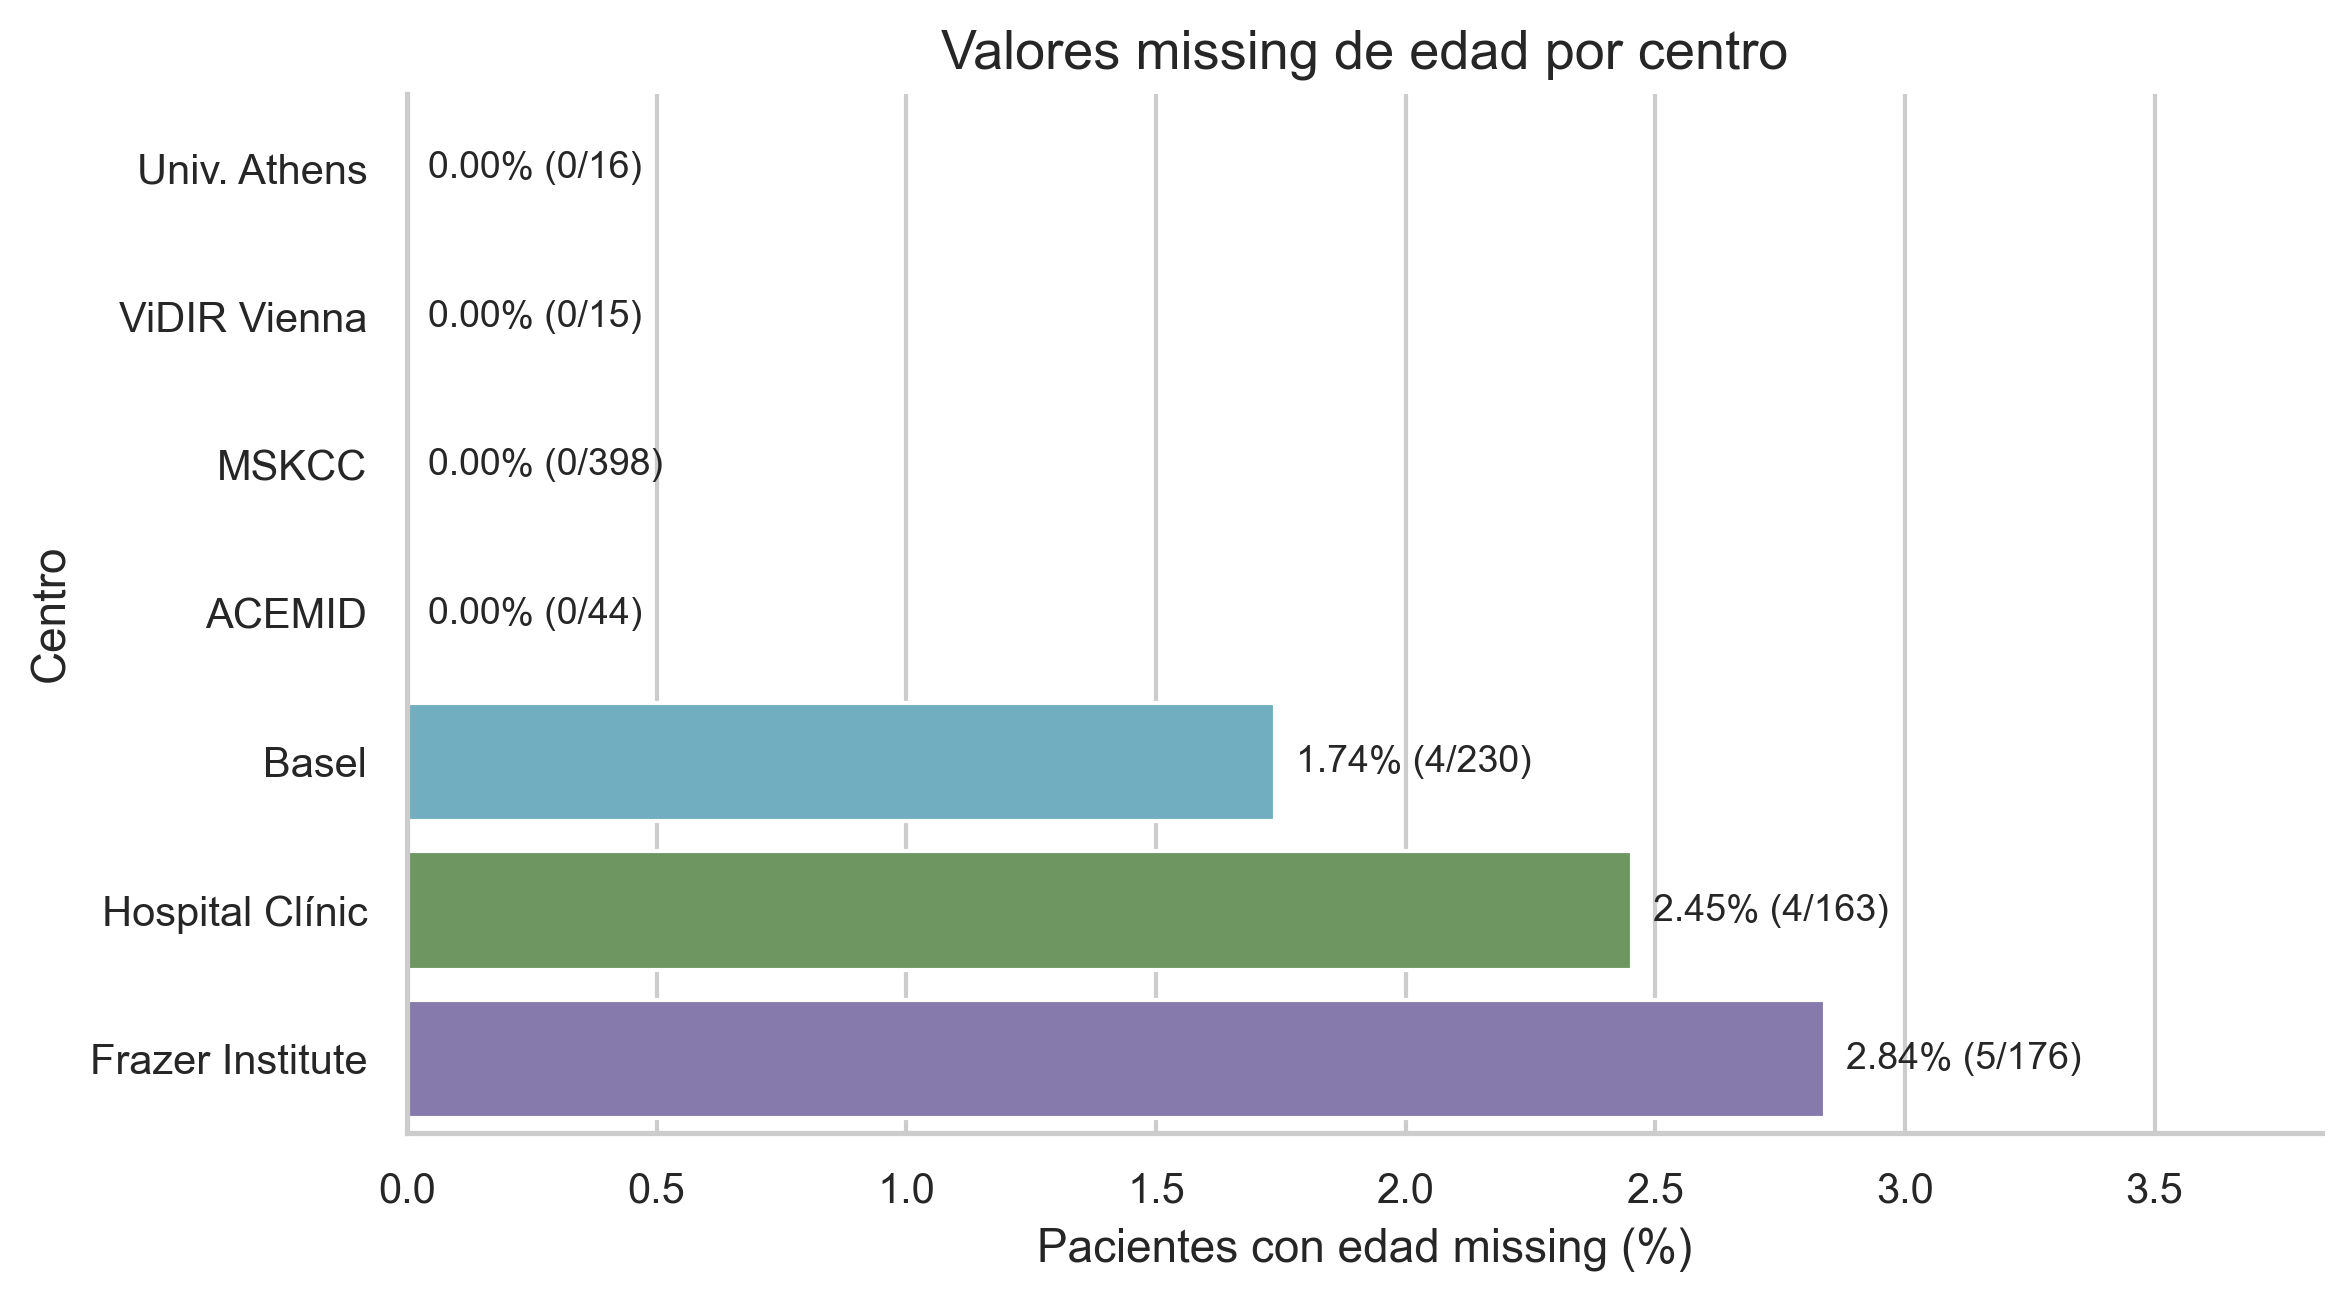

In [85]:
# Missing age by attribution

fig, ax = plt.subplots(
    figsize=(8, 4.5),
)

sns.barplot(
    data=age_missing_attribution_plot_df,
    x="perc_patients_missing_age",
    y="attribution_label",
    hue="attribution_label",
    palette=ATTRIBUTION_PALETTE,
    legend=False,
    ax=ax,
)

# Add percentage and count labels
for patch, (_, row) in zip(
    ax.patches,
    age_missing_attribution_plot_df.iterrows(),
):
    width = patch.get_width()

    # Also label centres with no missing values
    x_position = width if width > 0 else 0

    ax.annotate(
        row["label"],
        xy=(
            x_position,
            patch.get_y() + patch.get_height() / 2,
        ),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

clean_axis_labels(
    ax,
    xlabel="Pacientes con edad missing (%)",
    ylabel="Centro",
    title="Valores missing de edad por centro",
)

max_percentage = age_missing_attribution_plot_df["perc_patients_missing_age"].max()

ax.set_xlim(
    0,
    max_percentage * 1.35,
)

plt.tight_layout()
plt.show()

figures["age_missing_attribution"] = fig

# ANATOMICAL SITE

### 1) BASIC DESCRIPTION

In [169]:
df["anatom_site_general"].dtype

<StringDtype(na_value=nan)>

In [171]:
df["anatom_site_general"].unique()

<ArrowStringArray>
['lower extremity',       'head/neck', 'posterior torso',  'anterior torso',
 'upper extremity',               nan]
Length: 6, dtype: str

| Atributo                    | Valor                                              |
| --------------------------- | -------------------------------------------------- |
| Nombre de la variable       | `anatom_site_general`                              |
| Tipo de variable            | Cualitativa                                        |
| Subtipo                     | Nominal                                            |
| Tipo de almacenamiento      | `string`                                           |
| Valores observados          | `lower extemity`, `head/neck`, `posterior torso`,  |
|                             | `anterior torso`, `upper extermity`                |
| Presencia de *missing*      | Sí (`NA`)                                          |
| Nivel de observación        | Atributo de la lesiónn almacenado a nivel de lesión|

### 2) DISTRIBUTION

In [173]:
# Define anatomical site order and display labels

ANATOM_SITE_ORDER = [
    "posterior torso",
    "lower extremity",
    "anterior torso",
    "upper extremity",
    "head/neck",
    "Missing",
]

ANATOM_SITE_LABELS = {
    "posterior torso": "Posterior torso",
    "lower extremity": "Lower extremity",
    "anterior torso": "Anterior torso",
    "upper extremity": "Upper extremity",
    "head/neck": "Head/neck",
    "Missing": "Missing",
}

df_anatom = df.copy()

df_anatom["anatom_site_general_display"] = (
    df_anatom["anatom_site_general"].fillna("Missing").map(ANATOM_SITE_LABELS)
)

df_anatom["anatom_site_general_group"] = df_anatom["anatom_site_general"].fillna(
    "Missing"
)

In [174]:
# Distribution of anatomical site at lesion level

anatom_lesion_distribution = (
    df_anatom.groupby("anatom_site_general_group", observed=False)
    .agg(
        n_lesions=("isic_id", "count"),
    )
    .reset_index()
)

anatom_lesion_distribution["pct_lesions"] = (
    anatom_lesion_distribution["n_lesions"] / len(df_anatom) * 100
)

anatom_lesion_distribution["anatom_site_general_display"] = anatom_lesion_distribution[
    "anatom_site_general_group"
].map(ANATOM_SITE_LABELS)

anatom_lesion_distribution["order"] = anatom_lesion_distribution[
    "anatom_site_general_group"
].apply(lambda x: ANATOM_SITE_ORDER.index(x))

anatom_lesion_distribution = (
    anatom_lesion_distribution.sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

print(anatom_lesion_distribution)

  anatom_site_general_group  n_lesions  pct_lesions  \
0           posterior torso     121902    30.395029   
1           lower extremity     103028    25.688988   
2            anterior torso      87770    21.884561   
3           upper extremity      70557    17.592673   
4                 head/neck      12046     3.003548   
5                   Missing       5756     1.435200   

  anatom_site_general_display  
0             Posterior torso  
1             Lower extremity  
2              Anterior torso  
3             Upper extremity  
4                   Head/neck  
5                     Missing  


In [175]:
# Patient-level anatomical site coverage

anatom_patient_coverage = (
    df_anatom.dropna(subset=["anatom_site_general"])
    .groupby("anatom_site_general", observed=False)
    .agg(
        n_patients=("patient_id", "nunique"),
    )
    .reset_index()
)

anatom_patient_coverage["pct_patients"] = (
    anatom_patient_coverage["n_patients"] / df_anatom["patient_id"].nunique() * 100
)

anatom_patient_coverage["anatom_site_general_display"] = anatom_patient_coverage[
    "anatom_site_general"
].map(ANATOM_SITE_LABELS)

anatom_patient_coverage["order"] = anatom_patient_coverage["anatom_site_general"].apply(
    lambda x: ANATOM_SITE_ORDER.index(x)
)

anatom_patient_coverage = (
    anatom_patient_coverage.sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

print(anatom_patient_coverage)

  anatom_site_general  n_patients  pct_patients anatom_site_general_display
0     posterior torso        1015     97.408829             Posterior torso
1     lower extremity        1014     97.312860             Lower extremity
2      anterior torso        1016     97.504798              Anterior torso
3     upper extremity        1016     97.504798             Upper extremity
4           head/neck         946     90.786948                   Head/neck


In [176]:
# Combined lesion-level distribution and patient-level coverage

anatom_distribution_summary = anatom_lesion_distribution.merge(
    anatom_patient_coverage[
        [
            "anatom_site_general_display",
            "n_patients",
            "pct_patients",
        ]
    ],
    on="anatom_site_general_display",
    how="left",
)

anatom_distribution_summary["n_patients"] = (
    anatom_distribution_summary["n_patients"].fillna(0).astype(int)
)

anatom_distribution_summary["pct_patients"] = anatom_distribution_summary[
    "pct_patients"
].fillna(0)

anatom_distribution_summary = anatom_distribution_summary[
    [
        "anatom_site_general_display",
        "n_lesions",
        "pct_lesions",
        "n_patients",
        "pct_patients",
    ]
]

print(anatom_distribution_summary)

  anatom_site_general_display  n_lesions  pct_lesions  n_patients  \
0             Posterior torso     121902    30.395029        1015   
1             Lower extremity     103028    25.688988        1014   
2              Anterior torso      87770    21.884561        1016   
3             Upper extremity      70557    17.592673        1016   
4                   Head/neck      12046     3.003548         946   
5                     Missing       5756     1.435200           0   

   pct_patients  
0     97.408829  
1     97.312860  
2     97.504798  
3     97.504798  
4     90.786948  
5      0.000000  


In [177]:
# Format table for reporting

anatom_distribution_summary_formatted = anatom_distribution_summary.copy()

anatom_distribution_summary_formatted["pct_lesions"] = (
    anatom_distribution_summary_formatted["pct_lesions"].round(2)
)

anatom_distribution_summary_formatted["pct_patients"] = (
    anatom_distribution_summary_formatted["pct_patients"].round(2)
)

print(anatom_distribution_summary_formatted)

  anatom_site_general_display  n_lesions  pct_lesions  n_patients  \
0             Posterior torso     121902        30.40        1015   
1             Lower extremity     103028        25.69        1014   
2              Anterior torso      87770        21.88        1016   
3             Upper extremity      70557        17.59        1016   
4                   Head/neck      12046         3.00         946   
5                     Missing       5756         1.44           0   

   pct_patients  
0         97.41  
1         97.31  
2         97.50  
3         97.50  
4         90.79  
5          0.00  


#### Distribution of `anatom_site_general`

The variable `anatom_site_general` describes the anatomical location of each lesion and is recorded at lesion level. Therefore, its distribution was primarily assessed by counting lesions within each anatomical site. In addition, patient-level coverage was evaluated by calculating the number of patients with at least one lesion recorded in each anatomical region.

At lesion level, the most frequent anatomical site was the posterior torso, with 121,902 lesions (30.40%), followed by the lower extremity with 103,028 lesions (25.69%), the anterior torso with 87,770 lesions (21.88%), and the upper extremity with 70,557 lesions (17.59%). Lesions located in the head and neck region were less frequent, accounting for 12,046 lesions (3.00%). Missing anatomical site information was present in 5,756 lesions, corresponding to 1.44% of the dataset.

| Anatomical site | Lesions (n) | Lesions (%) | Patients (n) | Patients (%) |
| --------------- | ----------: | ----------: | -----------: | -----------: |
| Posterior torso |     121,902 |       30.40 |        1,015 |        97.41 |
| Lower extremity |     103,028 |       25.69 |        1,014 |        97.31 |
| Anterior torso  |      87,770 |       21.88 |        1,016 |        97.50 |
| Upper extremity |      70,557 |       17.59 |        1,016 |        97.50 |
| Head/neck       |      12,046 |        3.00 |          946 |        90.79 |
| Missing         |       5,756 |        1.44 |            - |            - |

Table XX. Distribution of `anatom_site_general` at lesion level and patient-level anatomical site coverage. The lesion percentage is calculated over the total number of lesions, while the patient percentage indicates the proportion of patients with at least one lesion recorded in each anatomical site. Patient-level categories are not mutually exclusive, since the same patient may have lesions in several anatomical regions. For the missing category, patient-level coverage is not reported in this table because missing anatomical site information reflects missingness rather than anatomical coverage and is analysed separately.

At patient level, anatomical site coverage was broad across the cohort. More than 97% of patients had at least one lesion recorded in each of the four major body regions: anterior torso, posterior torso, upper extremity, and lower extremity. Head and neck coverage was also high, with 946 patients (90.79%) having at least one lesion in this region.

Overall, the anatomical distribution is dominated by posterior torso, lower extremity, anterior torso, and upper extremity lesions, while head and neck lesions are comparatively less frequent. Missing anatomical site information represents a small fraction of the dataset and should be analysed separately to determine whether it follows a systematic missingness pattern.

### 3) CLASSIFICATION

In [181]:
# Predictive value setup for anatomical site
df_anatom_pred = df.copy()

# Create target variables from diagnostic_group
df_anatom_pred["is_biopsied"] = (
    df_anatom_pred["diagnostic_group"]
    .isin(
        [
            "benign_biopsied",
            "indeterminate_biopsied",
            "malignant_biopsied",
        ]
    )
    .astype(int)
)

df_anatom_pred["is_malignant"] = (
    df_anatom_pred["diagnostic_group"].eq("malignant_biopsied").astype(int)
)

TARGET_BIOPSY = "is_biopsied"
TARGET_MALIGNANT = "is_malignant"

ANATOM_SITE_ORDER = [
    "posterior torso",
    "lower extremity",
    "anterior torso",
    "upper extremity",
    "head/neck",
    "Missing",
]

ANATOM_SITE_LABELS = {
    "posterior torso": "Posterior torso",
    "lower extremity": "Lower extremity",
    "anterior torso": "Anterior torso",
    "upper extremity": "Upper extremity",
    "head/neck": "Head/neck",
    "Missing": "Missing",
}

SEX_LABELS = {
    "female": "Female",
    "male": "Male",
    "Missing": "Missing",
}

df_anatom_pred["anatom_site_general_group"] = df_anatom_pred[
    "anatom_site_general"
].fillna("Missing")

df_anatom_pred["anatom_site_general_display"] = df_anatom_pred[
    "anatom_site_general_group"
].map(ANATOM_SITE_LABELS)

df_anatom_pred["sex_group"] = df_anatom_pred["sex"].fillna("Missing")

df_anatom_pred["sex_display"] = df_anatom_pred["sex_group"].map(SEX_LABELS)

In [183]:
# Association test for categorical predictors and binary targets


def cramers_v_from_table(contingency_table: pd.DataFrame) -> float:
    """
    Compute Cramér's V from a contingency table.
    """
    chi2, _, _, _ = chi2_contingency(contingency_table)

    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1

    if n == 0 or min_dim == 0:
        return np.nan

    return np.sqrt(chi2 / (n * min_dim))


def categorical_association_test(
    data: pd.DataFrame,
    predictor: str,
    target: str,
) -> dict:
    """
    Run chi-square test and compute Cramér's V
    between a categorical predictor and a binary target.
    """
    contingency_table = pd.crosstab(data[predictor], data[target])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    cramers_v = cramers_v_from_table(contingency_table)

    return {
        "predictor": predictor,
        "target": target,
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "cramers_v": cramers_v,
        "contingency_table": contingency_table,
        "expected": expected,
    }

In [184]:
# Biopsy rate by anatomical site

anatom_biopsy_summary = (
    df_anatom_pred.groupby(
        [
            "anatom_site_general_group",
            "anatom_site_general_display",
        ],
        observed=False,
    )
    .agg(
        n_lesions=("isic_id", "count"),
        n_biopsied=(TARGET_BIOPSY, "sum"),
    )
    .reset_index()
)

anatom_biopsy_summary["biopsied_pct"] = (
    anatom_biopsy_summary["n_biopsied"] / anatom_biopsy_summary["n_lesions"] * 100
)

anatom_biopsy_summary["order"] = anatom_biopsy_summary[
    "anatom_site_general_group"
].apply(lambda x: ANATOM_SITE_ORDER.index(x))

anatom_biopsy_summary = (
    anatom_biopsy_summary.sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

print(anatom_biopsy_summary)

  anatom_site_general_group anatom_site_general_display  n_lesions  \
0           posterior torso             Posterior torso     121902   
1           lower extremity             Lower extremity     103028   
2            anterior torso              Anterior torso      87770   
3           upper extremity             Upper extremity      70557   
4                 head/neck                   Head/neck      12046   
5                   Missing                     Missing       5756   

   n_biopsied  biopsied_pct  
0         351      0.287936  
1         203      0.197034  
2         226      0.257491  
3         161      0.228184  
4         121      1.004483  
5           6      0.104239  


In [185]:
# Malignancy rate by anatomical site among biopsied lesions

df_anatom_biopsied = df_anatom_pred.query("is_biopsied == 1").copy()

anatom_malignancy_summary = (
    df_anatom_biopsied.groupby(
        [
            "anatom_site_general_group",
            "anatom_site_general_display",
        ],
        observed=False,
    )
    .agg(
        n_biopsied=("isic_id", "count"),
        n_malignant=(TARGET_MALIGNANT, "sum"),
    )
    .reset_index()
)

anatom_malignancy_summary["malignant_pct"] = (
    anatom_malignancy_summary["n_malignant"]
    / anatom_malignancy_summary["n_biopsied"]
    * 100
)

anatom_malignancy_summary["order"] = anatom_malignancy_summary[
    "anatom_site_general_group"
].apply(lambda x: ANATOM_SITE_ORDER.index(x))

anatom_malignancy_summary = (
    anatom_malignancy_summary.sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

print(anatom_malignancy_summary)

  anatom_site_general_group anatom_site_general_display  n_biopsied  \
0           posterior torso             Posterior torso         351   
1           lower extremity             Lower extremity         203   
2            anterior torso              Anterior torso         226   
3           upper extremity             Upper extremity         161   
4                 head/neck                   Head/neck         121   
5                   Missing                     Missing           6   

   n_malignant  malignant_pct  
0          103      29.344729  
1           73      35.960591  
2           82      36.283186  
3           57      35.403727  
4           78      64.462810  
5            0       0.000000  


In [187]:
# Combined anatomical site predictive summary

anatom_predictive_summary = anatom_biopsy_summary.merge(
    anatom_malignancy_summary,
    on=[
        "anatom_site_general_group",
        "anatom_site_general_display",
    ],
    how="left",
    suffixes=("_total", "_among_biopsied"),
)

anatom_predictive_summary = anatom_predictive_summary.rename(
    columns={
        "n_biopsied_total": "n_biopsied",
    }
)

anatom_predictive_summary = anatom_predictive_summary[
    [
        "anatom_site_general_display",
        "n_lesions",
        "n_biopsied",
        "biopsied_pct",
        "n_malignant",
        "malignant_pct",
    ]
]

anatom_predictive_summary_formatted = anatom_predictive_summary.copy()

anatom_predictive_summary_formatted["biopsied_pct"] = (
    anatom_predictive_summary_formatted["biopsied_pct"].round(2)
)

anatom_predictive_summary_formatted["malignant_pct"] = (
    anatom_predictive_summary_formatted["malignant_pct"].round(2)
)

print(anatom_predictive_summary_formatted)

  anatom_site_general_display  n_lesions  n_biopsied  biopsied_pct  \
0             Posterior torso     121902         351          0.29   
1             Lower extremity     103028         203          0.20   
2              Anterior torso      87770         226          0.26   
3             Upper extremity      70557         161          0.23   
4                   Head/neck      12046         121          1.00   
5                     Missing       5756           6          0.10   

   n_malignant  malignant_pct  
0          103          29.34  
1           73          35.96  
2           82          36.28  
3           57          35.40  
4           78          64.46  
5            0           0.00  


In [188]:
# Association between anatomical site and target variables

anatom_vs_biopsy_test = categorical_association_test(
    data=df_anatom_pred,
    predictor="anatom_site_general_group",
    target=TARGET_BIOPSY,
)

anatom_vs_malignancy_test = categorical_association_test(
    data=df_anatom_biopsied,
    predictor="anatom_site_general_group",
    target=TARGET_MALIGNANT,
)

anatom_association_summary = pd.DataFrame(
    [
        {
            "analysis": "Anatomical site vs biopsy",
            "p_value_chi2": anatom_vs_biopsy_test["p_value"],
            "cramers_v": anatom_vs_biopsy_test["cramers_v"],
        },
        {
            "analysis": "Anatomical site vs malignancy among biopsied lesions",
            "p_value_chi2": anatom_vs_malignancy_test["p_value"],
            "cramers_v": anatom_vs_malignancy_test["cramers_v"],
        },
    ]
)

print(anatom_association_summary)

                                            analysis  p_value_chi2  cramers_v
0                          Anatomical site vs biopsy  6.143385e-58   0.026315
1  Anatomical site vs malignancy among biopsied l...  5.609028e-10   0.220481


In [189]:
# Create clean sex + anatomical site interaction variable

df_sex_anatom_pred = (
    df_anatom_pred.query("sex_group != 'Missing'")
    .query("anatom_site_general_group != 'Missing'")
    .copy()
)

df_sex_anatom_pred["sex_anatom_site"] = (
    df_sex_anatom_pred["sex_display"]
    + " - "
    + df_sex_anatom_pred["anatom_site_general_display"]
)

df_sex_anatom_pred["sex_anatom_order"] = df_sex_anatom_pred["sex_group"].map(
    {"female": 0, "male": 1}
) * 10 + df_sex_anatom_pred["anatom_site_general_group"].apply(
    lambda x: ANATOM_SITE_ORDER.index(x)
)

In [190]:
# Biopsy rate by sex and anatomical site

sex_anatom_biopsy_summary = (
    df_sex_anatom_pred.groupby(
        [
            "sex_group",
            "sex_display",
            "anatom_site_general_group",
            "anatom_site_general_display",
            "sex_anatom_site",
            "sex_anatom_order",
        ],
        observed=False,
    )
    .agg(
        n_lesions=("isic_id", "count"),
        n_biopsied=(TARGET_BIOPSY, "sum"),
    )
    .reset_index()
)

sex_anatom_biopsy_summary["biopsied_pct"] = (
    sex_anatom_biopsy_summary["n_biopsied"]
    / sex_anatom_biopsy_summary["n_lesions"]
    * 100
)

sex_anatom_biopsy_summary = sex_anatom_biopsy_summary.sort_values(
    "sex_anatom_order"
).reset_index(drop=True)

print(sex_anatom_biopsy_summary)

  sex_group sex_display anatom_site_general_group anatom_site_general_display  \
0    female      Female           posterior torso             Posterior torso   
1    female      Female           lower extremity             Lower extremity   
2    female      Female            anterior torso              Anterior torso   
3    female      Female           upper extremity             Upper extremity   
4    female      Female                 head/neck                   Head/neck   
5      male        Male           posterior torso             Posterior torso   
6      male        Male           lower extremity             Lower extremity   
7      male        Male            anterior torso              Anterior torso   
8      male        Male           upper extremity             Upper extremity   
9      male        Male                 head/neck                   Head/neck   

            sex_anatom_site  sex_anatom_order  n_lesions  n_biopsied  \
0  Female - Posterior torso         

In [191]:
# Malignancy rate by sex and anatomical site among biopsied lesions

df_sex_anatom_biopsied = df_sex_anatom_pred.query("is_biopsied == 1").copy()

sex_anatom_malignancy_summary = (
    df_sex_anatom_biopsied.groupby(
        [
            "sex_group",
            "sex_display",
            "anatom_site_general_group",
            "anatom_site_general_display",
            "sex_anatom_site",
            "sex_anatom_order",
        ],
        observed=False,
    )
    .agg(
        n_biopsied=("isic_id", "count"),
        n_malignant=(TARGET_MALIGNANT, "sum"),
    )
    .reset_index()
)

sex_anatom_malignancy_summary["malignant_pct"] = (
    sex_anatom_malignancy_summary["n_malignant"]
    / sex_anatom_malignancy_summary["n_biopsied"]
    * 100
)

sex_anatom_malignancy_summary = sex_anatom_malignancy_summary.sort_values(
    "sex_anatom_order"
).reset_index(drop=True)

print(sex_anatom_malignancy_summary)

  sex_group sex_display anatom_site_general_group anatom_site_general_display  \
0    female      Female           posterior torso             Posterior torso   
1    female      Female           lower extremity             Lower extremity   
2    female      Female            anterior torso              Anterior torso   
3    female      Female           upper extremity             Upper extremity   
4    female      Female                 head/neck                   Head/neck   
5      male        Male           posterior torso             Posterior torso   
6      male        Male           lower extremity             Lower extremity   
7      male        Male            anterior torso              Anterior torso   
8      male        Male           upper extremity             Upper extremity   
9      male        Male                 head/neck                   Head/neck   

            sex_anatom_site  sex_anatom_order  n_biopsied  n_malignant  \
0  Female - Posterior torso       

In [192]:
# Combined predictive summary by sex and anatomical site

sex_anatom_predictive_summary = sex_anatom_biopsy_summary.merge(
    sex_anatom_malignancy_summary,
    on=[
        "sex_group",
        "sex_display",
        "anatom_site_general_group",
        "anatom_site_general_display",
        "sex_anatom_site",
        "sex_anatom_order",
    ],
    how="left",
    suffixes=("", "_among_biopsied"),
)

sex_anatom_predictive_summary = sex_anatom_predictive_summary.rename(
    columns={
        "n_biopsied": "n_biopsied_from_biopsy_model",
        "n_biopsied_among_biopsied": "n_biopsied",
    }
)

sex_anatom_predictive_summary = sex_anatom_predictive_summary[
    [
        "sex_display",
        "anatom_site_general_display",
        "sex_anatom_site",
        "n_lesions",
        "n_biopsied_from_biopsy_model",
        "biopsied_pct",
        "n_biopsied",
        "n_malignant",
        "malignant_pct",
    ]
]

sex_anatom_predictive_summary_formatted = sex_anatom_predictive_summary.copy()

sex_anatom_predictive_summary_formatted["biopsied_pct"] = (
    sex_anatom_predictive_summary_formatted["biopsied_pct"].round(2)
)

sex_anatom_predictive_summary_formatted["malignant_pct"] = (
    sex_anatom_predictive_summary_formatted["malignant_pct"].round(2)
)

print(sex_anatom_predictive_summary_formatted)

  sex_display anatom_site_general_display           sex_anatom_site  \
0      Female             Posterior torso  Female - Posterior torso   
1      Female             Lower extremity  Female - Lower extremity   
2      Female              Anterior torso   Female - Anterior torso   
3      Female             Upper extremity  Female - Upper extremity   
4      Female                   Head/neck        Female - Head/neck   
5        Male             Posterior torso    Male - Posterior torso   
6        Male             Lower extremity    Male - Lower extremity   
7        Male              Anterior torso     Male - Anterior torso   
8        Male             Upper extremity    Male - Upper extremity   
9        Male                   Head/neck          Male - Head/neck   

   n_lesions  n_biopsied_from_biopsy_model  biopsied_pct  n_biopsied  \
0      33292                           130          0.39         130   
1      37617                           109          0.29         109   
2 

In [193]:
# Association between sex + anatomical site and target variables

sex_anatom_vs_biopsy_test = categorical_association_test(
    data=df_sex_anatom_pred,
    predictor="sex_anatom_site",
    target=TARGET_BIOPSY,
)

sex_anatom_vs_malignancy_test = categorical_association_test(
    data=df_sex_anatom_biopsied,
    predictor="sex_anatom_site",
    target=TARGET_MALIGNANT,
)

sex_anatom_association_summary = pd.DataFrame(
    [
        {
            "analysis": "Sex + anatomical site vs biopsy",
            "p_value_chi2": sex_anatom_vs_biopsy_test["p_value"],
            "cramers_v": sex_anatom_vs_biopsy_test["cramers_v"],
        },
        {
            "analysis": "Sex + anatomical site vs malignancy among biopsied lesions",
            "p_value_chi2": sex_anatom_vs_malignancy_test["p_value"],
            "cramers_v": sex_anatom_vs_malignancy_test["cramers_v"],
        },
    ]
)

print(sex_anatom_association_summary)

                                            analysis  p_value_chi2  cramers_v
0                    Sex + anatomical site vs biopsy  4.301842e-63   0.028777
1  Sex + anatomical site vs malignancy among biop...  2.061231e-11   0.259441


In [194]:
# Final association summary

predictive_association_summary = pd.concat(
    [
        anatom_association_summary,
        sex_anatom_association_summary,
    ],
    ignore_index=True,
)

predictive_association_summary["p_value_chi2"] = predictive_association_summary[
    "p_value_chi2"
].map(lambda x: f"{x:.4e}")

predictive_association_summary["cramers_v"] = predictive_association_summary[
    "cramers_v"
].round(4)

print(predictive_association_summary)

                                            analysis p_value_chi2  cramers_v
0                          Anatomical site vs biopsy   6.1434e-58     0.0263
1  Anatomical site vs malignancy among biopsied l...   5.6090e-10     0.2205
2                    Sex + anatomical site vs biopsy   4.3018e-63     0.0288
3  Sex + anatomical site vs malignancy among biop...   2.0612e-11     0.2594


In [195]:
# Rank sex + anatomical site groups by malignancy rate

sex_anatom_malignancy_ranked = sex_anatom_predictive_summary_formatted.sort_values(
    by="malignant_pct",
    ascending=False,
).reset_index(drop=True)

print(sex_anatom_malignancy_ranked)

  sex_display anatom_site_general_display           sex_anatom_site  \
0        Male                   Head/neck          Male - Head/neck   
1        Male             Lower extremity    Male - Lower extremity   
2        Male             Upper extremity    Male - Upper extremity   
3      Female                   Head/neck        Female - Head/neck   
4        Male              Anterior torso     Male - Anterior torso   
5        Male             Posterior torso    Male - Posterior torso   
6      Female              Anterior torso   Female - Anterior torso   
7      Female             Lower extremity  Female - Lower extremity   
8      Female             Posterior torso  Female - Posterior torso   
9      Female             Upper extremity  Female - Upper extremity   

   n_lesions  n_biopsied_from_biopsy_model  biopsied_pct  n_biopsied  \
0       8615                            94          1.09          94   
1      62129                            92          0.15          92   
2 

#### Predictive value of `anatom_site_general`

The potential predictive value of `anatom_site_general` was evaluated separately for the two modelling hypotheses. For the biopsy recommendation model, the outcome was whether a lesion was biopsied or not. For the malignancy classification model, the analysis was restricted to biopsied lesions and assessed whether anatomical site was associated with malignancy.

| Anatomical site | Lesions (n) | Biopsied lesions (n) | Biopsied lesions (%) | Malignant lesions (n) | Malignancy among biopsied (%) |
| --------------- | ----------: | -------------------: | -------------------: | --------------------: | ----------------------------: |
| Posterior torso |     121,902 |                  351 |                 0.29 |                   103 |                         29.34 |
| Lower extremity |     103,028 |                  203 |                 0.20 |                    73 |                         35.96 |
| Anterior torso  |      87,770 |                  226 |                 0.26 |                    82 |                         36.28 |
| Upper extremity |      70,557 |                  161 |                 0.23 |                    57 |                         35.40 |
| Head/neck       |      12,046 |                  121 |                 1.00 |                    78 |                         64.46 |
| Missing         |       5,756 |                    6 |                 0.10 |                     0 |                          0.00 |

Table XX. Relationship between `anatom_site_general` and the two target variables. The biopsy percentage is calculated over all lesions within each anatomical site. The malignancy percentage is calculated only among biopsied lesions from each anatomical site.

At lesion level, anatomical site showed only a very weak association with biopsy status. Although the χ² test was statistically significant, the effect size was very small (Cramér's V = 0.0263), indicating limited discriminative value for the biopsy recommendation task. Biopsy rates were low across all anatomical regions, ranging from 0.20% in the lower extremity to 0.29% in the posterior torso. The main exception was the head and neck region, where 1.00% of lesions were biopsied, suggesting a higher likelihood of biopsy in this location.

In contrast, anatomical site showed a stronger association with malignancy among biopsied lesions. The association remained statistically significant and the effect size was moderate in comparison with the biopsy task (Cramér's V = 0.2205). The head and neck region showed the highest malignancy proportion among biopsied lesions, with 78 malignant lesions out of 121 biopsied lesions (64.46%). The remaining anatomical sites showed lower and relatively similar malignancy proportions, between 29.34% and 36.28%.

| Analysis | p-value χ² | Cramér's V | Interpretation |
| -------- | ---------: | ---------: | -------------- |
| Anatomical site vs biopsy | 6.1434e-58 | 0.0263 | Very weak association |
| Anatomical site vs malignancy among biopsied lesions | 5.6090e-10 | 0.2205 | Moderate association |

Table XX. Association between `anatom_site_general` and the target variables for the two modelling hypotheses. The χ² test evaluates independence between categorical variables, while Cramér's V quantifies the magnitude of association. Given the large sample size, interpretation is based primarily on effect size rather than p-values alone.

#### Combined analysis of `sex` and `anatom_site_general`

A complementary analysis was performed combining `sex` and `anatom_site_general`, since these variables may jointly capture clinically relevant differences in the anatomical distribution of malignant skin lesions.

| Sex | Anatomical site | Lesions (n) | Biopsied lesions (n) | Biopsied lesions (%) | Malignant lesions (n) | Malignancy among biopsied (%) |
| --- | --------------- | ----------: | -------------------: | -------------------: | --------------------: | ----------------------------: |
| Female | Posterior torso | 33,292 | 130 | 0.39 | 32 | 24.62 |
| Female | Lower extremity | 37,617 | 109 | 0.29 | 31 | 28.44 |
| Female | Anterior torso | 24,042 | 68 | 0.28 | 21 | 30.88 |
| Female | Upper extremity | 24,631 | 64 | 0.26 | 14 | 21.88 |
| Female | Head/neck | 3,140 | 26 | 0.83 | 11 | 42.31 |
| Male | Posterior torso | 85,052 | 206 | 0.24 | 69 | 33.50 |
| Male | Lower extremity | 62,129 | 92 | 0.15 | 41 | 44.57 |
| Male | Anterior torso | 61,461 | 152 | 0.25 | 59 | 38.82 |
| Male | Upper extremity | 43,815 | 89 | 0.20 | 39 | 43.82 |
| Male | Head/neck | 8,615 | 94 | 1.09 | 66 | 70.21 |

Table XX. Relationship between the combined variable `sex` + `anatom_site_general` and the two target variables. Missing values in either `sex` or `anatom_site_general` were excluded from this combined analysis to focus on interpretable sex-location groups.

The combined `sex` + anatomical site variable showed a very weak association with biopsy status (Cramér's V = 0.0288), very similar to anatomical site alone. Therefore, this combined variable does not appear to add substantial discriminative value for the biopsy recommendation task.

However, the combined variable showed a stronger association with malignancy among biopsied lesions than anatomical site alone (Cramér's V = 0.2594 compared with 0.2205). This suggests that `sex` may provide additional information when combined with anatomical location, particularly for the malignancy classification task.

The highest malignancy proportion was observed in male patients with head and neck lesions, where 66 of 94 biopsied lesions were malignant (70.21%). Male patients also showed relatively high malignancy proportions in the lower extremity (44.57%) and upper extremity (43.82%). Among female patients, head and neck lesions also showed the highest malignancy proportion (42.31%), but this estimate was based on only 26 biopsied lesions and should therefore be interpreted with caution.

| Analysis | p-value χ² | Cramér's V | Interpretation |
| -------- | ---------: | ---------: | -------------- |
| Sex + anatomical site vs biopsy | 4.3018e-63 | 0.0288 | Very weak association |
| Sex + anatomical site vs malignancy among biopsied lesions | 2.0612e-11 | 0.2594 | Moderate association |

Table XX. Association between the combined `sex` + `anatom_site_general` variable and the target variables. The combined variable provides limited information for biopsy prediction but shows a stronger association with malignancy among biopsied lesions.

Overall, `anatom_site_general` appears to have limited value for predicting whether a lesion was biopsied, but it provides more relevant information for distinguishing malignant from non-malignant lesions among biopsied cases. This effect is mainly driven by the higher malignancy proportion observed in head and neck lesions.

The combined analysis with `sex` suggests an additional, although still moderate, discriminative contribution for the malignancy classification task. In particular, male head and neck lesions showed the highest malignancy proportion among biopsied lesions. Therefore, `anatom_site_general` should be retained as a potentially informative categorical predictor, especially for the secondary malignancy classification model. Its interaction with `sex` may also be worth considering during feature engineering.

### 4) MISSING VALUES

In [200]:
# Missingness setup for anatomical site

df_anatom_missing = df.copy()

df_anatom_missing["anatom_site_missing"] = df_anatom_missing[
    "anatom_site_general"
].isna()

df_anatom_missing["anatom_site_missing_int"] = df_anatom_missing[
    "anatom_site_missing"
].astype(int)

df_anatom_missing["age_missing"] = df_anatom_missing["age_approx"].isna()

df_anatom_missing["sex_missing"] = df_anatom_missing["sex"].isna()

In [202]:
# Global missing summary

n_lesions = len(df_anatom_missing)
n_patients = df_anatom_missing["patient_id"].nunique()

n_missing_lesions = df_anatom_missing["anatom_site_missing"].sum()
n_missing_patients = df_anatom_missing.loc[
    df_anatom_missing["anatom_site_missing"], "patient_id"
].nunique()

anatom_missing_global_summary = pd.DataFrame(
    [
        {
            "metric": "Lesions with missing anatomical site",
            "n": n_missing_lesions,
            "pct": n_missing_lesions / n_lesions * 100,
        },
        {
            "metric": "Patients with ≥1 missing anatomical site",
            "n": n_missing_patients,
            "pct": n_missing_patients / n_patients * 100,
        },
    ]
)

anatom_missing_global_summary["pct"] = anatom_missing_global_summary["pct"].round(2)

print(anatom_missing_global_summary)

                                     metric     n   pct
0      Lesions with missing anatomical site  5756  1.44
1  Patients with ≥1 missing anatomical site    35  3.36


In [203]:
# Missing anatomical site pattern at patient level

anatom_missing_patient_summary = (
    df_anatom_missing.groupby("patient_id", observed=False)
    .agg(
        n_lesions=("isic_id", "count"),
        n_missing_anatom_site=("anatom_site_missing_int", "sum"),
        n_available_anatom_site=(
            "anatom_site_missing_int",
            lambda x: (x == 0).sum(),
        ),
        any_age_missing=("age_missing", "any"),
        any_sex_missing=("sex_missing", "any"),
        attribution=("attribution", "first"),
    )
    .reset_index()
)

anatom_missing_patient_summary["pct_missing_anatom_site"] = (
    anatom_missing_patient_summary["n_missing_anatom_site"]
    / anatom_missing_patient_summary["n_lesions"]
    * 100
)

anatom_missing_patient_summary["missing_pattern"] = np.select(
    [
        anatom_missing_patient_summary["n_missing_anatom_site"] == 0,
        anatom_missing_patient_summary["n_missing_anatom_site"]
        == anatom_missing_patient_summary["n_lesions"],
        anatom_missing_patient_summary["n_missing_anatom_site"] > 0,
    ],
    [
        "No missing",
        "All lesions missing",
        "Partial missing",
    ],
    default="Unknown",
)

anatom_missing_patient_summary_affected = (
    anatom_missing_patient_summary.query("n_missing_anatom_site > 0")
    .sort_values(
        [
            "missing_pattern",
            "pct_missing_anatom_site",
            "n_missing_anatom_site",
        ],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)

print(anatom_missing_patient_summary_affected)

    patient_id  n_lesions  n_missing_anatom_site  n_available_anatom_site  \
0   IP_1219465        439                    439                        0   
1   IP_6745108        421                    421                        0   
2   IP_9011000        310                    310                        0   
3   IP_1195596        309                    309                        0   
4   IP_2926276        254                    254                        0   
5   IP_2988802        184                    184                        0   
6   IP_2066414        161                    161                        0   
7   IP_3944798         87                     87                        0   
8   IP_0432384          8                      8                        0   
9   IP_7858959          8                      8                        0   
10  IP_3374234          7                      7                        0   
11  IP_1127121       2183                   2182                        1   

In [204]:
# Missing anatomical site pattern at patient level

anatom_missing_patient_summary = (
    df_anatom_missing.groupby("patient_id", observed=False)
    .agg(
        n_lesions=("isic_id", "count"),
        n_missing_anatom_site=("anatom_site_missing_int", "sum"),
        n_available_anatom_site=(
            "anatom_site_missing_int",
            lambda x: (x == 0).sum(),
        ),
        any_age_missing=("age_missing", "any"),
        any_sex_missing=("sex_missing", "any"),
        attribution=("attribution", "first"),
    )
    .reset_index()
)

anatom_missing_patient_summary["pct_missing_anatom_site"] = (
    anatom_missing_patient_summary["n_missing_anatom_site"]
    / anatom_missing_patient_summary["n_lesions"]
    * 100
)

anatom_missing_patient_summary["missing_pattern"] = np.select(
    [
        anatom_missing_patient_summary["n_missing_anatom_site"] == 0,
        anatom_missing_patient_summary["n_missing_anatom_site"]
        == anatom_missing_patient_summary["n_lesions"],
        anatom_missing_patient_summary["n_missing_anatom_site"] > 0,
    ],
    [
        "No missing",
        "All lesions missing",
        "Partial missing",
    ],
    default="Unknown",
)

anatom_missing_patient_summary_affected = (
    anatom_missing_patient_summary.query("n_missing_anatom_site > 0")
    .sort_values(
        [
            "missing_pattern",
            "pct_missing_anatom_site",
            "n_missing_anatom_site",
        ],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)

print(anatom_missing_patient_summary_affected)

    patient_id  n_lesions  n_missing_anatom_site  n_available_anatom_site  \
0   IP_1219465        439                    439                        0   
1   IP_6745108        421                    421                        0   
2   IP_9011000        310                    310                        0   
3   IP_1195596        309                    309                        0   
4   IP_2926276        254                    254                        0   
5   IP_2988802        184                    184                        0   
6   IP_2066414        161                    161                        0   
7   IP_3944798         87                     87                        0   
8   IP_0432384          8                      8                        0   
9   IP_7858959          8                      8                        0   
10  IP_3374234          7                      7                        0   
11  IP_1127121       2183                   2182                        1   

In [205]:
# Summary of missing patterns

anatom_missing_pattern_summary = (
    anatom_missing_patient_summary.groupby("missing_pattern", observed=False)
    .agg(
        n_patients=("patient_id", "nunique"),
        n_lesions=("n_lesions", "sum"),
        n_missing_lesions=("n_missing_anatom_site", "sum"),
    )
    .reset_index()
)

anatom_missing_pattern_summary["pct_patients"] = (
    anatom_missing_pattern_summary["n_patients"] / n_patients * 100
)

anatom_missing_pattern_summary["pct_lesions"] = (
    anatom_missing_pattern_summary["n_lesions"] / n_lesions * 100
)

anatom_missing_pattern_summary["pct_missing_lesions"] = (
    anatom_missing_pattern_summary["n_missing_lesions"] / n_missing_lesions * 100
)

anatom_missing_pattern_summary = anatom_missing_pattern_summary.sort_values(
    "n_missing_lesions", ascending=False
).reset_index(drop=True)

anatom_missing_pattern_summary_formatted = anatom_missing_pattern_summary.copy()

for col in [
    "pct_patients",
    "pct_lesions",
    "pct_missing_lesions",
]:
    anatom_missing_pattern_summary_formatted[col] = (
        anatom_missing_pattern_summary_formatted[col].round(2)
    )

print(anatom_missing_pattern_summary_formatted)

       missing_pattern  n_patients  n_lesions  n_missing_lesions  \
0      Partial missing          24      18545               3568   
1  All lesions missing          11       2188               2188   
2           No missing        1007     380326                  0   

   pct_patients  pct_lesions  pct_missing_lesions  
0          2.30         4.62                61.99  
1          1.06         0.55                38.01  
2         96.64        94.83                 0.00  


In [206]:
# Patients with all lesions missing anatomical site

patients_all_anatom_missing = (
    anatom_missing_patient_summary.query("missing_pattern == 'All lesions missing'")
    .sort_values("n_lesions", ascending=False)
    .reset_index(drop=True)
)

print(patients_all_anatom_missing)

    patient_id  n_lesions  n_missing_anatom_site  n_available_anatom_site  \
0   IP_1219465        439                    439                        0   
1   IP_6745108        421                    421                        0   
2   IP_9011000        310                    310                        0   
3   IP_1195596        309                    309                        0   
4   IP_2926276        254                    254                        0   
5   IP_2988802        184                    184                        0   
6   IP_2066414        161                    161                        0   
7   IP_3944798         87                     87                        0   
8   IP_0432384          8                      8                        0   
9   IP_7858959          8                      8                        0   
10  IP_3374234          7                      7                        0   

    any_age_missing  any_sex_missing  \
0             False            Fals

In [207]:
# IDs of patients with all lesions missing anatomical site

patients_all_anatom_missing_ids = patients_all_anatom_missing["patient_id"].tolist()

print(patients_all_anatom_missing_ids)

['IP_1219465', 'IP_6745108', 'IP_9011000', 'IP_1195596', 'IP_2926276', 'IP_2988802', 'IP_2066414', 'IP_3944798', 'IP_0432384', 'IP_7858959', 'IP_3374234']


In [208]:
# Patients with partial missing anatomical site

patients_partial_anatom_missing = (
    anatom_missing_patient_summary.query("missing_pattern == 'Partial missing'")
    .sort_values(
        [
            "pct_missing_anatom_site",
            "n_missing_anatom_site",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

print(patients_partial_anatom_missing)

    patient_id  n_lesions  n_missing_anatom_site  n_available_anatom_site  \
0   IP_1127121       2183                   2182                        1   
1   IP_3487012        826                    825                        1   
2   IP_5377190        166                    165                        1   
3   IP_2931167        227                    225                        2   
4   IP_4295424        155                    151                        4   
5   IP_1546267         66                      1                       65   
6   IP_5505912         80                      1                       79   
7   IP_1074539        134                      1                      133   
8   IP_1741190        382                      2                      380   
9   IP_6982571        212                      1                      211   
10  IP_8877928        305                      1                      304   
11  IP_5746458        311                      1                      310   

In [210]:
# IDs of patients with partial missing anatomical site

patients_partial_anatom_missing_ids = patients_partial_anatom_missing[
    "patient_id"
].tolist()

print(patients_partial_anatom_missing_ids)

['IP_1127121', 'IP_3487012', 'IP_5377190', 'IP_2931167', 'IP_4295424', 'IP_1546267', 'IP_5505912', 'IP_1074539', 'IP_1741190', 'IP_6982571', 'IP_8877928', 'IP_5746458', 'IP_6863831', 'IP_8834083', 'IP_8666903', 'IP_8442778', 'IP_1999627', 'IP_7611905', 'IP_4717387', 'IP_7272992', 'IP_9724369', 'IP_7424727', 'IP_5426188', 'IP_9577633']


In [209]:
# Missing anatomical site by attribution at lesion level

anatom_missing_attribution_lesion_summary = (
    df_anatom_missing.groupby("attribution", observed=False)
    .agg(
        n_lesions=("isic_id", "count"),
        n_missing_anatom_site=("anatom_site_missing_int", "sum"),
    )
    .reset_index()
)

anatom_missing_attribution_lesion_summary["pct_missing_lesions"] = (
    anatom_missing_attribution_lesion_summary["n_missing_anatom_site"]
    / anatom_missing_attribution_lesion_summary["n_lesions"]
    * 100
)

anatom_missing_attribution_lesion_summary = (
    anatom_missing_attribution_lesion_summary.query("n_missing_anatom_site > 0")
    .sort_values("pct_missing_lesions", ascending=False)
    .reset_index(drop=True)
)

print(anatom_missing_attribution_lesion_summary)

                                         attribution  n_lesions  \
0  Frazer Institute, The University of Queensland...      51768   
1                       University Hospital of Basel      65218   
2             Memorial Sloan Kettering Cancer Center     129068   
3  Department of Dermatology, Hospital Clínic de ...     105724   
4  ViDIR Group, Department of Dermatology, Medica...      12640   

   n_missing_anatom_site  pct_missing_lesions  
0                   2343             4.525962  
1                   2089             3.203103  
2                   1153             0.893328  
3                    169             0.159850  
4                      2             0.015823  


In [211]:
# Missing anatomical site by attribution at patient level

patients_with_anatom_missing = anatom_missing_patient_summary.assign(
    has_anatom_missing=lambda x: x["n_missing_anatom_site"] > 0
)

anatom_missing_attribution_patient_summary = (
    patients_with_anatom_missing.groupby("attribution", observed=False)
    .agg(
        n_patients=("patient_id", "nunique"),
        n_patients_with_missing=("has_anatom_missing", "sum"),
    )
    .reset_index()
)

anatom_missing_attribution_patient_summary["pct_missing_patients"] = (
    anatom_missing_attribution_patient_summary["n_patients_with_missing"]
    / anatom_missing_attribution_patient_summary["n_patients"]
    * 100
)

anatom_missing_attribution_patient_summary = (
    anatom_missing_attribution_patient_summary.query("n_patients_with_missing > 0")
    .sort_values("pct_missing_patients", ascending=False)
    .reset_index(drop=True)
)

print(anatom_missing_attribution_patient_summary)

                                         attribution  n_patients  \
0  ViDIR Group, Department of Dermatology, Medica...          15   
1                       University Hospital of Basel         230   
2  Frazer Institute, The University of Queensland...         176   
3             Memorial Sloan Kettering Cancer Center         398   
4  Department of Dermatology, Hospital Clínic de ...         163   

   n_patients_with_missing  pct_missing_patients  
0                        2             13.333333  
1                       11              4.782609  
2                        6              3.409091  
3                       12              3.015075  
4                        4              2.453988  


In [212]:
# Missing pattern by attribution

anatom_missing_pattern_by_attribution = (
    anatom_missing_patient_summary_affected.groupby(
        [
            "attribution",
            "missing_pattern",
        ],
        observed=False,
    )
    .agg(
        n_patients=("patient_id", "nunique"),
        n_lesions=("n_lesions", "sum"),
        n_missing_lesions=("n_missing_anatom_site", "sum"),
    )
    .reset_index()
    .sort_values(
        [
            "missing_pattern",
            "n_patients",
        ],
        ascending=[True, False],
    )
)

print(anatom_missing_pattern_by_attribution)

                                         attribution      missing_pattern  \
5                       University Hospital of Basel  All lesions missing   
3             Memorial Sloan Kettering Cancer Center  All lesions missing   
1  Frazer Institute, The University of Queensland...  All lesions missing   
4             Memorial Sloan Kettering Cancer Center      Partial missing   
2  Frazer Institute, The University of Queensland...      Partial missing   
6                       University Hospital of Basel      Partial missing   
0  Department of Dermatology, Hospital Clínic de ...      Partial missing   
7  ViDIR Group, Department of Dermatology, Medica...      Partial missing   

   n_patients  n_lesions  n_missing_lesions  
5           6       1036               1036  
3           4       1145               1145  
1           1          7                  7  
4           8       3579                  8  
2           5       5390               2336  
6           5       2059      

In [213]:
# Diagnostic distribution according to anatomical site missingness

anatom_missing_diagnostic_summary = (
    df_anatom_missing.groupby(
        [
            "anatom_site_missing",
            "diagnostic_group",
        ],
        observed=False,
    )
    .agg(
        n_lesions=("isic_id", "count"),
    )
    .reset_index()
)

anatom_missing_diagnostic_summary["total_by_missing_status"] = (
    anatom_missing_diagnostic_summary.groupby("anatom_site_missing")[
        "n_lesions"
    ].transform("sum")
)

anatom_missing_diagnostic_summary["pct_within_missing_status"] = (
    anatom_missing_diagnostic_summary["n_lesions"]
    / anatom_missing_diagnostic_summary["total_by_missing_status"]
    * 100
)

anatom_missing_diagnostic_summary_formatted = anatom_missing_diagnostic_summary.copy()

anatom_missing_diagnostic_summary_formatted["pct_within_missing_status"] = (
    anatom_missing_diagnostic_summary_formatted["pct_within_missing_status"].round(4)
)

print(anatom_missing_diagnostic_summary_formatted)

   anatom_site_missing        diagnostic_group  n_lesions  \
0                False         benign_biopsied        555   
1                False     benign_non_biopsied     394241   
2                False  indeterminate_biopsied        114   
3                False      malignant_biopsied        393   
4                 True         benign_biopsied          6   
5                 True     benign_non_biopsied       5750   

   total_by_missing_status  pct_within_missing_status  
0                   395303                     0.1404  
1                   395303                    99.7313  
2                   395303                     0.0288  
3                   395303                     0.0994  
4                     5756                     0.1042  
5                     5756                    99.8958  


In [214]:
# Diagnostic distribution among lesions with missing anatomical site only

anatom_missing_only_diagnostic_summary = (
    df_anatom_missing.query("anatom_site_missing")
    .groupby("diagnostic_group", observed=False)
    .agg(
        n_lesions=("isic_id", "count"),
    )
    .reset_index()
)

anatom_missing_only_diagnostic_summary["pct"] = (
    anatom_missing_only_diagnostic_summary["n_lesions"]
    / anatom_missing_only_diagnostic_summary["n_lesions"].sum()
    * 100
)

anatom_missing_only_diagnostic_summary["pct"] = anatom_missing_only_diagnostic_summary[
    "pct"
].round(4)

print(anatom_missing_only_diagnostic_summary)

      diagnostic_group  n_lesions      pct
0      benign_biopsied          6   0.1042
1  benign_non_biopsied       5750  99.8958


In [221]:
# Overlap between missing anatomical site and missing age/sex

anatom_missing_age_sex_overlap = pd.DataFrame(
    [
        {
            "n_patients": len(anatom_missing_patient_summary_affected),
            "n_patients_with_any_age_missing": (
                anatom_missing_patient_summary_affected["any_age_missing"].sum()
            ),
            "n_patients_with_any_sex_missing": (
                anatom_missing_patient_summary_affected["any_sex_missing"].sum()
            ),
        }
    ]
)

anatom_missing_age_sex_overlap["pct_with_any_age_missing"] = (
    anatom_missing_age_sex_overlap["n_patients_with_any_age_missing"]
    / anatom_missing_age_sex_overlap["n_patients"]
    * 100
)

anatom_missing_age_sex_overlap["pct_with_any_sex_missing"] = (
    anatom_missing_age_sex_overlap["n_patients_with_any_sex_missing"]
    / anatom_missing_age_sex_overlap["n_patients"]
    * 100
)

print(anatom_missing_age_sex_overlap.round(2))

   n_patients  n_patients_with_any_age_missing  \
0          35                                2   

   n_patients_with_any_sex_missing  pct_with_any_age_missing  \
0                                1                      5.71   

   pct_with_any_sex_missing  
0                      2.86  


In [217]:
# Detailed overlap by affected patient

anatom_missing_age_sex_overlap_detail = (
    anatom_missing_patient_summary_affected[
        [
            "patient_id",
            "missing_pattern",
            "n_lesions",
            "n_missing_anatom_site",
            "pct_missing_anatom_site",
            "any_age_missing",
            "any_sex_missing",
            "attribution",
        ]
    ]
    .sort_values(
        [
            "any_age_missing",
            "any_sex_missing",
            "pct_missing_anatom_site",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

print(anatom_missing_age_sex_overlap_detail)

    patient_id      missing_pattern  n_lesions  n_missing_anatom_site  \
0   IP_7858959  All lesions missing          8                      8   
1   IP_3374234  All lesions missing          7                      7   
2   IP_1219465  All lesions missing        439                    439   
3   IP_6745108  All lesions missing        421                    421   
4   IP_9011000  All lesions missing        310                    310   
5   IP_1195596  All lesions missing        309                    309   
6   IP_2926276  All lesions missing        254                    254   
7   IP_2988802  All lesions missing        184                    184   
8   IP_2066414  All lesions missing        161                    161   
9   IP_3944798  All lesions missing         87                     87   
10  IP_0432384  All lesions missing          8                      8   
11  IP_1127121      Partial missing       2183                   2182   
12  IP_3487012      Partial missing        826     

In [218]:
# Impact of removing patients with any missing anatomical site

patients_with_any_anatom_missing = anatom_missing_patient_summary_affected[
    "patient_id"
].unique()

df_without_anatom_missing_patients = df_anatom_missing.loc[
    ~df_anatom_missing["patient_id"].isin(patients_with_any_anatom_missing)
].copy()

anatom_missing_removal_impact = pd.DataFrame(
    [
        {
            "scenario": "Original dataset",
            "n_patients": df_anatom_missing["patient_id"].nunique(),
            "n_lesions": len(df_anatom_missing),
        },
        {
            "scenario": "After removing patients with anatomical site missing",
            "n_patients": df_without_anatom_missing_patients["patient_id"].nunique(),
            "n_lesions": len(df_without_anatom_missing_patients),
        },
        {
            "scenario": "Removed records",
            "n_patients": len(patients_with_any_anatom_missing),
            "n_lesions": (
                len(df_anatom_missing) - len(df_without_anatom_missing_patients)
            ),
        },
    ]
)

anatom_missing_removal_impact["pct_patients"] = (
    anatom_missing_removal_impact["n_patients"]
    / df_anatom_missing["patient_id"].nunique()
    * 100
)

anatom_missing_removal_impact["pct_lesions"] = (
    anatom_missing_removal_impact["n_lesions"] / len(df_anatom_missing) * 100
)

anatom_missing_removal_impact[
    [
        "scenario",
        "n_patients",
        "pct_patients",
        "n_lesions",
        "pct_lesions",
    ]
].round(2)
print(anatom_missing_removal_impact)

                                            scenario  n_patients  n_lesions  \
0                                   Original dataset        1042     401059   
1  After removing patients with anatomical site m...        1007     380326   
2                                    Removed records          35      20733   

   pct_patients  pct_lesions  
0    100.000000   100.000000  
1     96.641075    94.830436  
2      3.358925     5.169564  


In [219]:
# Diagnostic distribution before and after removing affected patients

diagnostic_before = (
    df_anatom_missing["diagnostic_group"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("before_pct")
)

diagnostic_after = (
    df_without_anatom_missing_patients["diagnostic_group"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("after_pct")
)

anatom_missing_diagnostic_before_after = (
    pd.concat(
        [
            diagnostic_before,
            diagnostic_after,
        ],
        axis=1,
    )
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "diagnostic_group"})
)

anatom_missing_diagnostic_before_after["difference_pp"] = (
    anatom_missing_diagnostic_before_after["after_pct"]
    - anatom_missing_diagnostic_before_after["before_pct"]
)

anatom_missing_diagnostic_before_after = (
    anatom_missing_diagnostic_before_after.sort_values(
        "before_pct", ascending=False
    ).reset_index(drop=True)
)

print(anatom_missing_diagnostic_before_after.round(4))

         diagnostic_group  before_pct  after_pct  difference_pp
0     benign_non_biopsied     99.7337    99.7321        -0.0016
1         benign_biopsied      0.1399     0.1401         0.0003
2      malignant_biopsied       0.098     0.1002         0.0022
3  indeterminate_biopsied      0.0284     0.0276        -0.0008


#### Missing values in `anatom_site_general`

Missing values in `anatom_site_general` were analysed at both lesion and patient level. Since anatomical site is a lesion-level variable, missingness may affect either all lesions from a patient or only a subset of lesions.

Overall, 5,756 lesions had missing anatomical site information, representing 1.44% of all 401,059 lesions. These missing values were distributed across 35 patients, corresponding to 3.36% of the 1,042 patients in the dataset.

| Metric | n | Percentage (%) |
| ------ | -: | -------------: |
| Lesions with missing anatomical site | 5,756 | 1.44 |
| Patients with ≥1 missing anatomical site | 35 | 3.36 |

Table XX. Global frequency of missing values in `anatom_site_general` at lesion and patient level.

Two different missingness patterns were identified. A total of 11 patients had missing anatomical site information in all their lesions, accounting for 2,188 lesions. An additional 24 patients had missing anatomical site information in only part of their lesions, contributing 18,545 lesions in total, of which 3,568 had missing anatomical site information.

| Missing pattern | Patients (n) | Patients (%) | Lesions (n) | Lesions (%) | Missing lesions (n) | Missing lesions (%) |
| --------------- | -----------: | -----------: | ----------: | ----------: | ------------------: | ------------------: |
| Partial missing | 24 | 2.30 | 18,545 | 4.62 | 3,568 | 61.99 |
| All lesions missing | 11 | 1.06 | 2,188 | 0.55 | 2,188 | 38.01 |
| No missing | 1,007 | 96.64 | 380,326 | 94.83 | 0 | 0.00 |

Table XX. Patient-level missingness patterns for `anatom_site_general`. “All lesions missing” indicates patients for whom anatomical site information is absent in every lesion. “Partial missing” indicates patients with both available and missing anatomical site values.

Among the 24 patients with partial missingness, the pattern was heterogeneous. In most patients, missingness was minimal, usually affecting only one or two lesions. However, five patients showed a near-complete missingness pattern, with more than 97% of their lesions lacking anatomical site information. This suggests that the partial missing group contains two different situations: isolated lesion-level missing values and near-complete patient-level missingness.

Missing anatomical site information was not evenly distributed across centres. At lesion level, the highest missingness proportions were observed in the Frazer Institute, The University of Queensland (4.53%) and the University Hospital of Basel (3.20%). Memorial Sloan Kettering Cancer Center showed a lower proportion of missing lesions (0.89%), while Hospital Clínic de Barcelona and ViDIR had very low lesion-level missingness.

| Centre | Lesions (n) | Missing anatomical site (n) | Missing lesions (%) |
| ------ | ----------: | --------------------------: | ------------------: |
| Frazer Institute, The University of Queensland | 51,768 | 2,343 | 4.53 |
| University Hospital of Basel | 65,218 | 2,089 | 3.20 |
| Memorial Sloan Kettering Cancer Center | 129,068 | 1,153 | 0.89 |
| Department of Dermatology, Hospital Clínic de Barcelona | 105,724 | 169 | 0.16 |
| ViDIR Group, Department of Dermatology | 12,640 | 2 | 0.02 |

Table XX. Lesion-level distribution of missing anatomical site information by centre.

At patient level, affected patients were also distributed across several centres. The highest proportion was observed in ViDIR, although this involved only 2 patients. In absolute terms, missing anatomical site information was mainly concentrated in University Hospital of Basel, Memorial Sloan Kettering Cancer Center, and Frazer Institute.

| Centre | Patients (n) | Patients with missing anatomical site (n) | Missing patients (%) |
| ------ | -----------: | ---------------------------------------: | -------------------: |
| ViDIR Group, Department of Dermatology | 15 | 2 | 13.33 |
| University Hospital of Basel | 230 | 11 | 4.78 |
| Frazer Institute, The University of Queensland | 176 | 6 | 3.41 |
| Memorial Sloan Kettering Cancer Center | 398 | 12 | 3.02 |
| Department of Dermatology, Hospital Clínic de Barcelona | 163 | 4 | 2.45 |

Table XX. Patient-level distribution of missing anatomical site information by centre.

The distribution of missingness by centre and pattern showed that patients with all lesions missing were mainly concentrated in University Hospital of Basel and Memorial Sloan Kettering Cancer Center. In contrast, partial missingness was more heterogeneous. Frazer Institute and University Hospital of Basel contributed most of the missing lesions among partially affected patients, largely due to patients with near-complete missingness.

| Centre | Missing pattern | Patients (n) | Lesions (n) | Missing lesions (n) |
| ------ | --------------- | -----------: | ----------: | ------------------: |
| University Hospital of Basel | All lesions missing | 6 | 1,036 | 1,036 |
| Memorial Sloan Kettering Cancer Center | All lesions missing | 4 | 1,145 | 1,145 |
| Frazer Institute, The University of Queensland | All lesions missing | 1 | 7 | 7 |
| Memorial Sloan Kettering Cancer Center | Partial missing | 8 | 3,579 | 8 |
| Frazer Institute, The University of Queensland | Partial missing | 5 | 5,390 | 2,336 |
| University Hospital of Basel | Partial missing | 5 | 2,059 | 1,053 |
| Department of Dermatology, Hospital Clínic de Barcelona | Partial missing | 4 | 4,478 | 169 |
| ViDIR Group, Department of Dermatology | Partial missing | 2 | 3,039 | 2 |

Table XX. Missing anatomical site pattern by centre.

The overlap with missing values in `age_approx` and `sex` was limited. Among the 35 patients with missing anatomical site information, only 2 patients also had missing age and only 1 patient also had missing sex. Both cases occurred among patients with all lesions missing anatomical site information. No patients with partial anatomical site missingness had missing values in either `age_approx` or `sex`.

| Patients with anatomical site missing | Patients with missing age | Patients with missing sex |
| ------------------------------------: | ------------------------: | ------------------------: |
| 35 | 2 | 1 |

Table XX. Overlap between missing values in `anatom_site_general`, `age_approx`, and `sex`.

The diagnostic distribution of lesions with missing anatomical site information was highly concentrated in benign non-biopsied lesions. Among the 5,756 lesions with missing anatomical site information, 5,750 lesions (99.90%) were benign non-biopsied and only 6 lesions (0.10%) were benign biopsied. No indeterminate or malignant lesions had missing anatomical site information.

| Anatomical site missing | Diagnostic group | Lesions (n) | Percentage within group (%) |
| ----------------------- | ---------------- | ----------: | --------------------------: |
| No | benign_non_biopsied | 394,241 | 99.7313 |
| No | benign_biopsied | 555 | 0.1404 |
| No | indeterminate_biopsied | 114 | 0.0288 |
| No | malignant_biopsied | 393 | 0.0994 |
| Yes | benign_non_biopsied | 5,750 | 99.8958 |
| Yes | benign_biopsied | 6 | 0.1042 |

Table XX. Diagnostic distribution according to missingness status in `anatom_site_general`.

The potential impact of excluding all patients with missing anatomical site information was also assessed. Removing the 35 affected patients would reduce the dataset from 1,042 to 1,007 patients and from 401,059 to 380,326 lesions. This corresponds to excluding 3.36% of patients and 5.17% of lesions.

| Scenario | Patients (n) | Patients (%) | Lesions (n) | Lesions (%) |
| -------- | -----------: | -----------: | ----------: | ----------: |
| Original dataset | 1,042 | 100.00 | 401,059 | 100.00 |
| After removing patients with anatomical site missing | 1,007 | 96.64 | 380,326 | 94.83 |
| Removed records | 35 | 3.36 | 20,733 | 5.17 |

Table XX. Impact on dataset size after excluding all patients with missing values in `anatom_site_general`.

The diagnostic composition of the dataset was almost unchanged after removing these patients. Differences across diagnostic groups were below 0.003 percentage points, indicating that exclusion would not meaningfully alter the clinical composition or class imbalance of the dataset.

| Diagnostic group | Before (%) | After (%) | Difference (pp) |
| ---------------- | ---------: | --------: | --------------: |
| benign_non_biopsied | 99.7337 | 99.7321 | -0.0016 |
| benign_biopsied | 0.1399 | 0.1401 | +0.0003 |
| malignant_biopsied | 0.0980 | 0.1002 | +0.0022 |
| indeterminate_biopsied | 0.0284 | 0.0276 | -0.0008 |

Table XX. Diagnostic distribution before and after excluding patients with missing anatomical site information.

Overall, the missingness pattern in `anatom_site_general` appears more compatible with a Missing At Random mechanism than with a Missing Not At Random mechanism. Missing values are concentrated in specific centres and patient-level patterns, while they show little overlap with missing age or sex and are almost exclusively restricted to benign non-biopsied lesions. This suggests that the absence of anatomical site information is more likely related to metadata collection, integration, or centre-specific recording procedures than to lesion severity.

However, unlike `sex` or `age_approx`, `anatom_site_general` is a lesion-level variable and several affected patients still contain available anatomical site information for some lesions. Therefore, deletion of all affected patients would be possible and would have minimal impact on diagnostic composition, but it may be unnecessarily conservative. Since auxiliary location variables are available (`tbp_lv_location` and `tbp_lv_location_simple`), imputation should be evaluated before deciding whether to exclude lesions or patients.

In [222]:
# Availability of TBP location variables among missing anatomical site lesions

df_missing_anatom_only = df_anatom_missing.query("anatom_site_missing").copy()

n_missing_anatom_site = len(df_missing_anatom_only)

n_tbp_location_available = df_missing_anatom_only["tbp_lv_location"].notna().sum()

n_tbp_location_simple_available = (
    df_missing_anatom_only["tbp_lv_location_simple"].notna().sum()
)

n_tbp_location_simple_not_unknown = (
    df_missing_anatom_only["tbp_lv_location_simple"].notna()
    & df_missing_anatom_only["tbp_lv_location_simple"].ne("Unknown")
).sum()

tbp_location_availability_missing_anatom = pd.DataFrame(
    [
        {
            "n_missing_anatom_site": n_missing_anatom_site,
            "n_tbp_location_available": n_tbp_location_available,
            "n_tbp_location_simple_available": n_tbp_location_simple_available,
            "n_tbp_location_simple_not_unknown": n_tbp_location_simple_not_unknown,
        }
    ]
)

tbp_location_availability_missing_anatom["pct_tbp_location_available"] = (
    tbp_location_availability_missing_anatom["n_tbp_location_available"]
    / tbp_location_availability_missing_anatom["n_missing_anatom_site"]
    * 100
)

tbp_location_availability_missing_anatom["pct_tbp_location_simple_available"] = (
    tbp_location_availability_missing_anatom["n_tbp_location_simple_available"]
    / tbp_location_availability_missing_anatom["n_missing_anatom_site"]
    * 100
)

tbp_location_availability_missing_anatom["pct_tbp_location_simple_not_unknown"] = (
    tbp_location_availability_missing_anatom["n_tbp_location_simple_not_unknown"]
    / tbp_location_availability_missing_anatom["n_missing_anatom_site"]
    * 100
)

print(tbp_location_availability_missing_anatom.round(2))

   n_missing_anatom_site  n_tbp_location_available  \
0                   5756                      5756   

   n_tbp_location_simple_available  n_tbp_location_simple_not_unknown  \
0                             5756                                  0   

   pct_tbp_location_available  pct_tbp_location_simple_available  \
0                       100.0                              100.0   

   pct_tbp_location_simple_not_unknown  
0                                  0.0  


In [223]:
# Distribution of TBP simple location among missing anatomical site lesions

tbp_location_simple_missing_distribution = (
    df_missing_anatom_only["tbp_lv_location_simple"]
    .value_counts(dropna=False)
    .rename_axis("tbp_lv_location_simple")
    .reset_index(name="n_lesions")
)

tbp_location_simple_missing_distribution["pct"] = (
    tbp_location_simple_missing_distribution["n_lesions"]
    / len(df_missing_anatom_only)
    * 100
)

tbp_location_simple_missing_distribution["pct"] = (
    tbp_location_simple_missing_distribution["pct"].round(2)
)

print(tbp_location_simple_missing_distribution)

  tbp_lv_location_simple  n_lesions    pct
0                Unknown       5756  100.0


In [224]:
# Distribution of detailed TBP location among missing anatomical site lesions

tbp_location_missing_distribution = (
    df_missing_anatom_only["tbp_lv_location"]
    .value_counts(dropna=False)
    .rename_axis("tbp_lv_location")
    .reset_index(name="n_lesions")
)

tbp_location_missing_distribution["pct"] = (
    tbp_location_missing_distribution["n_lesions"] / len(df_missing_anatom_only) * 100
)

tbp_location_missing_distribution["pct"] = tbp_location_missing_distribution[
    "pct"
].round(2)

print(tbp_location_missing_distribution)

  tbp_lv_location  n_lesions    pct
0         Unknown       5756  100.0


In [225]:
# Count useful detailed TBP location values among missing anatomical site lesions

tbp_location_useful_summary = pd.DataFrame(
    [
        {
            "n_missing_anatom_site": len(df_missing_anatom_only),
            "n_tbp_location_unknown": (
                df_missing_anatom_only["tbp_lv_location"].eq("Unknown").sum()
            ),
            "n_tbp_location_not_unknown": (
                df_missing_anatom_only["tbp_lv_location"].ne("Unknown").sum()
            ),
        }
    ]
)

tbp_location_useful_summary["pct_tbp_location_unknown"] = (
    tbp_location_useful_summary["n_tbp_location_unknown"]
    / tbp_location_useful_summary["n_missing_anatom_site"]
    * 100
)

tbp_location_useful_summary["pct_tbp_location_not_unknown"] = (
    tbp_location_useful_summary["n_tbp_location_not_unknown"]
    / tbp_location_useful_summary["n_missing_anatom_site"]
    * 100
)

print(tbp_location_useful_summary.round(2))

   n_missing_anatom_site  n_tbp_location_unknown  n_tbp_location_not_unknown  \
0                   5756                    5756                           0   

   pct_tbp_location_unknown  pct_tbp_location_not_unknown  
0                     100.0                           0.0  


#### Imputability of missing values in `anatom_site_general`

The auxiliary variables `tbp_lv_location` and `tbp_lv_location_simple` were explored as potential sources of information to impute missing values in `anatom_site_general`.

Among the 5,756 lesions with missing anatomical site information, both TBP location variables were technically available for all lesions. However, their values were non-informative: all lesions had `tbp_lv_location = Unknown` and `tbp_lv_location_simple = Unknown`.

| Variable | Available values (n) | Available values (%) | Informative values (n) | Informative values (%) |
| -------- | -------------------: | -------------------: | ---------------------: | ---------------------: |
| `tbp_lv_location` | 5,756 | 100.00 | 0 | 0.00 |
| `tbp_lv_location_simple` | 5,756 | 100.00 | 0 | 0.00 |

Table XX. Availability and informativeness of auxiliary TBP location variables among lesions with missing values in `anatom_site_general`. Values coded as `Unknown` were considered non-informative for imputation.

Therefore, these variables cannot be used to impute missing anatomical site values. This suggests that missingness affects the anatomical location metadata consistently across related location fields, rather than being limited to `anatom_site_general`.

As a result, deterministic imputation from TBP location variables is not feasible. The remaining preprocessing options are therefore limited to treating missing anatomical site as a separate category, excluding affected records, or applying a non-deterministic imputation strategy based on other lesion- or patient-level variables. Given the low proportion of missing lesions, their almost exclusive restriction to benign non-biopsied lesions, and the absence of informative auxiliary location data, deterministic imputation is not recommended.

### 5) PLOTS AND TABLES

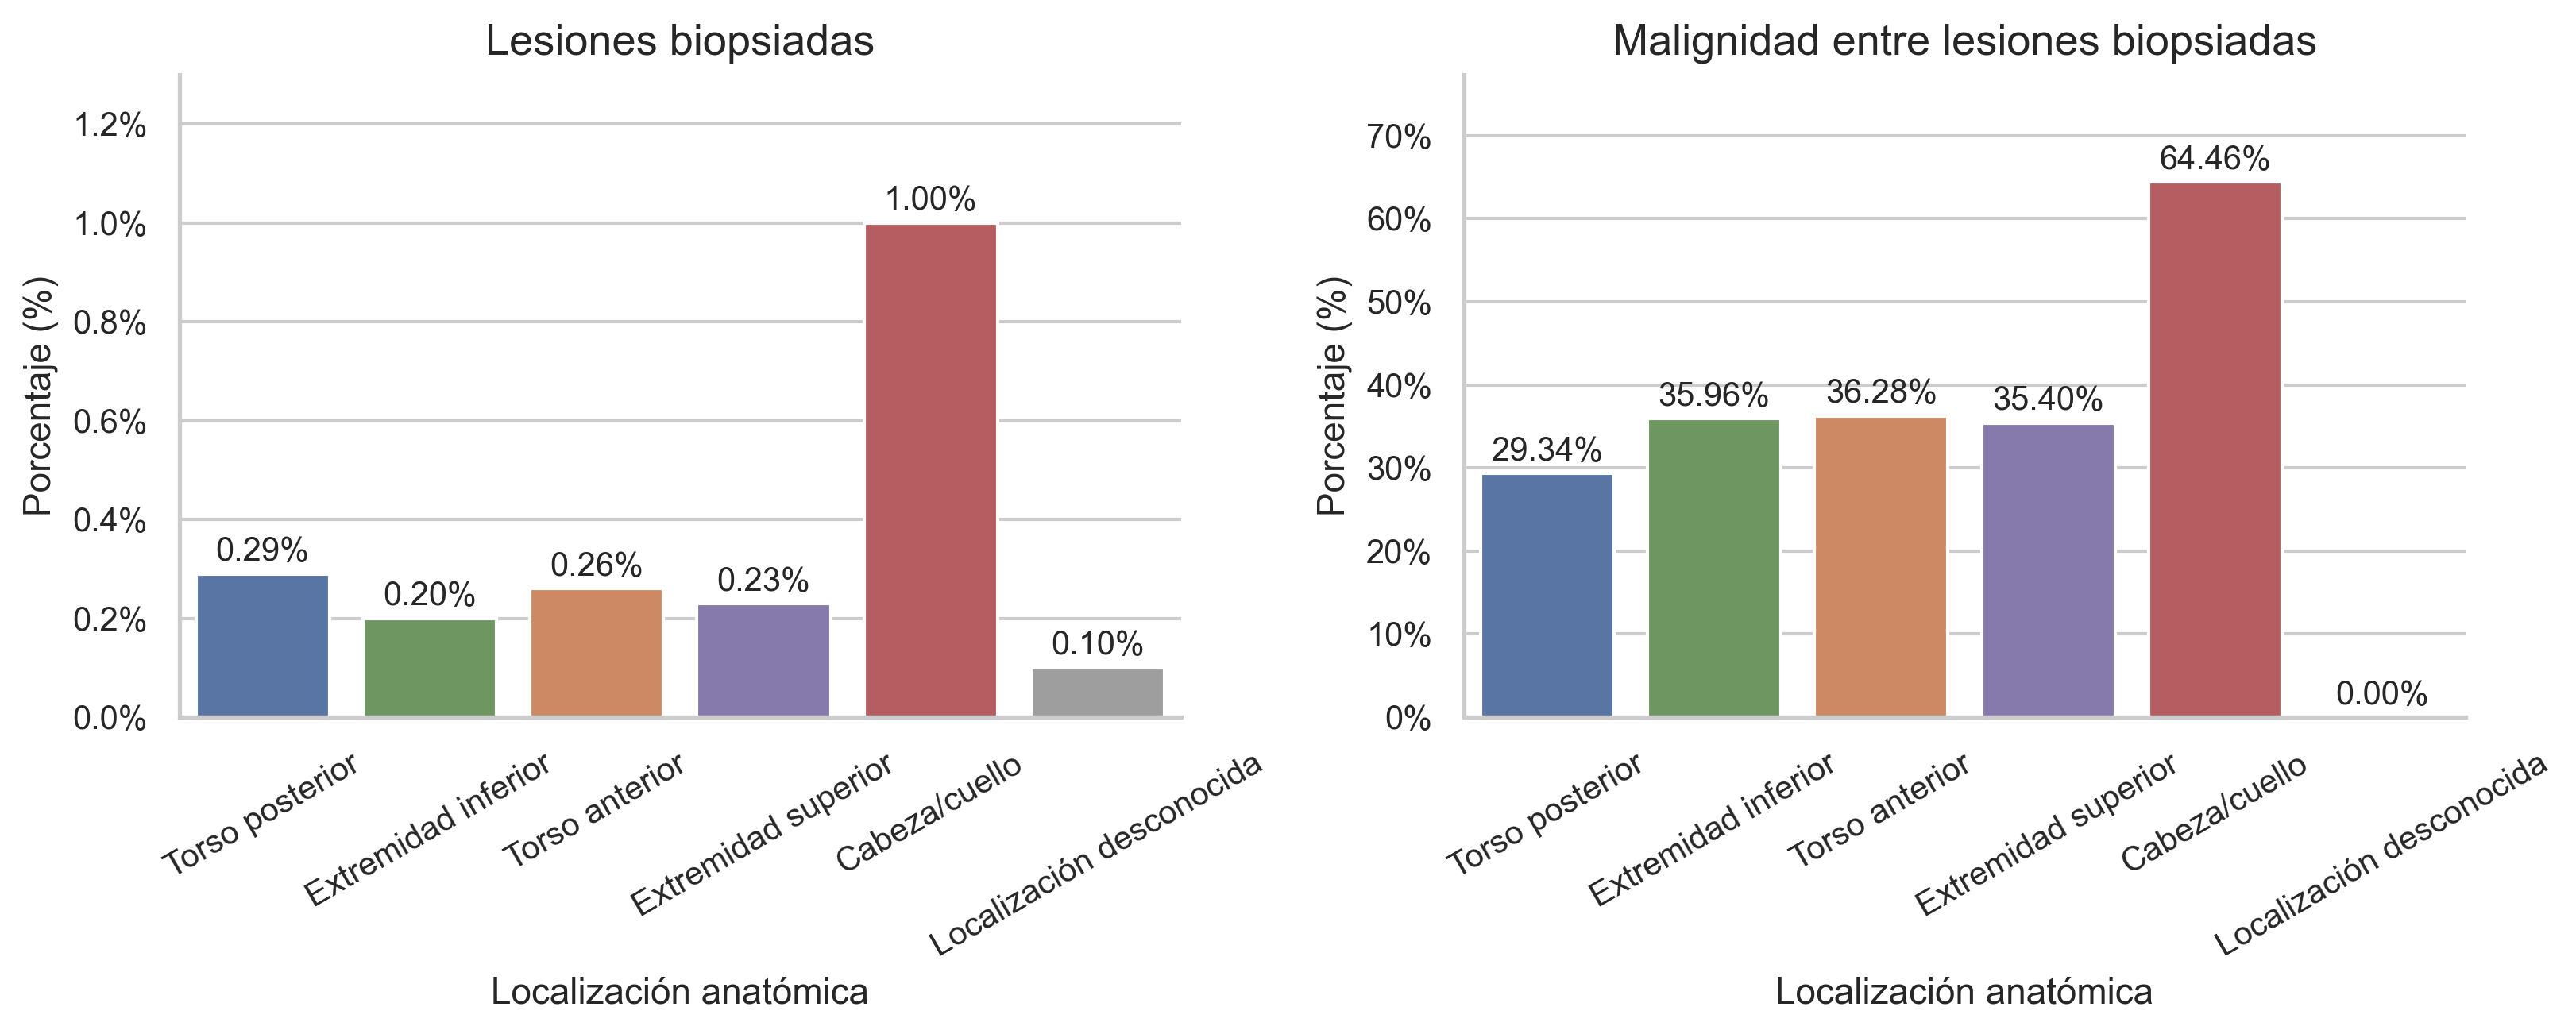

In [248]:
# Predictive value of anatomical site

anatom_predictive_plot_df = anatom_predictive_summary_formatted.copy()

anatom_predictive_plot_df["anatom_site_label"] = anatom_predictive_plot_df[
    "anatom_site_general_display"
].map(ANATOM_SITE_DISPLAY_LABELS)

anatom_predictive_plot_df["anatom_site_label"] = pd.Categorical(
    anatom_predictive_plot_df["anatom_site_label"],
    categories=ANATOM_SITE_ORDER,
    ordered=True,
)

anatom_predictive_plot_df = anatom_predictive_plot_df.sort_values(
    "anatom_site_label"
).reset_index(drop=True)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)

# Biopsy rate
sns.barplot(
    data=anatom_predictive_plot_df,
    x="anatom_site_label",
    y="biopsied_pct",
    hue="anatom_site_label",
    palette=ANATOM_SITE_PALETTE,
    legend=False,
    ax=axes[0],
    dodge=False,
)

add_bar_labels(
    axes[0],
    fmt="{:.2f}",
    suffix="%",
)

clean_axis_labels(
    axes[0],
    xlabel="Localización anatómica",
    ylabel="Porcentaje (%)",
    title="Lesiones biopsiadas",
)

format_percent_axis(
    axes[0],
    axis="y",
    decimals=1,
)

axes[0].set_ylim(
    0,
    anatom_predictive_plot_df["biopsied_pct"].max() * 1.30,
)

axes[0].tick_params(axis="x", rotation=30)

# Malignancy rate among biopsied lesions
sns.barplot(
    data=anatom_predictive_plot_df,
    x="anatom_site_label",
    y="malignant_pct",
    hue="anatom_site_label",
    palette=ANATOM_SITE_PALETTE,
    legend=False,
    ax=axes[1],
    dodge=False,
)

add_bar_labels(
    axes[1],
    fmt="{:.2f}",
    suffix="%",
)

# Manually add labels for zero-height bars using the same style as add_bar_labels()
for patch in axes[1].patches:
    height = patch.get_height()

    if height == 0:
        axes[1].annotate(
            f"{height:.2f}%",
            xy=(
                patch.get_x() + patch.get_width() / 2,
                height,
            ),
            xytext=(0, 2),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=EDA_STYLE["tick_size"],
        )

clean_axis_labels(
    axes[1],
    xlabel="Localización anatómica",
    ylabel="Porcentaje (%)",
    title="Malignidad entre lesiones biopsiadas",
)

format_percent_axis(
    axes[1],
    axis="y",
    decimals=0,
)

axes[1].set_ylim(
    0,
    anatom_predictive_plot_df["malignant_pct"].max() * 1.20,
)

axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

figures["anatom_site_predictive_value"] = fig

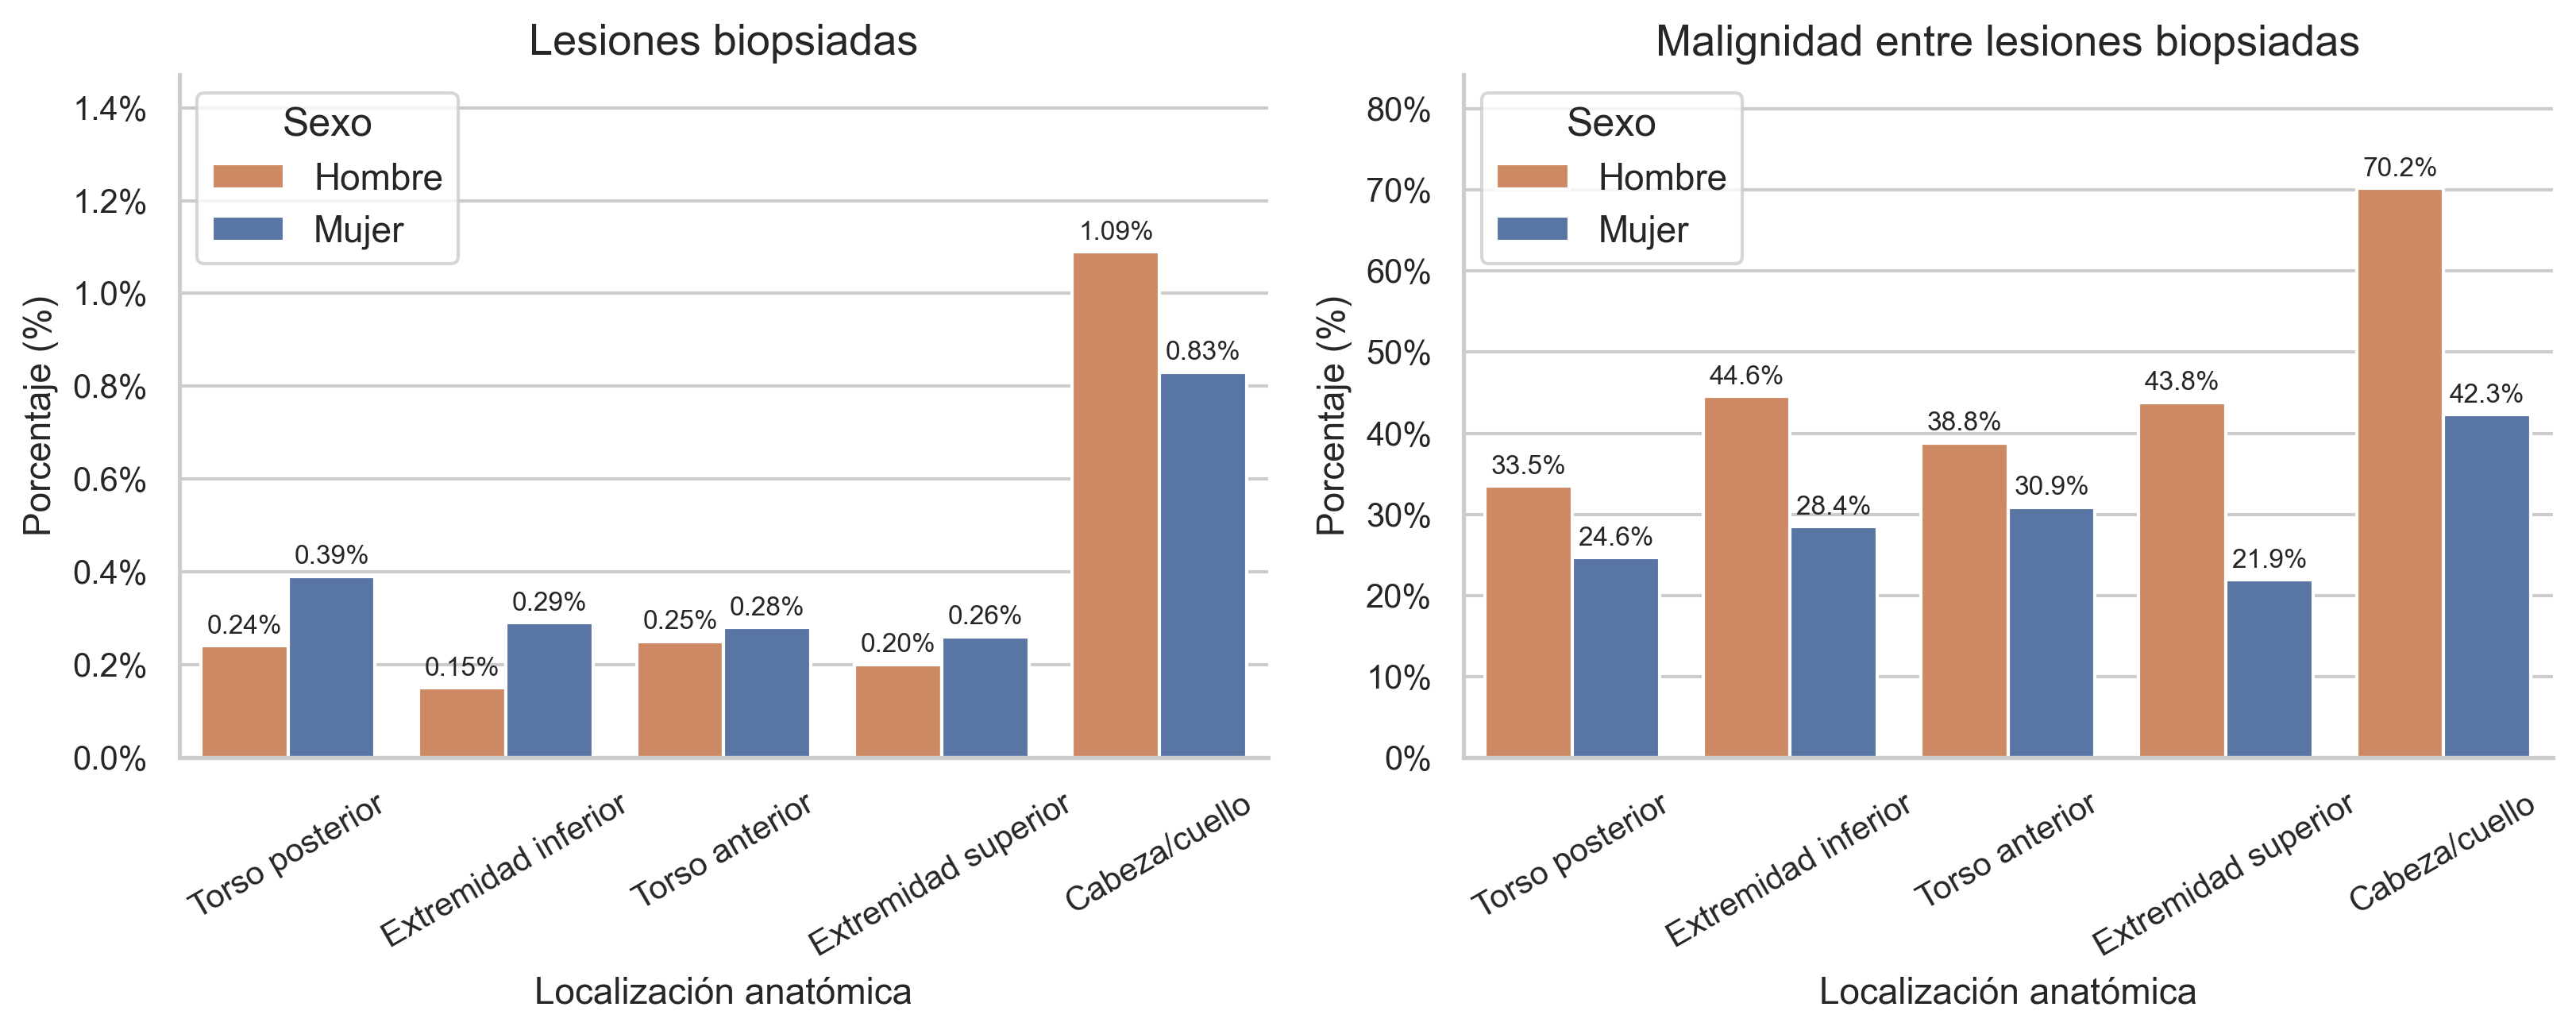

In [249]:
# Predictive value of sex + anatomical site

sex_anatom_plot_df = sex_anatom_predictive_summary_formatted.copy()

sex_anatom_plot_df["sex_label"] = sex_anatom_plot_df["sex_display"].replace(
    {
        "Female": "Mujer",
        "Male": "Hombre",
        "Missing": "Sexo desconocido",
    }
)

sex_anatom_plot_df["anatom_site_label"] = sex_anatom_plot_df[
    "anatom_site_general_display"
].map(ANATOM_SITE_DISPLAY_LABELS)

sex_anatom_plot_df["anatom_site_label"] = pd.Categorical(
    sex_anatom_plot_df["anatom_site_label"],
    categories=[
        "Torso posterior",
        "Extremidad inferior",
        "Torso anterior",
        "Extremidad superior",
        "Cabeza/cuello",
    ],
    ordered=True,
)

sex_anatom_plot_df = sex_anatom_plot_df.sort_values(
    ["anatom_site_label", "sex_label"]
).reset_index(drop=True)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)

# Biopsy rate
sns.barplot(
    data=sex_anatom_plot_df,
    x="anatom_site_label",
    y="biopsied_pct",
    hue="sex_label",
    palette=SEX_PALETTE,
    ax=axes[0],
)

add_bar_labels(
    axes[0],
    fmt="{:.2f}",
    suffix="%",
    fontsize=8,
)

clean_axis_labels(
    axes[0],
    xlabel="Localización anatómica",
    ylabel="Porcentaje (%)",
    title="Lesiones biopsiadas",
)

format_percent_axis(
    axes[0],
    axis="y",
    decimals=1,
)

axes[0].set_ylim(
    0,
    sex_anatom_plot_df["biopsied_pct"].max() * 1.35,
)

axes[0].tick_params(axis="x", rotation=30)

axes[0].legend(
    title="Sexo",
    frameon=True,
    loc="upper left",
)

# Malignancy rate among biopsied lesions
sns.barplot(
    data=sex_anatom_plot_df,
    x="anatom_site_label",
    y="malignant_pct",
    hue="sex_label",
    palette=SEX_PALETTE,
    ax=axes[1],
)

add_bar_labels(
    axes[1],
    fmt="{:.1f}",
    suffix="%",
    fontsize=8,
)

clean_axis_labels(
    axes[1],
    xlabel="Localización anatómica",
    ylabel="Porcentaje (%)",
    title="Malignidad entre lesiones biopsiadas",
)

format_percent_axis(
    axes[1],
    axis="y",
    decimals=0,
)

axes[1].set_ylim(
    0,
    sex_anatom_plot_df["malignant_pct"].max() * 1.20,
)

axes[1].tick_params(axis="x", rotation=30)

axes[1].legend(
    title="Sexo",
    frameon=True,
    loc="upper left",
)

plt.tight_layout()
plt.show()

figures["sex_anatom_site_predictive_value"] = fig

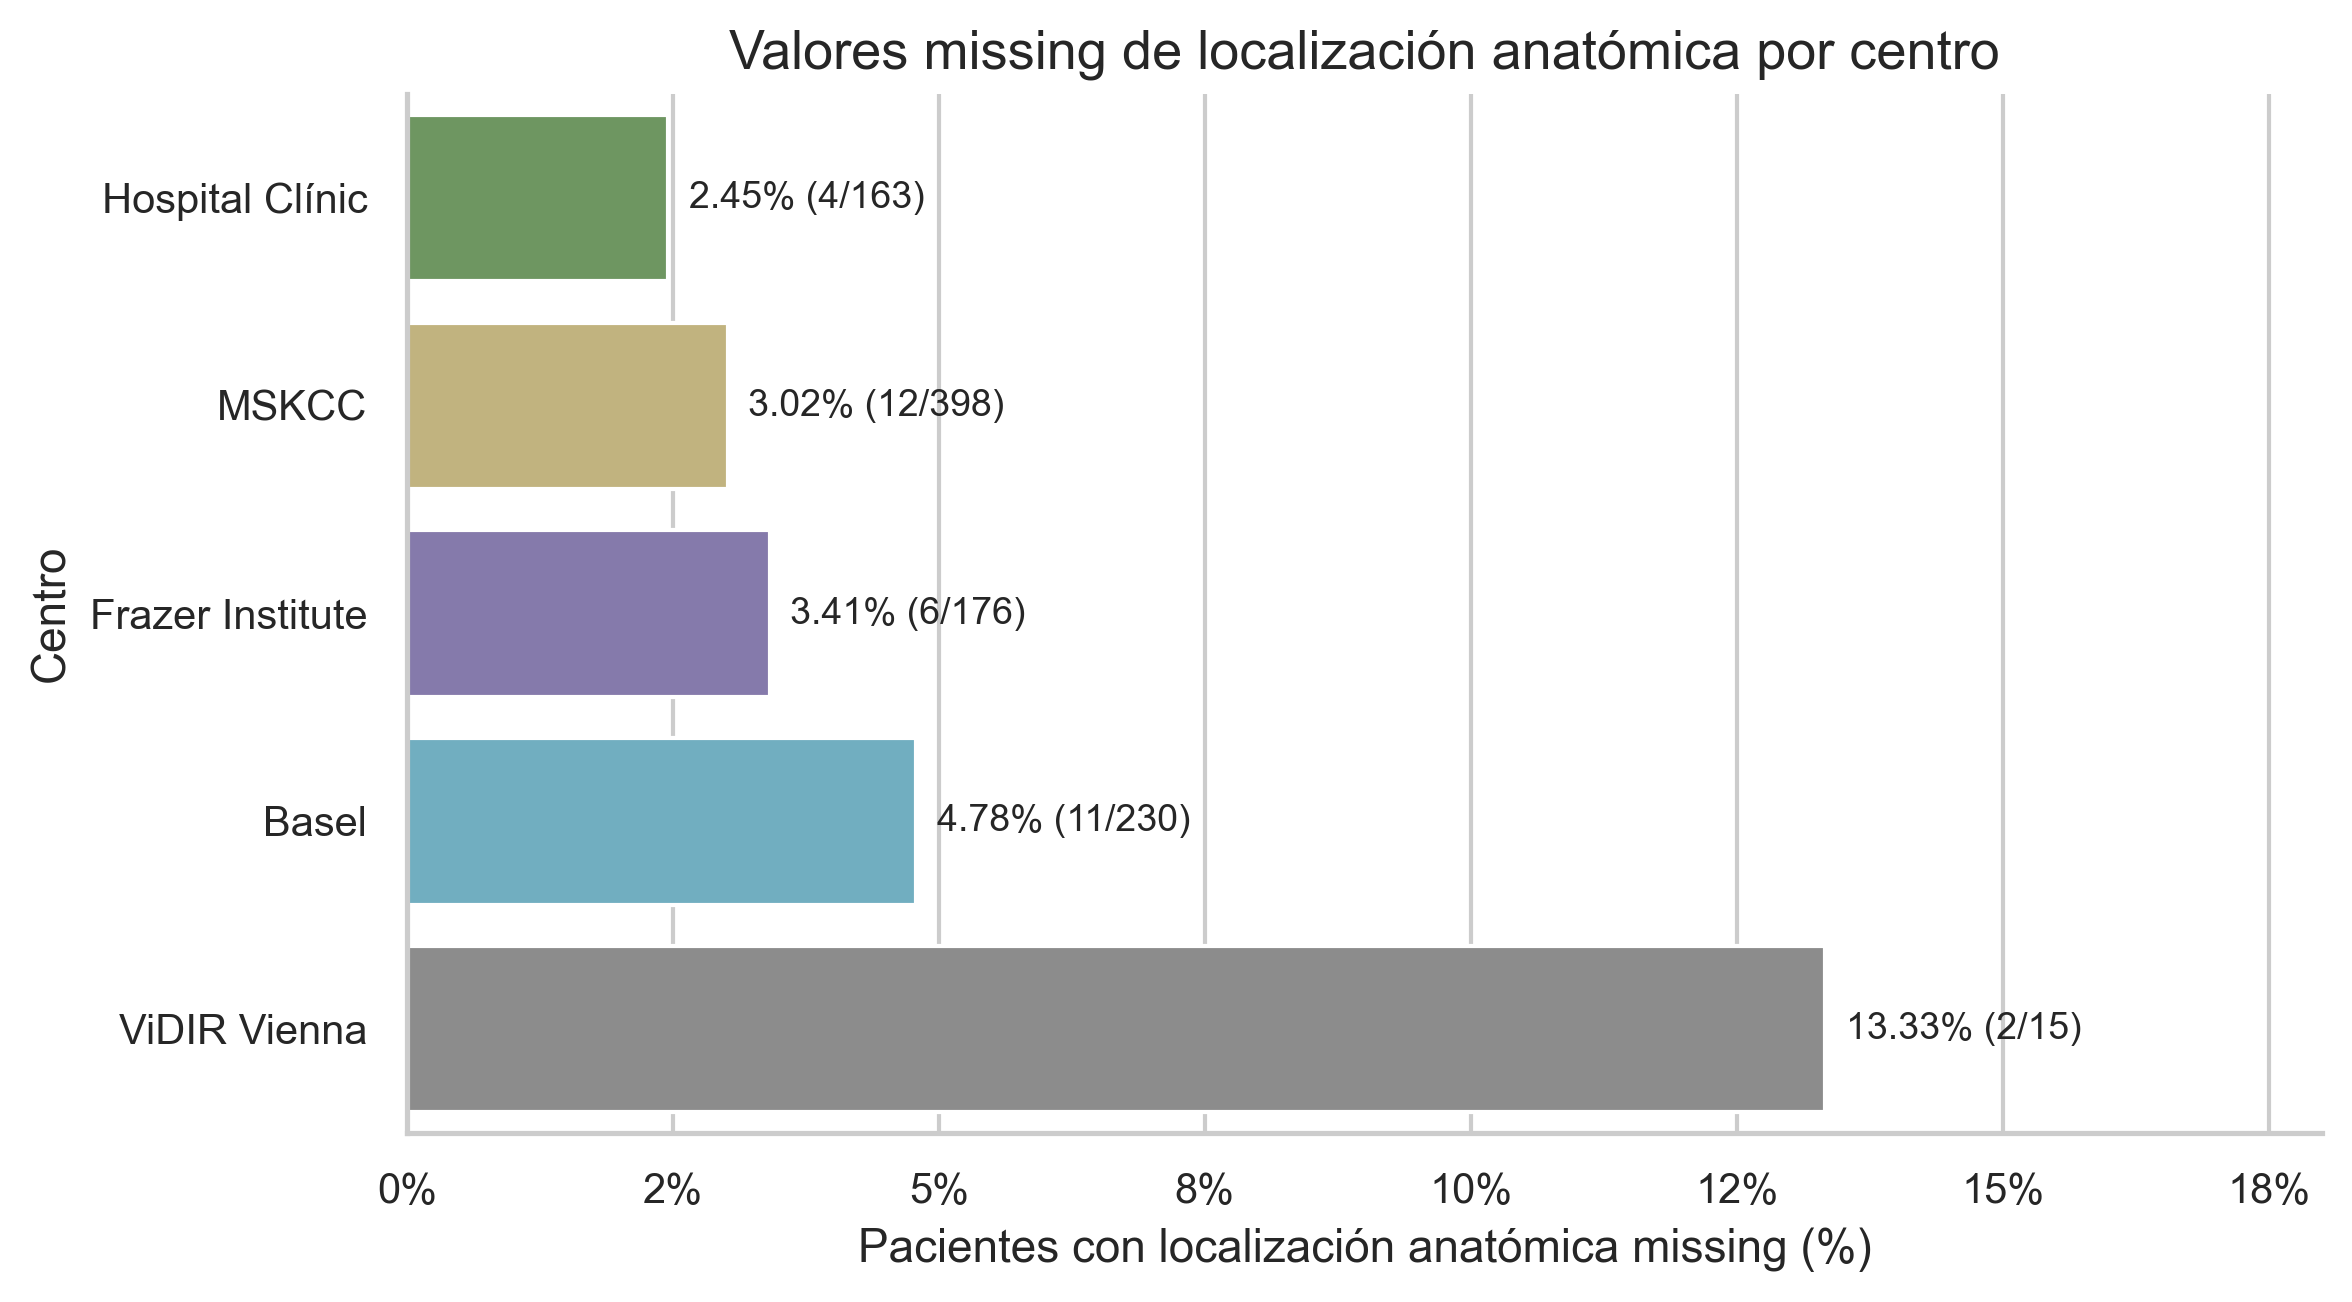

In [250]:
# Missing anatomical site by attribution

anatom_missing_attribution_plot_df = anatom_missing_attribution_patient_summary.copy()

anatom_missing_attribution_plot_df["attribution_label"] = simplify_attribution_series(
    anatom_missing_attribution_plot_df["attribution"]
)

anatom_missing_attribution_plot_df["label"] = (
    anatom_missing_attribution_plot_df["pct_missing_patients"].round(2).astype(str)
    + "% ("
    + anatom_missing_attribution_plot_df["n_patients_with_missing"].astype(str)
    + "/"
    + anatom_missing_attribution_plot_df["n_patients"].astype(str)
    + ")"
)

anatom_missing_attribution_plot_df = anatom_missing_attribution_plot_df.sort_values(
    "pct_missing_patients", ascending=True
).reset_index(drop=True)

fig, ax = plt.subplots(
    figsize=(8, 4.5),
)

sns.barplot(
    data=anatom_missing_attribution_plot_df,
    x="pct_missing_patients",
    y="attribution_label",
    hue="attribution_label",
    palette=ATTRIBUTION_PALETTE,
    legend=False,
    ax=ax,
)

for patch, (_, row) in zip(
    ax.patches,
    anatom_missing_attribution_plot_df.iterrows(),
):
    width = patch.get_width()

    ax.annotate(
        row["label"],
        xy=(
            width,
            patch.get_y() + patch.get_height() / 2,
        ),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

clean_axis_labels(
    ax,
    xlabel="Pacientes con localización anatómica missing (%)",
    ylabel="Centro",
    title="Valores missing de localización anatómica por centro",
)

format_percent_axis(
    ax,
    axis="x",
    decimals=0,
)

ax.set_xlim(
    0,
    anatom_missing_attribution_plot_df["pct_missing_patients"].max() * 1.35,
)

plt.tight_layout()
plt.show()

figures["anatom_site_missing_attribution"] = fig

# LESION SIZE

### 1) BASIC DESCRIPTION

In [113]:
df["clin_size_long_diam_mm"].dtype

dtype('float64')

In [114]:
print(df["clin_size_long_diam_mm"].describe())

count    401059.000000
mean          3.930827
std           1.743068
min           1.000000
25%           2.840000
50%           3.370000
75%           4.380000
max          28.400000
Name: clin_size_long_diam_mm, dtype: float64


| Atributo               | Valor                                             |
| ---------------------- | ------------------------------------------------- |
| Nombre de la variable  | `clin_size_long_diam_mm`                          |
| Tipo de variable       | Cuantitativa                                      |
| Subtipo                | Continua                                          |
| Tipo de almacenamiento | `float`                                           |
| Rango de valores       | 1.0–28.4 mm                                       |
| Presencia de missing   | No                                                |
| Nivel de observación   | Variable de lesión registrada a nivel de lesión   |

### 2) DISTRIBUTION

In [116]:
size_var = "clin_size_long_diam_mm"

size_values = df[size_var].dropna()

q1 = size_values.quantile(0.25)
q3 = size_values.quantile(0.75)
iqr = q3 - q1

size_descriptive_summary = pd.DataFrame(
    {
        "n": [size_values.size],
        "missing": [df[size_var].isna().sum()],
        "n_unique": [size_values.nunique()],
        "mean_mm": [size_values.mean()],
        "std_mm": [size_values.std()],
        "min_mm": [size_values.min()],
        "q1_mm": [q1],
        "median_mm": [size_values.median()],
        "q3_mm": [q3],
        "max_mm": [size_values.max()],
        "iqr_mm": [iqr],
        "skewness": [size_values.skew()],
        "kurtosis": [size_values.kurt()],
    }
)

print(size_descriptive_summary.round(3))

        n  missing  n_unique  mean_mm  std_mm  min_mm  q1_mm  median_mm  \
0  401059        0      1758    3.931   1.743     1.0   2.84       3.37   

   q3_mm  max_mm  iqr_mm  skewness  kurtosis  
0   4.38    28.4    1.54     2.832    12.529  


In [118]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_size = df.assign(
    size_outlier=((df[size_var] < lower_bound) | (df[size_var] > upper_bound))
)

n_size_outliers = df_size["size_outlier"].sum()

size_outlier_summary = pd.DataFrame(
    {
        "lower_bound_mm": [lower_bound],
        "upper_bound_mm": [upper_bound],
        "n_outliers": [n_size_outliers],
        "percentage_outliers": [100 * n_size_outliers / len(df_size)],
        "min_outlier_mm": [df_size.loc[df_size["size_outlier"], size_var].min()],
        "max_outlier_mm": [df_size.loc[df_size["size_outlier"], size_var].max()],
    }
)

print(size_outlier_summary.round(3))

   lower_bound_mm  upper_bound_mm  n_outliers  percentage_outliers  \
0            0.53            6.69       27365                6.823   

   min_outlier_mm  max_outlier_mm  
0            6.69            28.4  


In [119]:
size_outlier_values = (
    df_size.loc[df_size["size_outlier"], size_var]
    .value_counts()
    .sort_index()
    .rename_axis(size_var)
    .reset_index(name="n_lesions")
)

print(size_outlier_values)

      clin_size_long_diam_mm  n_lesions
0                       6.69        101
1                       6.70        337
2                       6.71        254
3                       6.72        125
4                       6.73         86
...                      ...        ...
1189                   24.88          1
1190                   25.00          1
1191                   26.22          1
1192                   28.04          1
1193                   28.40          1

[1194 rows x 2 columns]


In [120]:
size_outliers_by_diagnostic_group = (
    df_size.groupby("diagnostic_group")
    .agg(
        n_lesions=("isic_id", "size"),
        n_outliers=("size_outlier", "sum"),
    )
    .assign(percentage_outliers=lambda x: 100 * x["n_outliers"] / x["n_lesions"])
    .reset_index()
    .sort_values("percentage_outliers", ascending=False)
)

print(size_outliers_by_diagnostic_group.round(3))

         diagnostic_group  n_lesions  n_outliers  percentage_outliers
3      malignant_biopsied        393         133               33.842
0         benign_biopsied        561         169               30.125
2  indeterminate_biopsied        114          28               24.561
1     benign_non_biopsied     399991       27035                6.759


In [122]:
size_transformation_summary = pd.DataFrame(
    {
        "representation": [
            "Original",
            "Log1p",
        ],
        "skewness": [
            size_values.skew(),
            np.log1p(size_values).skew(),
        ],
        "kurtosis": [
            size_values.kurt(),
            np.log1p(size_values).kurt(),
        ],
        "mean": [
            size_values.mean(),
            np.log1p(size_values).mean(),
        ],
        "std": [
            size_values.std(),
            np.log1p(size_values).std(),
        ],
    }
)

print(size_transformation_summary.round(3))

  representation  skewness  kurtosis   mean    std
0       Original     2.832    12.529  3.931  1.743
1          Log1p     1.382     2.414  1.551  0.280


In [123]:
size_upper_percentiles = (
    size_values.quantile(
        [
            0.90,
            0.95,
            0.975,
            0.99,
            0.995,
            0.999,
        ]
    )
    .rename("diameter_mm")
    .reset_index()
    .rename(columns={"index": "percentile"})
)

print(size_upper_percentiles)

   percentile  diameter_mm
0       0.900         5.93
1       0.950         7.30
2       0.975         8.77
3       0.990        10.95
4       0.995        12.60
5       0.999        16.40


In [124]:
# Descriptive statistics by diagnostic group

size_by_diagnostic_group = (
    df_size.groupby("diagnostic_group")[size_var]
    .agg(
        n="size",
        mean="mean",
        std="std",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        min="min",
        max="max",
        skewness="skew",
    )
    .reset_index()
)

size_by_diagnostic_group["iqr"] = (
    size_by_diagnostic_group["q3"] - size_by_diagnostic_group["q1"]
)

print(size_by_diagnostic_group.round(3))

         diagnostic_group       n   mean    std  median    q1    q3   min  \
0         benign_biopsied     561  5.668  3.158    5.13  3.40  7.31  1.00   
1     benign_non_biopsied  399991  3.926  1.734    3.37  2.84  4.38  1.00   
2  indeterminate_biopsied     114  4.983  3.219    4.18  2.60  6.64  1.04   
3      malignant_biopsied     393  5.750  3.902    5.14  2.40  7.87  1.01   

     max  skewness   iqr  
0  19.80     1.107  3.91  
1  28.40     2.836  1.54  
2  17.86     1.415  4.04  
3  18.94     0.916  5.47  


In [126]:
# Diagnostic composition among outliers and non-outliers

size_outlier_target_summary = (
    df_size.groupby(["size_outlier", "diagnostic_group"])
    .size()
    .rename("n_lesions")
    .reset_index()
)

size_outlier_target_summary["percentage_within_outlier_group"] = (
    100
    * size_outlier_target_summary["n_lesions"]
    / size_outlier_target_summary.groupby("size_outlier")["n_lesions"].transform("sum")
)

print(size_outlier_target_summary)

   size_outlier        diagnostic_group  n_lesions  \
0         False         benign_biopsied        392   
1         False     benign_non_biopsied     372956   
2         False  indeterminate_biopsied         86   
3         False      malignant_biopsied        260   
4          True         benign_biopsied        169   
5          True     benign_non_biopsied      27035   
6          True  indeterminate_biopsied         28   
7          True      malignant_biopsied        133   

   percentage_within_outlier_group  
0                         0.104899  
1                        99.802512  
2                         0.023013  
3                         0.069576  
4                         0.617577  
5                        98.794080  
6                         0.102320  
7                         0.486022  


In [127]:
# Biopsy and malignancy rates among outliers

df_size["biopsied"] = df_size["diagnostic_group"] != "benign_non_biopsied"

df_size["malignant"] = df_size["diagnostic_group"] == "malignant_biopsied"

size_outlier_rates = (
    df_size.groupby("size_outlier")
    .agg(
        n_lesions=("isic_id", "size"),
        biopsy_rate=("biopsied", "mean"),
        malignancy_rate_all=("malignant", "mean"),
    )
    .reset_index()
)

size_outlier_rates["biopsy_rate_pct"] = 100 * size_outlier_rates["biopsy_rate"]

size_outlier_rates["malignancy_rate_all_pct"] = (
    100 * size_outlier_rates["malignancy_rate_all"]
)

print(size_outlier_rates)

   size_outlier  n_lesions  biopsy_rate  malignancy_rate_all  biopsy_rate_pct  \
0         False     373694     0.001975             0.000696         0.197488   
1          True      27365     0.012059              0.00486          1.20592   

   malignancy_rate_all_pct  
0                 0.069576  
1                 0.486022  


In [128]:
# Malignancy rate among biopsied lesions only

size_outlier_malignancy_biopsied = (
    df_size.loc[df_size["biopsied"]]
    .groupby("size_outlier")
    .agg(
        n_biopsied=("isic_id", "size"),
        n_malignant=("malignant", "sum"),
    )
    .reset_index()
)

size_outlier_malignancy_biopsied["malignancy_rate_pct"] = (
    100
    * size_outlier_malignancy_biopsied["n_malignant"]
    / size_outlier_malignancy_biopsied["n_biopsied"]
)

print(size_outlier_malignancy_biopsied)

   size_outlier  n_biopsied  n_malignant  malignancy_rate_pct
0         False         738          260            35.230352
1          True         330          133             40.30303


In [129]:
# Extreme lesions above 20 mm

extreme_size_lesions = df_size.loc[
    df_size[size_var] > 20,
    [
        "isic_id",
        "patient_id",
        "attribution",
        size_var,
        "diagnostic_group",
    ],
].sort_values(size_var, ascending=False)

print(extreme_size_lesions)

             isic_id  patient_id  \
169920  ISIC_4286735  IP_6207479   
38727   ISIC_1026589  IP_0218255   
106870  ISIC_2720579  IP_6723298   
303441  ISIC_7588019  IP_8565023   
174224  ISIC_4394489  IP_7629874   
...              ...         ...   
209308  ISIC_5264696  IP_0669361   
248807  ISIC_6252131  IP_9552666   
254353  ISIC_6388363  IP_1225710   
205770  ISIC_5176302  IP_3357012   
83105   ISIC_2130428  IP_7205082   

                                              attribution  \
169920                       University Hospital of Basel   
38727                                          ACEMID MIA   
106870             Memorial Sloan Kettering Cancer Center   
303441                       University Hospital of Basel   
174224             Memorial Sloan Kettering Cancer Center   
...                                                   ...   
209308  Frazer Institute, The University of Queensland...   
248807  Department of Dermatology, Hospital Clínic de ...   
254353  Department

In [147]:
size_original = df["clin_size_long_diam_mm"].dropna()
size_log1p = np.log1p(size_original)

size_distribution_comparison = pd.DataFrame(
    {
        "Representación": [
            "Original (mm)",
            "log1p",
        ],
        "n": [
            size_original.size,
            size_log1p.size,
        ],
        "Media": [
            size_original.mean(),
            size_log1p.mean(),
        ],
        "DE": [
            size_original.std(),
            size_log1p.std(),
        ],
        "Mediana": [
            size_original.median(),
            size_log1p.median(),
        ],
        "Q1": [
            size_original.quantile(0.25),
            size_log1p.quantile(0.25),
        ],
        "Q3": [
            size_original.quantile(0.75),
            size_log1p.quantile(0.75),
        ],
        "IQR": [
            size_original.quantile(0.75) - size_original.quantile(0.25),
            size_log1p.quantile(0.75) - size_log1p.quantile(0.25),
        ],
        "Mínimo": [
            size_original.min(),
            size_log1p.min(),
        ],
        "Máximo": [
            size_original.max(),
            size_log1p.max(),
        ],
        "Skewness": [
            size_original.skew(),
            size_log1p.skew(),
        ],
        "Kurtosis": [
            size_original.kurt(),
            size_log1p.kurt(),
        ],
    }
)

print(size_distribution_comparison.round(3))

  Representación       n  Media     DE  Mediana     Q1     Q3    IQR  Mínimo  \
0  Original (mm)  401059  3.931  1.743    3.370  2.840  4.380  1.540   1.000   
1          log1p  401059  1.551  0.280    1.475  1.345  1.683  0.337   0.693   

   Máximo  Skewness  Kurtosis  
0  28.400     2.832    12.529  
1   3.381     1.382     2.414  


#### Distribución de `clin_size_long_diam_mm`

La variable `clin_size_long_diam_mm` representa el diámetro máximo aproximado de la lesión, expresado en milímetros. Se trata de una variable cuantitativa continua, registrada a nivel de lesión y sin valores missing.

| Valores válidos (n) | Valores únicos (n) | Media ± DE (mm) | Mediana [IQR] (mm) | Rango (mm) | Skewness | Kurtosis |
| ------------------: | -----------------: | --------------: | -----------------: | ---------: | -------: | -------: |
|             401,059 |              1,758 |     3.93 ± 1.74 |   3.37 [2.84–4.38] | 1.00–28.40 |     2.83 |    12.53 |

**Tabla XX. Resumen descriptivo de `clin_size_long_diam_mm`.** DE: desviación estándar; IQR: rango intercuartílico. La desviación estándar, la *skewness* y la *kurtosis* se calcularon utilizando sus estimadores muestrales.

La mayoría de las lesiones presentan diámetros reducidos, con un 50% de los valores comprendidos entre 2.84 y 4.38 mm. La media es superior a la mediana y la distribución presenta una asimetría positiva marcada, lo que indica la presencia de una cola prolongada hacia lesiones de mayor tamaño. La elevada *kurtosis* refleja asimismo una concentración importante de valores alrededor del centro de la distribución combinada con una cola superior más pesada.

Los percentiles superiores permiten caracterizar mejor esta cola:

| Percentil | Diámetro (mm) |
| --------: | ------------: |
|        90 |          5.93 |
|        95 |          7.30 |
|      97.5 |          8.77 |
|        99 |         10.95 |
|      99.5 |         12.60 |
|      99.9 |         16.40 |

**Tabla XX. Percentiles superiores de la distribución del diámetro máximo de la lesión.**

Aunque la distribución contiene valores elevados, estos son poco frecuentes. Solo el 1% de las lesiones supera aproximadamente los 11 mm y el 0.1% supera los 16.4 mm. Además, únicamente 79 lesiones presentan diámetros superiores a 20 mm y el valor máximo observado es 28.4 mm. Estos valores son clínicamente plausibles y no sugieren, por sí solos, errores de registro.

#### Análisis de valores extremos

Aplicando la regla de 1.5 veces el rango intercuartílico, el límite superior se sitúa en 6.69 mm. No se identifican outliers inferiores, mientras que 27,365 lesiones superan este umbral.

| Límite inferior (mm) | Límite superior (mm) | Outliers (n) | Outliers (%) | Rango de outliers (mm) |
| -------------------: | -------------------: | -----------: | -----------: | ---------------------: |
|                 0.53 |                 6.69 |       27,365 |         6.82 |             6.69–28.40 |

**Tabla XX. Identificación de valores extremos mediante la regla de 1.5 × IQR.**

La proporción de outliers es considerable, pero su interpretación debe hacerse con cautela. En este caso, el criterio estadístico identifica como extremos numerosos valores que continúan siendo clínicamente plausibles. Además, las lesiones de mayor tamaño aparecen con mayor frecuencia entre las categorías biopsiadas:

| Categoría diagnóstica  | Lesiones (n) | Outliers (n) | Outliers (%) |
| ---------------------- | -----------: | -----------: | -----------: |
| Benign non-biopsied    |      399,991 |       27,035 |         6.76 |
| Benign biopsied        |          561 |          169 |        30.12 |
| Indeterminate biopsied |          114 |           28 |        24.56 |
| Malignant biopsied     |          393 |          133 |        33.84 |

**Tabla XX. Frecuencia de valores extremos de `clin_size_long_diam_mm` según la categoría diagnóstica.** Los outliers se definieron utilizando el límite superior de 6.69 mm.

La frecuencia de valores extremos es aproximadamente cuatro o cinco veces superior entre las lesiones biopsiadas que entre las lesiones benignas no biopsiadas. Esta diferencia sugiere que los diámetros elevados no corresponden simplemente a ruido o errores, sino que pueden contener información clínica relevante.

La misma tendencia se observa al comparar las tasas de biopsia y malignidad:

| Grupo      | Lesiones (n) | Lesiones biopsiadas (%) | Lesiones malignas sobre el total (%) | Malignidad entre biopsiadas (%) |
| ---------- | -----------: | ----------------------: | -----------------------------------: | ------------------------------: |
| No outlier |      373,694 |                    0.20 |                                 0.07 |                           35.23 |
| Outlier    |       27,365 |                    1.21 |                                 0.49 |                           40.30 |

**Tabla XX. Tasas de biopsia y malignidad según la presencia de valores extremos en el diámetro de la lesión.**

Las lesiones clasificadas como outliers presentan una tasa de biopsia claramente superior, pasando del 0.20% al 1.21%. La proporción de lesiones malignas sobre el total también aumenta del 0.07% al 0.49%. Entre las lesiones biopsiadas, la malignidad es algo más frecuente en el grupo outlier, con un 40.30% frente a un 35.23%.

Estos resultados no sustituyen el análisis formal de asociación con las variables objetivo, pero indican que los valores elevados pueden contribuir a la capacidad predictiva de la variable. Por tanto, no se recomienda eliminarlos, truncarlos ni aplicar winsorización de forma automática.

#### Distribución por categoría diagnóstica

| Categoría diagnóstica  |       n | Media ± DE (mm) | Mediana [IQR] (mm) | Rango (mm) | Skewness |
| ---------------------- | ------: | --------------: | -----------------: | ---------: | -------: |
| Benign non-biopsied    | 399,991 |     3.93 ± 1.73 |   3.37 [2.84–4.38] | 1.00–28.40 |     2.84 |
| Benign biopsied        |     561 |     5.67 ± 3.16 |   5.13 [3.40–7.31] | 1.00–19.80 |     1.11 |
| Indeterminate biopsied |     114 |     4.98 ± 3.22 |   4.18 [2.60–6.64] | 1.04–17.86 |     1.42 |
| Malignant biopsied     |     393 |     5.75 ± 3.90 |   5.14 [2.40–7.87] | 1.01–18.94 |     0.92 |

**Tabla XX. Distribución de `clin_size_long_diam_mm` según la categoría diagnóstica.** DE: desviación estándar; IQR: rango intercuartílico.

Las lesiones benignas no biopsiadas presentan los diámetros más pequeños y una dispersión claramente inferior. Por el contrario, las lesiones biopsiadas, tanto benignas como indeterminadas o malignas, muestran medianas, rangos intercuartílicos y desviaciones estándar superiores. Las lesiones malignas biopsiadas presentan la media más elevada y la mayor dispersión.

La asimetría sigue siendo positiva dentro de todas las categorías, aunque es menos marcada en las lesiones biopsiadas que en el conjunto global. La elevada asimetría general está influida principalmente por el gran número de lesiones benignas no biopsiadas y por su prolongada cola derecha.

#### Posible transformación

Se evaluó una transformación `log1p` para comprobar si reducía la asimetría de la distribución:

| Representación | Skewness | Kurtosis |
| -------------- | -------: | -------: |
| Original       |     2.83 |    12.53 |
| `log1p`        |     1.38 |     2.41 |

**Tabla XX. Comparación de la forma de la distribución original y tras aplicar una transformación `log1p`.**

La transformación reduce de forma importante tanto la asimetría como la curtosis, aunque la distribución continúa presentando cierta asimetría positiva. Por tanto, `log1p` podría resultar útil en modelos lineales o sensibles a la escala, especialmente si se desea reducir la influencia relativa de los valores elevados.

Sin embargo, no es necesario aplicar esta transformación de forma general a todos los algoritmos. Los modelos basados en árboles pueden utilizar directamente la variable original, mientras que en modelos lineales, KNN, SVM o redes neuronales convendría comparar empíricamente el rendimiento de la variable original estandarizada frente a su versión `log1p` estandarizada.

En conjunto, `clin_size_long_diam_mm` presenta una distribución fuertemente asimétrica a la derecha, pero sin valores clínicamente inverosímiles. Los valores identificados como outliers parecen contener información potencialmente útil para la clasificación y deben conservarse. La transformación final debería decidirse dentro del pipeline según las necesidades y el comportamiento del modelo utilizado.


### 3) CLASSIFICATION

In [132]:
size_var = "clin_size_long_diam_mm"

df_size_model = df.copy()

# Hypothesis 1: biopsy recommendation
df_size_model["biopsy_target"] = np.where(
    df_size_model["diagnostic_group"].eq("benign_non_biopsied"),
    0,
    1,
)

# Hypothesis 2: malignancy among biopsied lesions
df_size_biopsied = df_size_model.loc[
    df_size_model["diagnostic_group"].isin(
        [
            "benign_biopsied",
            "indeterminate_biopsied",
            "malignant_biopsied",
        ]
    )
].copy()

df_size_biopsied["malignancy_target"] = np.where(
    df_size_biopsied["diagnostic_group"].eq("malignant_biopsied"),
    1,
    0,
)


def rank_biserial_correlation(
    group_0: pd.Series,
    group_1: pd.Series,
) -> float:
    """
    Compute rank-biserial correlation from the Mann–Whitney U statistic.

    Positive values indicate that group 1 tends to present larger values
    than group 0.
    """

    group_0 = group_0.dropna()
    group_1 = group_1.dropna()

    u_statistic, _ = stats.mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided",
    )

    return 1 - (2 * u_statistic / (len(group_0) * len(group_1)))


def compare_size_groups(
    data: pd.DataFrame,
    target_col: str,
    analysis_name: str,
) -> pd.DataFrame:
    """
    Compare lesion size between the negative and positive classes
    of a binary target.
    """

    group_0 = data.loc[data[target_col] == 0, size_var]
    group_1 = data.loc[data[target_col] == 1, size_var]

    mann_whitney = stats.mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided",
    )

    point_biserial = stats.pointbiserialr(
        data[target_col],
        data[size_var],
    )

    spearman = stats.spearmanr(
        data[size_var],
        data[target_col],
    )

    rank_biserial = rank_biserial_correlation(
        group_0,
        group_1,
    )

    return pd.DataFrame(
        {
            "Análisis": [analysis_name],
            "Mediana grupo negativo (mm)": [group_0.median()],
            "Mediana grupo positivo (mm)": [group_1.median()],
            "Mann–Whitney p": [mann_whitney.pvalue],
            "Correlación rank-biserial": [rank_biserial],
            "Correlación punto-biserial": [point_biserial.statistic],
            "Spearman": [spearman.statistic],
        }
    )

In [133]:
size_association_summary = pd.concat(
    [
        compare_size_groups(
            data=df_size_model,
            target_col="biopsy_target",
            analysis_name="Tamaño vs biopsia",
        ),
        compare_size_groups(
            data=df_size_biopsied,
            target_col="malignancy_target",
            analysis_name="Tamaño vs malignidad entre biopsiadas",
        ),
    ],
    ignore_index=True,
)

print(size_association_summary.round(4))

                                Análisis  Mediana grupo negativo (mm)  \
0                      Tamaño vs biopsia                         3.37   
1  Tamaño vs malignidad entre biopsiadas                         5.08   

   Mediana grupo positivo (mm)  Mann–Whitney p  Correlación rank-biserial  \
0                         5.10          0.0000                     0.2919   
1                         5.14          0.6653                    -0.0159   

   Correlación punto-biserial  Spearman  
0                      0.0502    0.0261  
1                      0.0276   -0.0132  


#### Relación de `clin_size_long_diam_mm` con las variables objetivo

La posible utilidad predictiva de `clin_size_long_diam_mm` se evaluó por separado para las dos tareas de clasificación planteadas:

* recomendación de biopsia;
* clasificación de malignidad entre las lesiones biopsiadas.

Dado que la variable presenta una distribución marcadamente asimétrica y contiene numerosos valores elevados, se utilizó el test no paramétrico de Mann–Whitney para comparar ambos grupos. La magnitud de la asociación se complementó mediante la correlación rank-biserial, la correlación punto-biserial y la correlación de Spearman.

| Análisis                              | Mediana grupo negativo (mm) | Mediana grupo positivo (mm) | Mann–Whitney p | Correlación rank-biserial | Correlación punto-biserial | Spearman | Interpretación                                                         |
| ------------------------------------- | --------------------------: | --------------------------: | -------------: | ------------------------: | -------------------------: | -------: | ---------------------------------------------------------------------- |
| Tamaño vs biopsia                     |                        3.37 |                        5.10 |        <0.0001 |                    0.2919 |                     0.0502 |   0.0261 | Diferencia moderada entre distribuciones, pero asociación global débil |
| Tamaño vs malignidad entre biopsiadas |                        5.08 |                        5.14 |         0.6653 |                   -0.0159 |                     0.0276 |  -0.0132 | Ausencia de asociación relevante                                       |

**Tabla XX. Asociación entre `clin_size_long_diam_mm` y las variables objetivo de las dos hipótesis de clasificación.** La correlación rank-biserial cuantifica la separación entre las distribuciones comparadas mediante el test de Mann–Whitney. La correlación punto-biserial evalúa la asociación lineal entre el diámetro y el target binario, mientras que Spearman evalúa una posible relación monotónica.

#### Hipótesis 1: recomendación de biopsia

Las lesiones biopsiadas presentan un diámetro claramente superior al de las lesiones benignas no biopsiadas, con medianas de 5.10 mm y 3.37 mm, respectivamente. El test de Mann–Whitney identifica diferencias estadísticamente significativas entre ambas distribuciones.

La correlación rank-biserial alcanza un valor de 0.2919, lo que indica una separación moderada entre los dos grupos y confirma que las lesiones biopsiadas tienden a presentar tamaños mayores. Sin embargo, la correlación punto-biserial y la correlación de Spearman son muy reducidas.

Esta aparente discrepancia se explica principalmente por el fuerte desbalanceo de la variable objetivo. Las lesiones biopsiadas representan una proporción muy pequeña del conjunto de datos, de modo que las correlaciones calculadas sobre todas las observaciones quedan fuertemente atenuadas, aunque las distribuciones de ambos grupos sean diferentes.

Por tanto, el diámetro de la lesión contiene información potencialmente útil para la recomendación de biopsia, pero no debería considerarse un predictor suficiente de forma aislada.

#### Hipótesis 2: malignidad entre lesiones biopsiadas

Entre las lesiones biopsiadas, las medianas son prácticamente idénticas: 5.08 mm en las lesiones no malignas y 5.14 mm en las malignas. El test de Mann–Whitney no identifica diferencias estadísticamente significativas entre los grupos.

Las tres medidas de asociación presentan valores próximos a cero, lo que indica que el diámetro máximo, considerado de forma aislada, no permite diferenciar de manera relevante entre lesiones malignas y no malignas dentro de la cohorte biopsiada.

Aunque previamente se observó una proporción ligeramente superior de malignidad entre los valores clasificados como outliers, esta diferencia no se traduce en una relación global consistente entre tamaño y malignidad. Esto sugiere que el posible efecto del tamaño podría ser débil, no lineal o dependiente de la interacción con otras características clínicas o morfológicas.

En conjunto, `clin_size_long_diam_mm` parece aportar información relevante principalmente para la decisión de biopsia, mientras que su utilidad individual para predecir malignidad entre lesiones ya biopsiadas es muy limitada. La variable debe conservarse como predictor potencial, pero su contribución final deberá evaluarse dentro de modelos multivariables y conjuntamente con el resto de características disponibles.


### 4) FINAL SIZE PLOTS AND TABLES

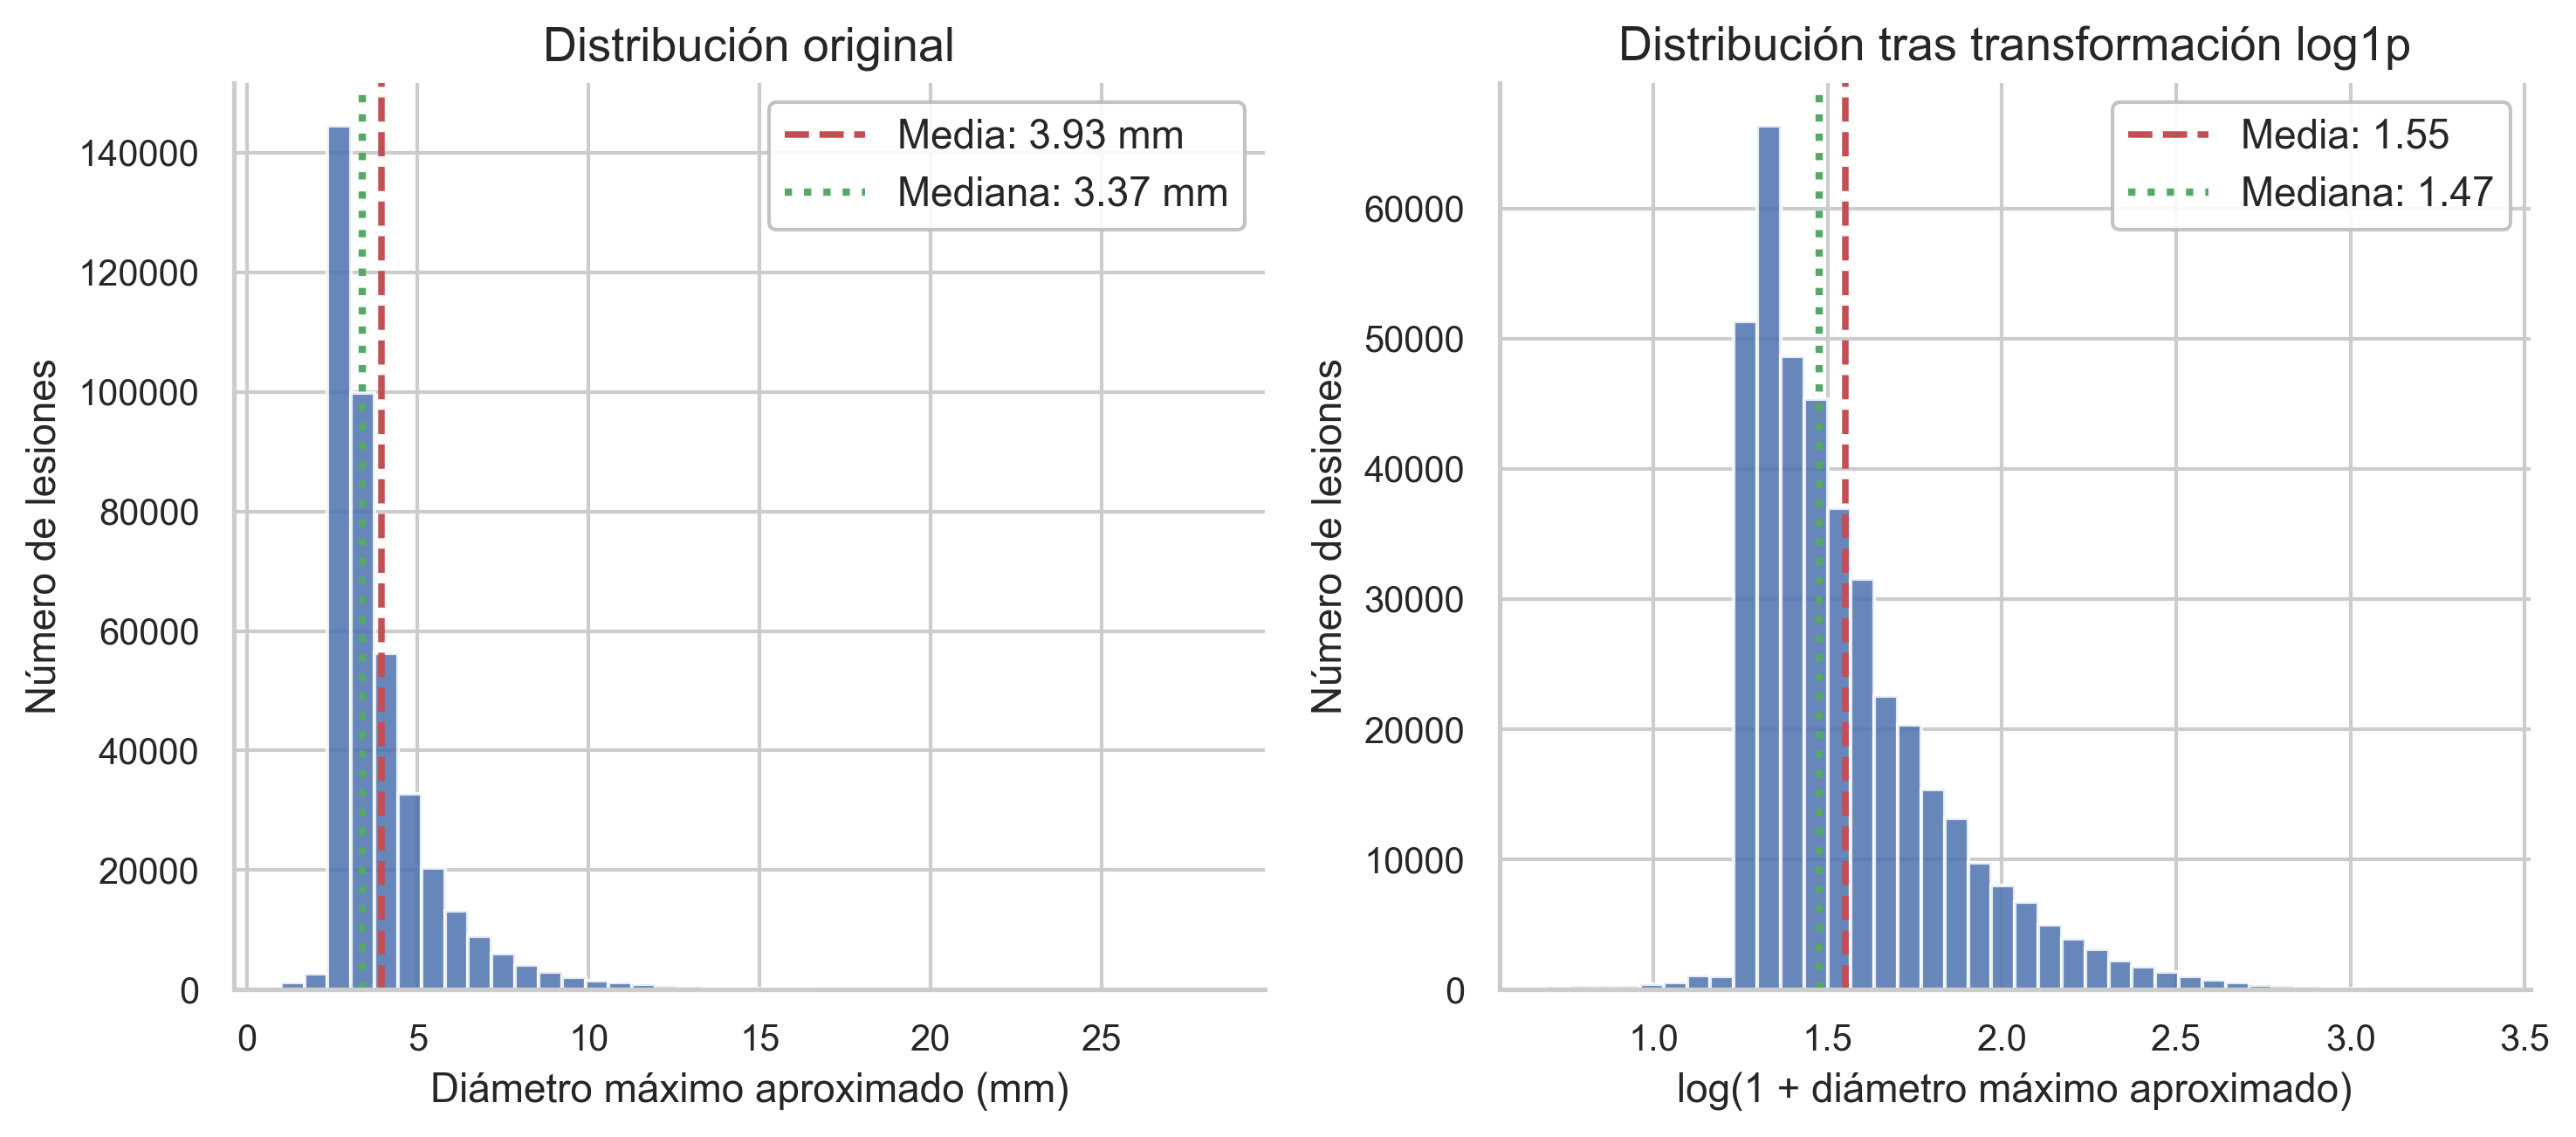

In [166]:
size_var = "clin_size_long_diam_mm"

size_values = df[size_var].dropna()
size_values_log = np.log1p(size_values)

# Original scale statistics
size_mean = size_values.mean()
size_median = size_values.median()

# Log1p scale statistics
size_log_mean = size_values_log.mean()
size_log_median = size_values_log.median()

# Distribution of lesion size: original and log-transformed

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4.5),
)

# Original distribution


axes[0].hist(
    size_values,
    bins=40,
    color=STATISTIC_PALETTE["distribution"],
    alpha=0.85,
    edgecolor="white",
)

axes[0].axvline(
    size_mean,
    color=STATISTIC_PALETTE["mean"],
    linestyle="--",
    linewidth=1.8,
    label=f"Media: {size_mean:.2f} mm",
)

axes[0].axvline(
    size_median,
    color=STATISTIC_PALETTE["median"],
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {size_median:.2f} mm",
)

clean_axis_labels(
    axes[0],
    xlabel="Diámetro máximo aproximado (mm)",
    ylabel="Número de lesiones",
    title="Distribución original",
)

axes[0].legend(
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor="#BDBDBD",
)

# Log-transformed distribution


axes[1].hist(
    size_values_log,
    bins=40,
    color=STATISTIC_PALETTE["distribution"],
    alpha=0.85,
    edgecolor="white",
)

axes[1].axvline(
    size_log_mean,
    color=STATISTIC_PALETTE["mean"],
    linestyle="--",
    linewidth=1.8,
    label=f"Media: {size_log_mean:.2f}",
)

axes[1].axvline(
    size_log_median,
    color=STATISTIC_PALETTE["median"],
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {size_log_median:.2f}",
)

clean_axis_labels(
    axes[1],
    xlabel="log(1 + diámetro máximo aproximado)",
    ylabel="Número de lesiones",
    title="Distribución tras transformación log1p",
)

axes[1].legend(
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor="#BDBDBD",
)

plt.tight_layout()
plt.show()

figures["size_distribution"] = fig

In [163]:
size_var = "clin_size_long_diam_mm"

size_bins = [0, 3, 5, 7, 10, 15, np.inf]

size_labels = [
    "<3 mm",
    "3–<5 mm",
    "5–<7 mm",
    "7–<10 mm",
    "10–<15 mm",
    "≥15 mm",
]

df_size_plot = df.copy()

# Hypothesis 1: biopsy recommendation
df_size_plot["biopsy_target"] = np.where(
    df_size_plot["diagnostic_group"].eq("benign_non_biopsied"),
    0,
    1,
)

df_size_plot["size_group"] = pd.cut(
    df_size_plot[size_var],
    bins=size_bins,
    labels=size_labels,
    right=False,
)

# Hypothesis 2: malignancy among biopsied lesions
df_size_biopsied_plot = df_size_plot.loc[
    df_size_plot["diagnostic_group"].isin(
        [
            "benign_biopsied",
            "indeterminate_biopsied",
            "malignant_biopsied",
        ]
    )
].copy()

df_size_biopsied_plot["malignancy_target"] = np.where(
    df_size_biopsied_plot["diagnostic_group"].eq("malignant_biopsied"),
    1,
    0,
)


def add_wilson_interval(
    table: pd.DataFrame,
    successes_col: str,
    total_col: str,
) -> pd.DataFrame:
    """Add Wilson 95% confidence intervals for proportions."""

    result = table.copy()

    successes = result[successes_col]
    total = result[total_col]
    proportion = successes / total

    z = 1.96
    denominator = 1 + z**2 / total

    centre = (proportion + z**2 / (2 * total)) / denominator

    margin = (
        z
        * np.sqrt(proportion * (1 - proportion) / total + z**2 / (4 * total**2))
        / denominator
    )

    result["ci_lower"] = 100 * (centre - margin)
    result["ci_upper"] = 100 * (centre + margin)

    return result


# Biopsy rate by lesion size group

size_biopsy_rate = (
    df_size_plot.groupby("size_group", observed=True)
    .agg(
        n_lesions=("isic_id", "size"),
        n_biopsied=("biopsy_target", "sum"),
    )
    .reset_index()
)

size_biopsy_rate["biopsy_rate_percentage"] = (
    100 * size_biopsy_rate["n_biopsied"] / size_biopsy_rate["n_lesions"]
)

size_biopsy_rate = add_wilson_interval(
    table=size_biopsy_rate,
    successes_col="n_biopsied",
    total_col="n_lesions",
)

size_biopsy_rate["size_group_display"] = size_biopsy_rate["size_group"].astype(str)

# Biopsy rate by lesion size group

size_biopsy_rate = (
    df_size_plot.groupby("size_group", observed=True)
    .agg(
        n_lesions=("isic_id", "size"),
        n_biopsied=("biopsy_target", "sum"),
    )
    .reset_index()
)

size_biopsy_rate["biopsy_rate_percentage"] = (
    100 * size_biopsy_rate["n_biopsied"] / size_biopsy_rate["n_lesions"]
)

size_biopsy_rate = add_wilson_interval(
    table=size_biopsy_rate,
    successes_col="n_biopsied",
    total_col="n_lesions",
)

size_biopsy_rate["size_group_display"] = size_biopsy_rate["size_group"].astype(str)

# Association measures

biopsy_point_biserial = stats.pointbiserialr(
    df_size_plot["biopsy_target"],
    df_size_plot[size_var],
).statistic

biopsy_spearman = stats.spearmanr(
    df_size_plot[size_var],
    df_size_plot["biopsy_target"],
).statistic

malignancy_point_biserial = stats.pointbiserialr(
    df_size_biopsied_plot["malignancy_target"],
    df_size_biopsied_plot[size_var],
).statistic

malignancy_spearman = stats.spearmanr(
    df_size_biopsied_plot[size_var],
    df_size_biopsied_plot["malignancy_target"],
).statistic

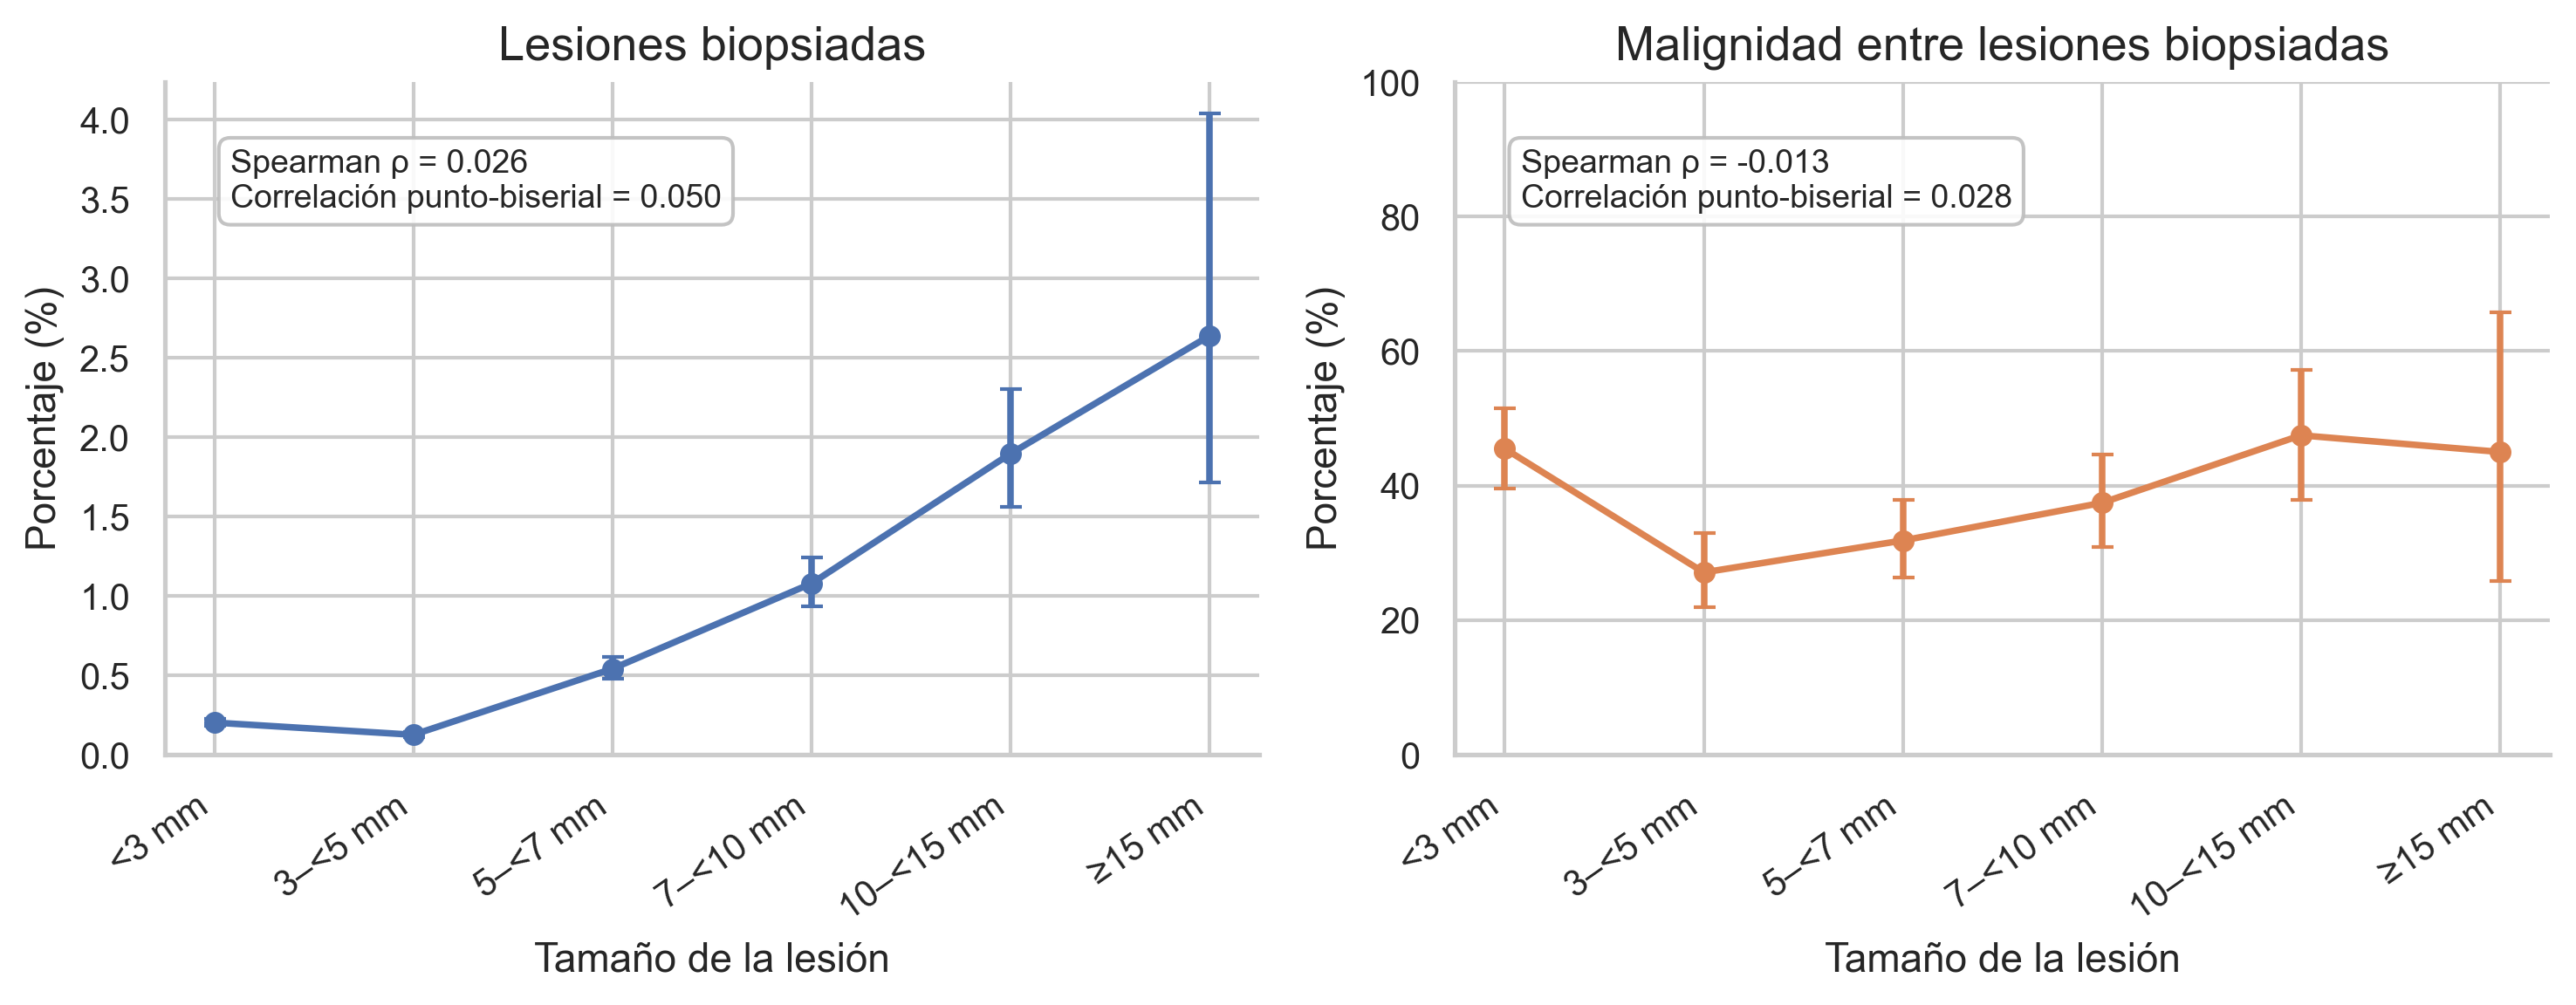

In [164]:
# Lesion size relationship with the two modelling hypotheses

size_malignancy_rate = (
    df_size_biopsied_plot.groupby("size_group", observed=True)
    .agg(
        n_biopsied_lesions=("isic_id", "size"),
        n_malignant=("malignancy_target", "sum"),
    )
    .reset_index()
)

size_malignancy_rate["malignancy_rate_percentage"] = (
    100
    * size_malignancy_rate["n_malignant"]
    / size_malignancy_rate["n_biopsied_lesions"]
)

size_malignancy_rate = add_wilson_interval(
    table=size_malignancy_rate,
    successes_col="n_malignant",
    total_col="n_biopsied_lesions",
)

size_malignancy_rate["size_group_display"] = size_malignancy_rate["size_group"].astype(
    str
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

x_biopsy = np.arange(len(size_biopsy_rate))
x_malignancy = np.arange(len(size_malignancy_rate))

# Hypothesis 1: biopsy recommendation

axes[0].errorbar(
    x_biopsy,
    size_biopsy_rate["biopsy_rate_percentage"],
    yerr=[
        size_biopsy_rate["biopsy_rate_percentage"] - size_biopsy_rate["ci_lower"],
        size_biopsy_rate["ci_upper"] - size_biopsy_rate["biopsy_rate_percentage"],
    ],
    fmt="o-",
    color=PREDICTIVE_PALETTE["hypothesis_1"],
    linewidth=1.8,
    markersize=5,
    capsize=3,
)

clean_axis_labels(
    axes[0],
    xlabel="Tamaño de la lesión",
    ylabel="Porcentaje (%)",
    title="Lesiones biopsiadas",
)

axes[0].set_xticks(x_biopsy)
axes[0].set_xticklabels(
    size_biopsy_rate["size_group_display"],
    rotation=35,
    ha="right",
)

axes[0].set_ylim(bottom=0)

axes[0].text(
    0.06,
    0.90,
    (
        f"Spearman ρ = {biopsy_spearman:.3f}\n"
        f"Correlación punto-biserial = {biopsy_point_biserial:.3f}"
    ),
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "alpha": 0.9,
    },
)

# Hypothesis 2: malignancy classification

axes[1].errorbar(
    x_malignancy,
    size_malignancy_rate["malignancy_rate_percentage"],
    yerr=[
        size_malignancy_rate["malignancy_rate_percentage"]
        - size_malignancy_rate["ci_lower"],
        size_malignancy_rate["ci_upper"]
        - size_malignancy_rate["malignancy_rate_percentage"],
    ],
    fmt="o-",
    color=PREDICTIVE_PALETTE["hypothesis_2"],
    linewidth=1.8,
    markersize=5,
    capsize=3,
)

clean_axis_labels(
    axes[1],
    xlabel="Tamaño de la lesión",
    ylabel="Porcentaje (%)",
    title="Malignidad entre lesiones biopsiadas",
)

axes[1].set_xticks(x_malignancy)
axes[1].set_xticklabels(
    size_malignancy_rate["size_group_display"],
    rotation=35,
    ha="right",
)

axes[1].set_ylim(0, 100)

axes[1].text(
    0.06,
    0.90,
    (
        f"Spearman ρ = {malignancy_spearman:.3f}\n"
        f"Correlación punto-biserial = {malignancy_point_biserial:.3f}"
    ),
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "alpha": 0.9,
    },
)

plt.tight_layout()
plt.show()

figures["size_predictive_value"] = fig

# FINAL SUMMARY

El conjunto de datos contiene 401,059 lesiones correspondientes a 1,042 pacientes.

## Variable 'sex'

La variable `sex` representa el sexo biológico del paciente. Se trata de una variable cualitativa binaria, almacenada en formato `string` y registrada a nivel de lesión, aunque conceptualmente corresponde a un atributo de nivel paciente. 

La variable presenta dos categorías observadas (`female` y `male`) además de un pequeño porcentaje de valores missing. La distribución muestra un predominio masculino tanto a nivel de lesión como de paciente.

| Sexo    | Lesiones (n) | % lesiones | Pacientes (n) | % pacientes | Lesiones biopsiadas (n) | % biopsiadas | Lesiones malignas (n) | % malignas entre biopsiadas |
| ------- | -----------: | ---------: | ------------: | ----------: | ----------------------: | -----------: | ---------------------: | --------------------------: |
| female  |      123,996 |      30.92 |           458 |       43.95 |                     400 |         0.32 |                    109 |                       27.25 |
| male    |      265,546 |      66.21 |           551 |       52.88 |                     636 |         0.24 |                    274 |                       43.08 |
| Missing |       11,517 |       2.87 |            33 |        3.17 |                      32 |         0.28 |                     10 |                       31.25 |
| Total   |      401,059 |     100.00 |         1,042 |      100.00 |                   1,068 |         0.27 |                    393 |                       36.80 |

Tabla XX. Distribución de la variable `sex` a nivel de lesión y de paciente, junto con las tasas de biopsia y malignidad para cada categoría. El porcentaje de lesiones biopsiadas se calcula respecto al total de lesiones de cada grupo, mientras que el porcentaje de malignidad se calcula únicamente entre las lesiones biopsiadas.

En relación con las variables objetivo, `sex` muestra comportamientos distintos según la tarea predictiva considerada.

| Análisis                                  | p-value χ² | V de Cramér | Interpretación                                 |
| ----------------------------------------- | ---------: | ----------: | ---------------------------------------------- |
| Sex vs biopsia                            | 1.6457e-05 |      0.0074 | Asociación prácticamente nula                  |
| Sex vs malignidad en lesiones biopsiadas  | 1.4406e-06 |      0.1587 | Asociación débil pero potencialmente relevante |

Tabla XX. Asociación entre `sex` y las variables objetivo de las dos hipótesis de modelado. El test χ² evalúa la independencia entre variables categóricas, mientras que la V de Cramér cuantifica la magnitud de la asociación en una escala entre 0 y 1. Dado el elevado tamaño muestral, la interpretación principal se basa en el tamaño del efecto y no únicamente en el valor p.

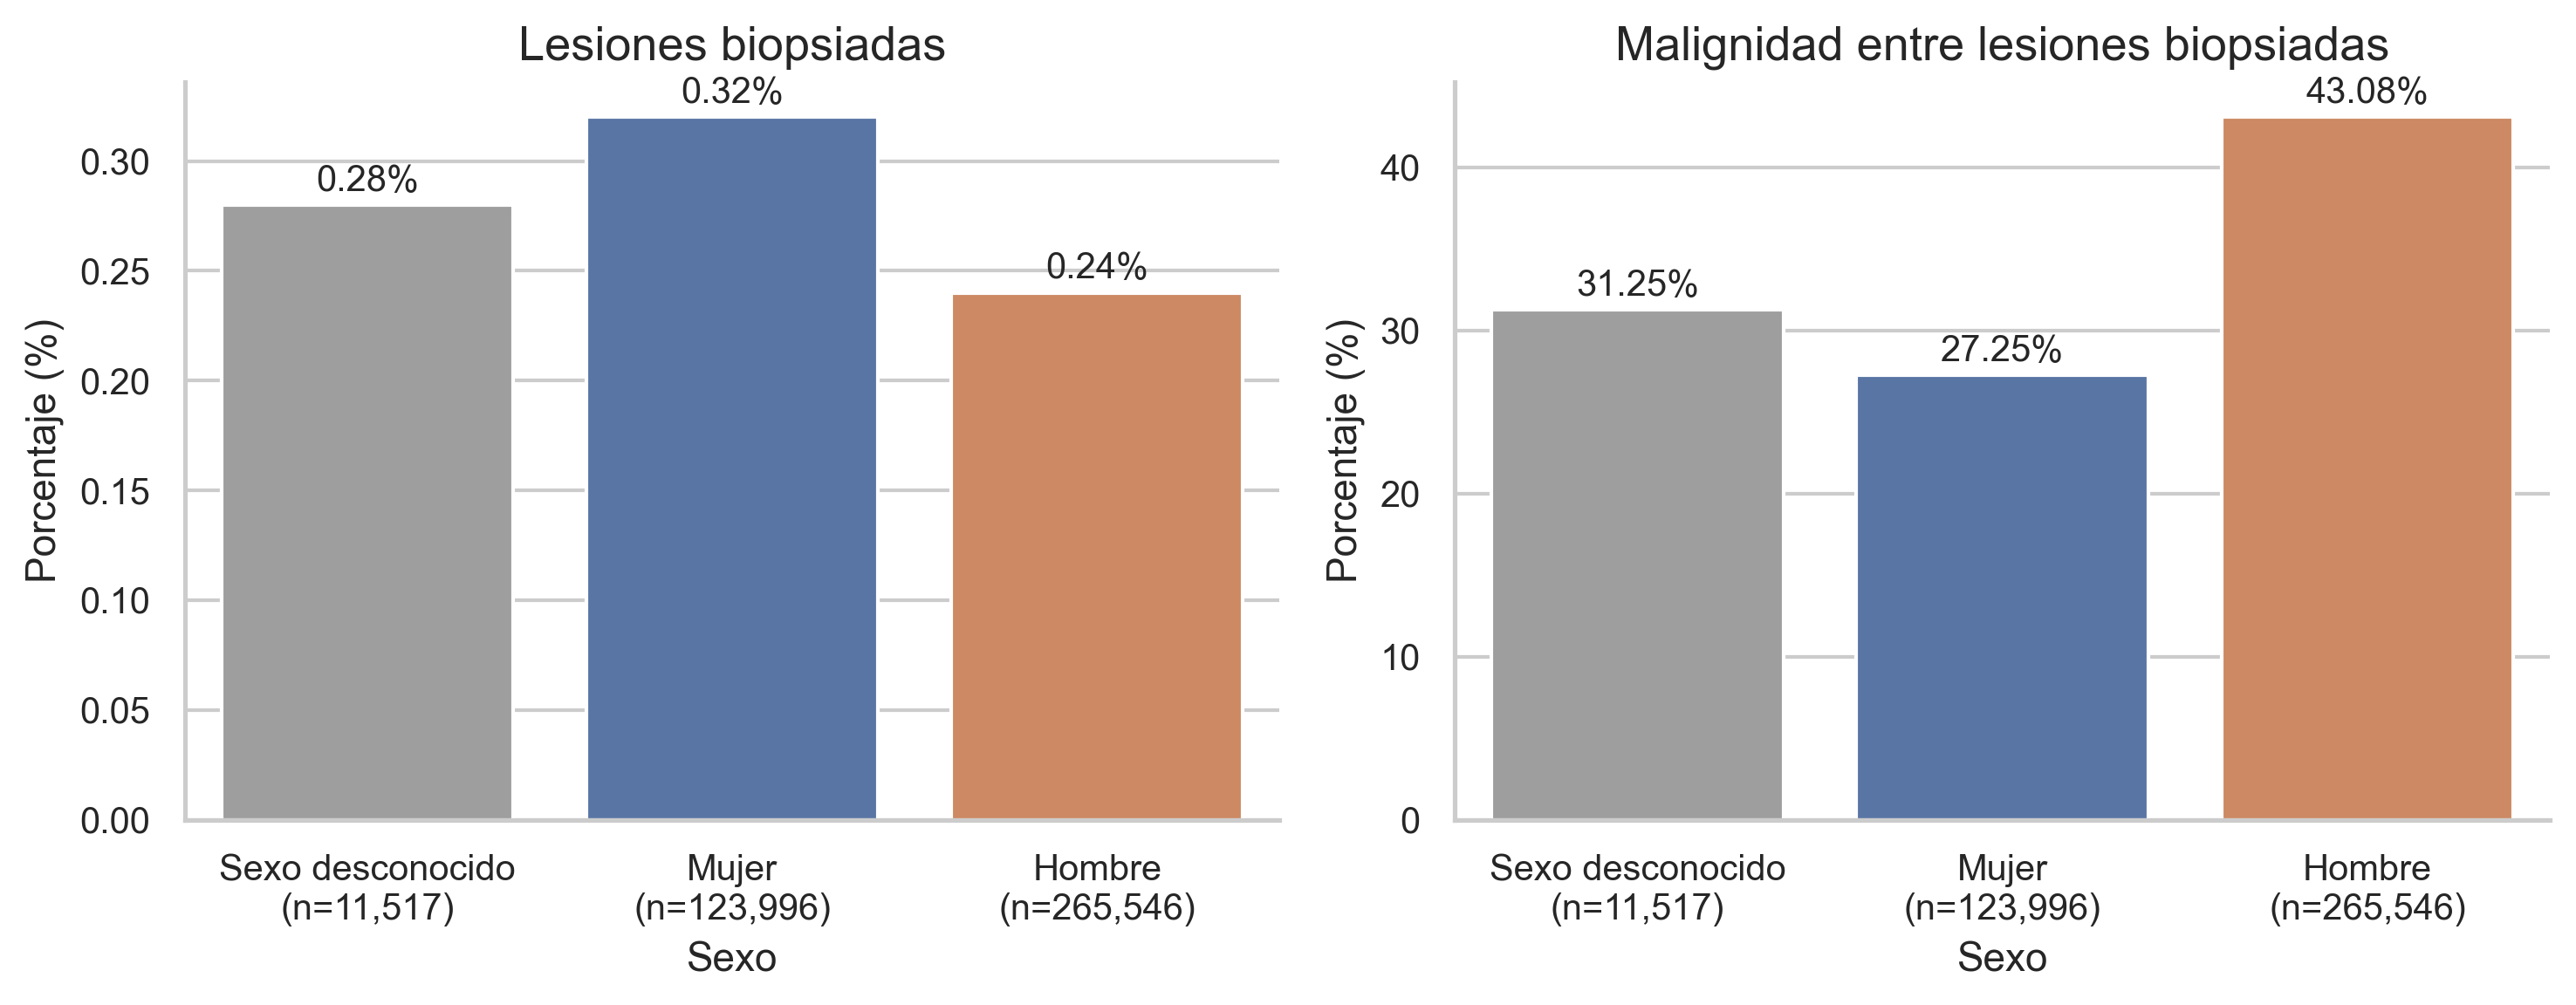

In [79]:
figures["sex_predictive_value"]

Figura XX. Relación entre `sex` y las variables objetivo. El panel izquierdo muestra el porcentaje de lesiones biopsiadas en cada categoría de sexo y el panel derecho la proporción de malignidad entre las lesiones biopsiadas. Las etiquetas superiores indican los porcentajes observados y el tamaño total de cada grupo aparece bajo las categorías.

Para evaluar la asociación entre `sex` y las variables objetivo se emplean dos métricas complementarias. En primer lugar, se utiliza el test χ² de independencia para determinar si existe evidencia estadística de asociación entre las variables. Sin embargo, dado el elevado tamaño muestral disponible, pequeñas diferencias pueden resultar estadísticamente significativas aun careciendo de relevancia práctica. Por este motivo, la interpretación principal se basa en la V de Cramér, una medida de tamaño del efecto comprendida entre 0 y 1, donde valores próximos a 0 indican ausencia de asociación y valores crecientes reflejan asociaciones progresivamente más fuertes.

La asociación entre `sex` y la decisión de biopsiar una lesión resulta estadísticamente significativa, pero presenta una magnitud prácticamente nula (V de Cramér = 0.0074). Las proporciones de lesiones biopsiadas son muy similares entre mujeres (0.32%) y hombres (0.24%), lo que sugiere que el sexo aporta escasa información para discriminar entre lesiones biopsiadas y no biopsiadas.

Por el contrario, entre las lesiones ya biopsiadas se observa una asociación más marcada con la malignidad (V de Cramér = 0.1587). Las lesiones biopsiadas de pacientes masculinos presentan una proporción de malignidad sustancialmente superior a la observada en pacientes femeninos (43.08% frente a 27.25%), lo que sugiere que `sex` podría aportar información útil en modelos orientados a diferenciar lesiones malignas y no malignas.

Desde un punto de vista clínico, la literatura médica describe diferencias relevantes entre hombres y mujeres en la distribución anatómica de las lesiones cutáneas y de los tumores malignos. Por este motivo, aunque la asociación directa observada con algunas variables objetivo sea limitada, sex podría aportar información complementaria cuando se analiza conjuntamente con la localización de la lesión.

Respecto a los valores missing, estos afectan a 11,517 lesiones (2.87%) correspondientes a 33 pacientes (3.17%). La ausencia de información es completamente consistente a nivel de paciente: todos los pacientes afectados presentan la variable `sex` ausente en la totalidad de sus lesiones.

La distribución de los valores missing no es homogénea entre centros, sino que se concentra principalmente en el University Hospital of Basel y, en menor medida, en el Frazer Institute. Este patrón sugiere que la ausencia de información está probablemente relacionada con diferencias en los procedimientos de recogida, integración o anonimización de datos, más que con características clínicas propias de los pacientes o de las lesiones. Además, los pacientes con `sex` missing no presentan diferencias clínicamente relevantes en edad ni en distribución diagnóstica respecto al resto de la cohorte.

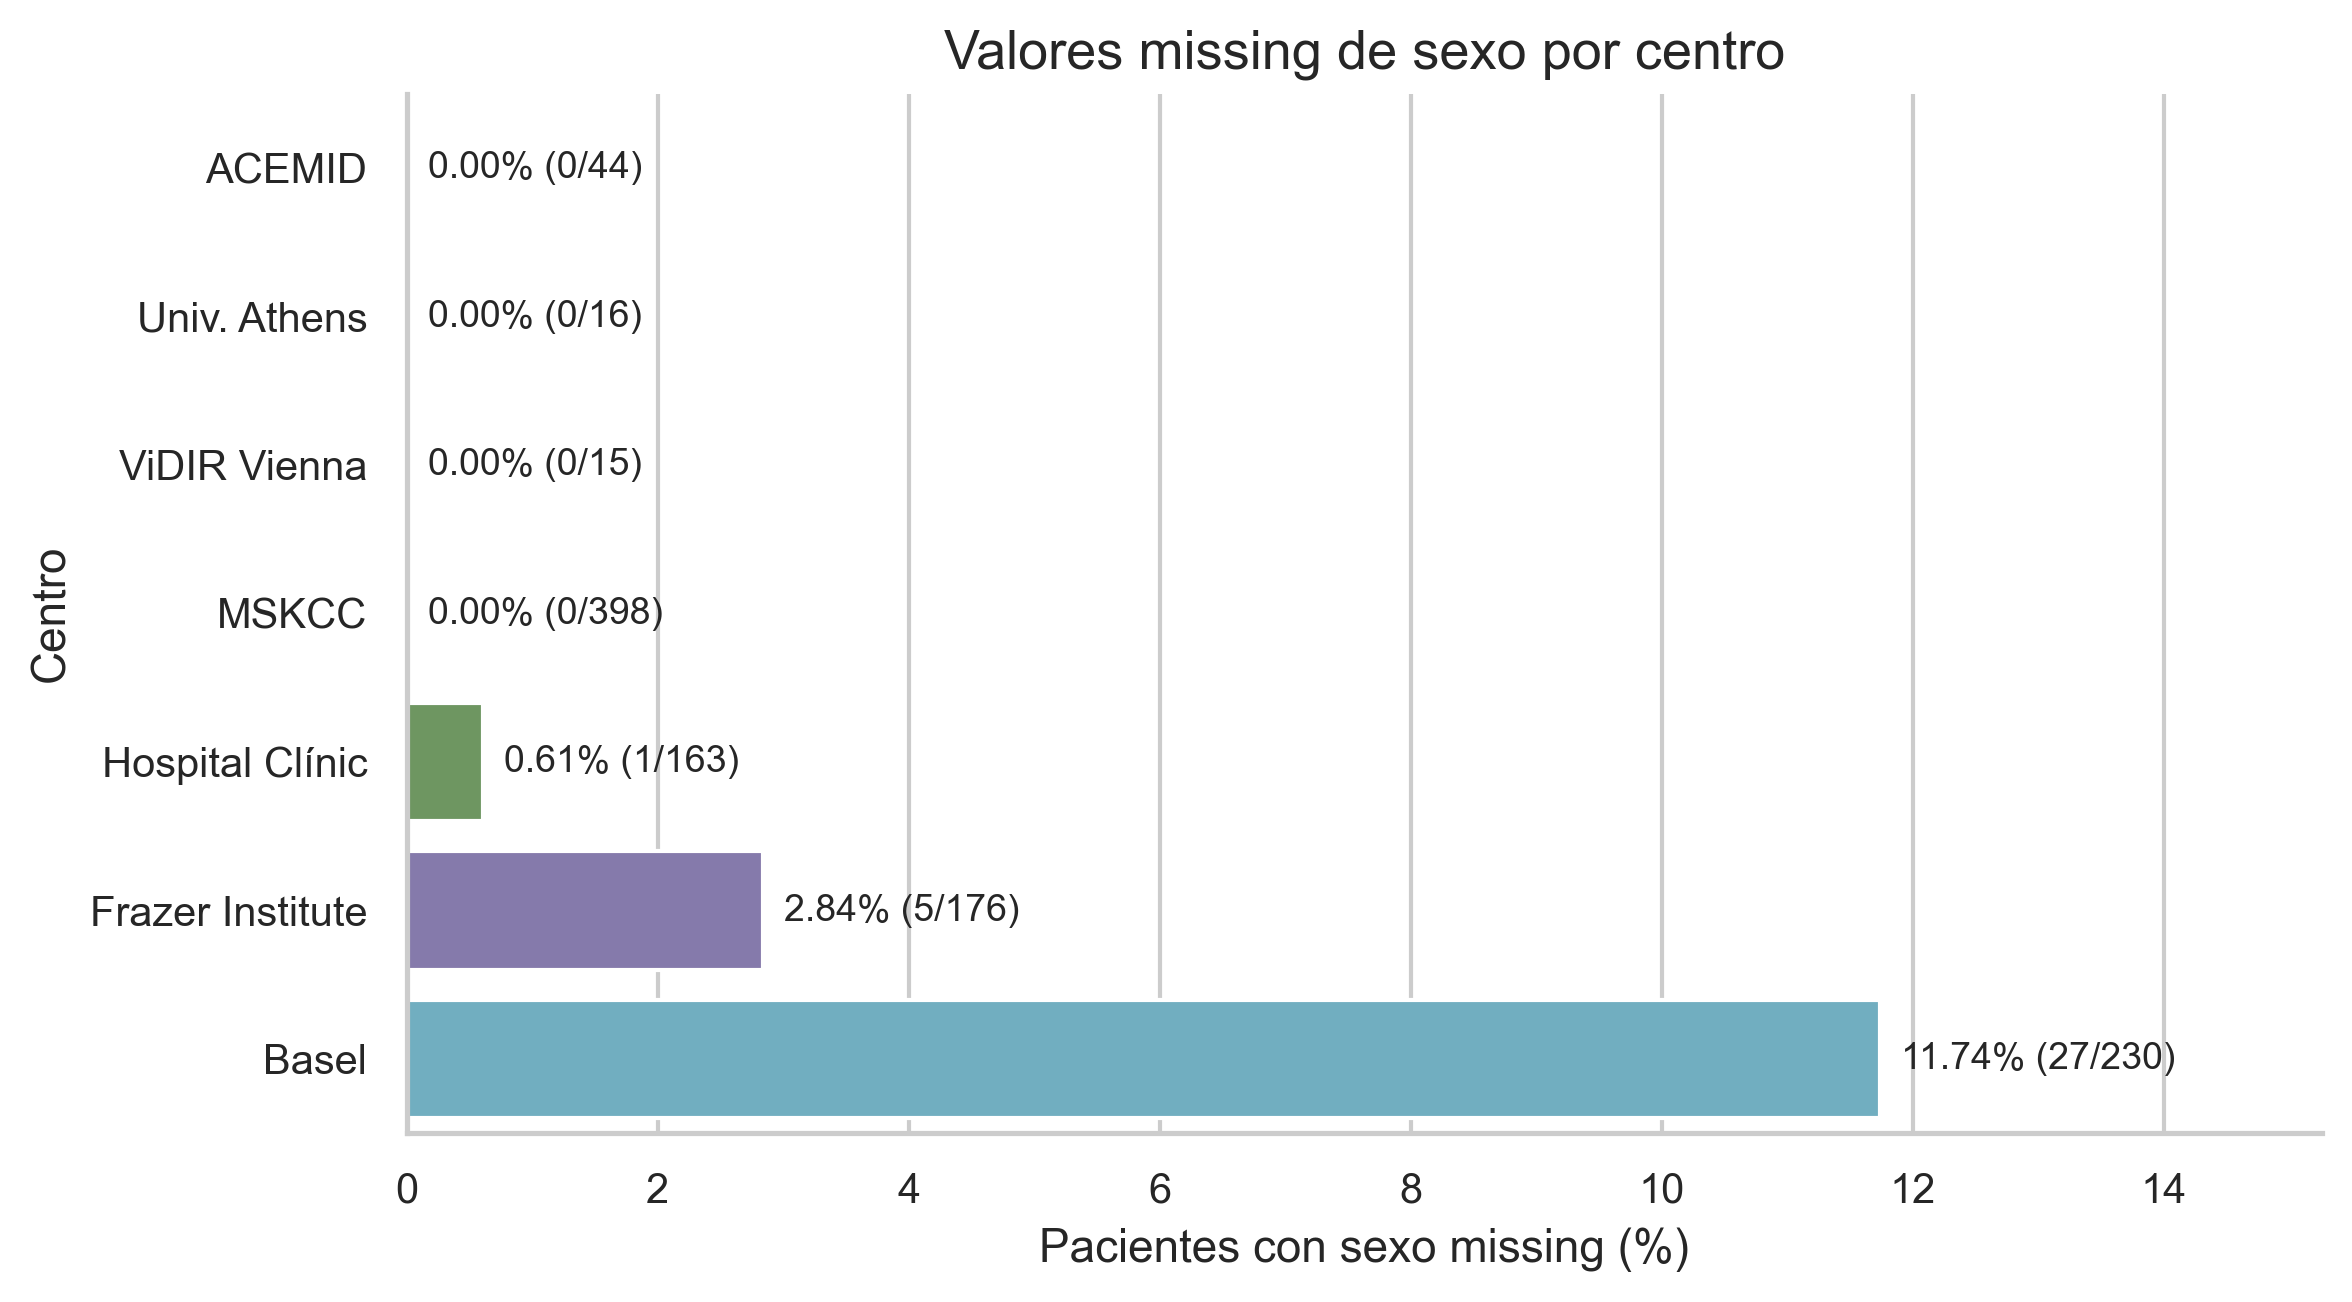

In [76]:
figures["sex_missing_attribution"]

Figura XX. Distribución de los pacientes con valores missing en `sex` según el centro de procedencia. Las etiquetas muestran el porcentaje de pacientes afectados y, entre paréntesis, el número de pacientes con `sex` missing respecto al total de pacientes de cada centro.

En conjunto, la evidencia disponible sugiere que el mecanismo de ausencia es más compatible con un patrón Missing At Random (MAR) asociado al centro de procedencia (`attribution`) que con un mecanismo Missing Not At Random (MNAR). Bajo esta hipótesis, tanto la imputación como la eliminación de los pacientes afectados podrían considerarse estrategias de preprocesamiento. Sin embargo, dado el reducido porcentaje de valores missing, la ausencia de evidencias de sesgos clínicamente relevantes y el impacto potencialmente limitado de una imputación basada en un número reducido de variables disponibles, la eliminación de estos pacientes constituye una alternativa simple, siempre que no altere de forma apreciable la composición clínica del conjunto de datos.

Para evaluar el impacto potencial de esta decisión se compara la distribución global del dataset antes y después de eliminar los pacientes con valores missing en `sex`.

| Escenario                                  | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ------------------------------------------ | ------------: | ------------: | -----------: | -----------: |
| Dataset original                           |         1,042 |        100.00 |      401,059 |       100.00 |
| Tras eliminar pacientes con `sex` missing  |         1,009 |         96.83 |      389,542 |        97.13 |
| Registros eliminados                       |            33 |          3.17 |       11,517 |         2.87 |

Tabla XX. Impacto sobre el tamaño de la cohorte tras excluir los pacientes con valores missing en `sex`.

| Categoría diagnóstica  | Antes (%) | Después (%) | Diferencia (pp) |
| ---------------------- | --------: | ----------: | --------------: |
| Benign non-biopsied    |   99.7337 |     99.7340 |         +0.0003 |
| Benign biopsied        |    0.1399 |      0.1397 |         -0.0002 |
| Indeterminate biopsied |    0.0284 |      0.0280 |         -0.0004 |
| Malignant biopsied     |    0.0980 |      0.0983 |         +0.0003 |

*Tabla XX. Distribución de las categorías diagnósticas antes y después de excluir los pacientes con valores missing en `sex`. La diferencia se expresa en puntos porcentuales.

Los cambios observados son inferiores a 0.0005 puntos porcentuales en todas las categorías diagnósticas analizadas, sin modificar de forma apreciable la composición clínica del conjunto de datos ni el grado de desbalanceo de las categorías de la variable objetivo. En consecuencia, se recomienda eliminar estos pacientes antes del entrenamiento de los modelos. Dado el reducido número de pacientes afectados y el impacto prácticamente nulo de su exclusión sobre la composición del conjunto de datos, esta estrategia evita introducir complejidad adicional mediante procedimientos de imputación, simplifica el tratamiento posterior de la variable y evita la creación de una categoría artificial (Unknown) con escasa representación y valor predictivo incierto.

Los pacientes a eliminar serían:

`IP_3371534`, `IP_6187331`, `IP_9472195`, `IP_2914511`, `IP_5044083`, `IP_6207479`, `IP_6975913`, `IP_1241473`, `IP_5887935`, `IP_8810058`, `IP_8999199`, `IP_6732258`, `IP_6413837`, `IP_1474479`, `IP_0797650`, `IP_2148283`, `IP_4579352`, `IP_7563441`, `IP_1715157`, `IP_1016097`, `IP_7703522`, `IP_4080836`, `IP_8377208`, `IP_1822913`, `IP_6193088`, `IP_0473747`, `IP_1433033`, `IP_6709102`, `IP_8036435`, `IP_2075317`, `IP_7858959`, `IP_9550509` e `IP_5373245`.

Finalmente, se recomienda codificarla mediante una representación binaria (`0/1`) para facilitar su utilización en los modelos de machine learning posteriores.

## Variable 'age_approx'

La variable `age_approx` representa la edad aproximada del paciente en el momento de adquisición de la imagen. Es una variable cuantitativa continua por naturaleza, aunque aparece discretizada principalmente en intervalos de cinco años. Está almacenada en formato `float` y registrada a nivel de lesión, pero conceptualmente corresponde a una característica del paciente.

De los 1,042 pacientes, 929 presentan una única edad registrada, 100 presentan dos edades separadas por exactamente cinco años y 13 no disponen de información. Para los análisis descriptivos a nivel de paciente se utiliza el punto medio entre ambas edades cuando existen dos valores. Sin embargo, para el modelado se recomienda conservar la edad original asociada a cada lesión, ya que refleja adquisiciones realizadas en momentos distintos.

| Nivel de análisis | Valores no nulos (n) | Media ± DE (años) | Mediana [IQR] (años) | Rango (años) | Skewness | Kurtosis |
| ----------------- | --------------------: | ----------------: | -------------------: | -----------: | -------: | -------: |
| Lesión            |               398,261 |     58.01 ± 13.60 |           60 [50–70] |         5–85 |    -0.26 |    -0.29 |
| Paciente          |                 1,029 |     52.61 ± 14.92 |           55 [40–65] |         5–85 |    -0.20 |    -0.46 |

Tabla XX. Resumen de la distribución de `age_approx` a nivel de lesión y de paciente. DE: desviación estándar; IQR: rango intercuartílico. La desviación estándar, la skewness y la kurtosis se calcularon utilizando sus estimadores muestrales. Los estadísticos a nivel de paciente utilizan una edad representativa única por individuo; cuando existen dos edades registradas, se emplea el punto medio entre ambas.

La distribución a nivel de paciente se concentra principalmente entre los 40 y los 70 años, con una media de 52.6 años y una mediana de 55 años. Los valores de skewness y kurtosis son próximos a cero, por lo que no se observa una asimetría marcada ni colas extremas que motiven una potencial transformar la variable.

La media a nivel de lesión es superior a la obtenida a nivel de paciente, lo que sugiere que los pacientes de mayor edad aportan, en promedio, un mayor número de imágenes. 

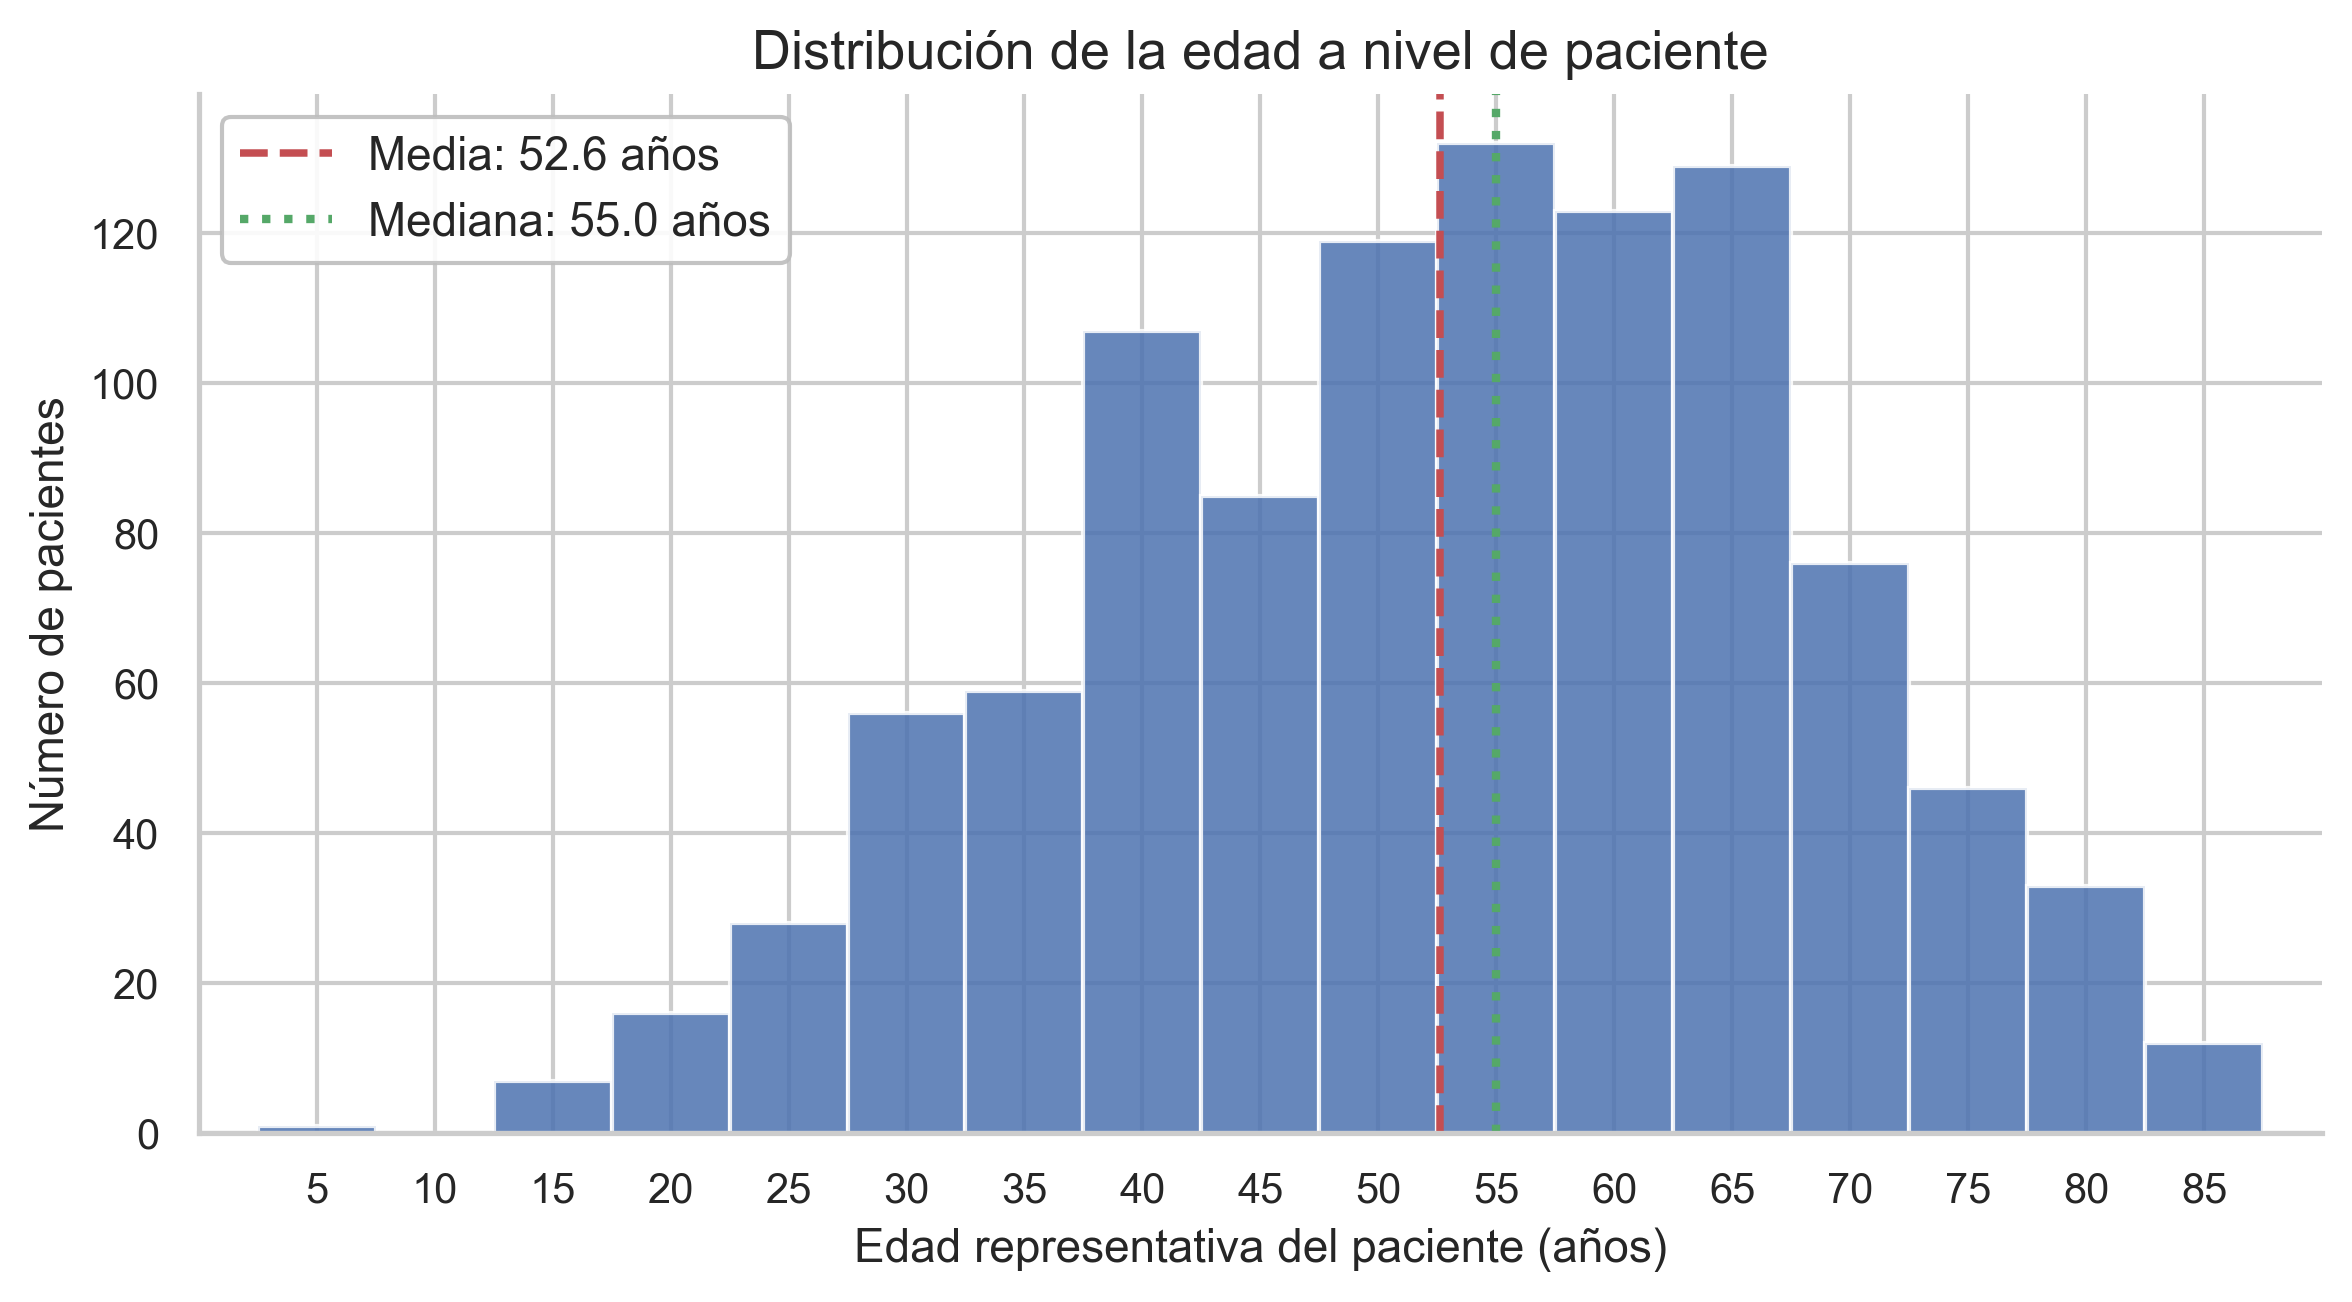

In [99]:
figures["age_distribution_patient_level"]

Figura XX. Histograma de la edad representativa a nivel de paciente. En los pacientes con dos edades registradas se utiliza el punto medio entre ambas. Las líneas verticales indican la media (rojo) y la mediana (evrde) de la distribución.

Las edades de 5 y 15 años se identifican formalmente como valores extremos mediante la regla del IQR aplicada a nivel de lesión. Sin embargo, no son valores biológicamente inverosímiles ni existen indicios de que correspondan a errores de registro. Más bien, reflejan que la población pediátrica está escasamente representada en el conjunto de datos. En total, únicamente ocho pacientes presentan una edad inferior a 18 años:

`IP_1216329`, `IP_1510720`, `IP_3316592`, `IP_3658490`, `IP_3772472`, `IP_3909069`, `IP_5373245` e `IP_8911703`

Estos pacientes aportan 645 lesiones (0.16% del total), de las cuales 644 (99.84%) corresponden a benignas no biopsiadas y una (0.16%) a benigna biopsiada. No se observa ninguna lesión maligna ni indeterminada en este subgrupo. La representación pediátrica es, por tanto, limitada y, además, la epidemiología y el comportamiento de las lesiones cutáneas pueden diferir con la población adulta, así como la acumulación de daño cutáneo y la prevalencia de lesiones aumentan generalmente con la edad. Por este motivo, es razonable excluir estos ocho pacientes y restringir la cohorte a edades de 18 años o más. 

En cuanto a la relación con las variables objetivo, el comportamiento de `age_approx` difiere claramente entre las dos hipótesis de modelado:

| Análisis                            | Mediana grupo negativo (años) | Mediana grupo positivo (años) | Mann–Whitney p | Correlación punto-biserial | Spearman | Interpretación                |
| ----------------------------------- | ----------------------------: | ----------------------------: | -------------: | -------------------------: | -------: | ----------------------------- |
| Edad vs biopsia                     |                            60 |                            55 |         <0.001 |                    -0.0127 |  -0.0117 | Asociación prácticamente nula |
| Edad vs malignidad entre biopsiadas |                            50 |                            60 |         <0.001 |                     0.3653 |   0.3627 | Asociación positiva moderada  |

Tabla XX. Asociación entre `age_approx` y las variables objetivo de las dos hipótesis de modelado. En la primera hipótesis, el grupo negativo corresponde a lesiones benignas no biopsiadas y el positivo a lesiones biopsiadas. En la segunda, el grupo negativo incluye lesiones biopsiadas benignas o indeterminadas y el positivo lesiones biopsiadas malignas.

La comparación entre grupos se realiza mediante la prueba de Mann–Whitney U, ya que la edad está discretizada, contiene numerosos valores repetidos y los tamaños de los grupos son muy diferentes. Aunque ambas comparaciones resultan estadísticamente significativas, el elevado tamaño muestral puede hacer que diferencias pequeñas produzcan valores p muy bajos. Por este motivo, la interpretación se basa principalmente en la magnitud de la asociación.

La correlación punto-biserial evalúa la asociación lineal entre una variable cuantitativa y un target binario, mientras que Spearman permite detectar una relación monotónica sin asumir linealidad. La concordancia entre ambas medidas ayuda a valorar si el patrón observado es consistente y potencialmente relevante desde el punto de vista predictivo.


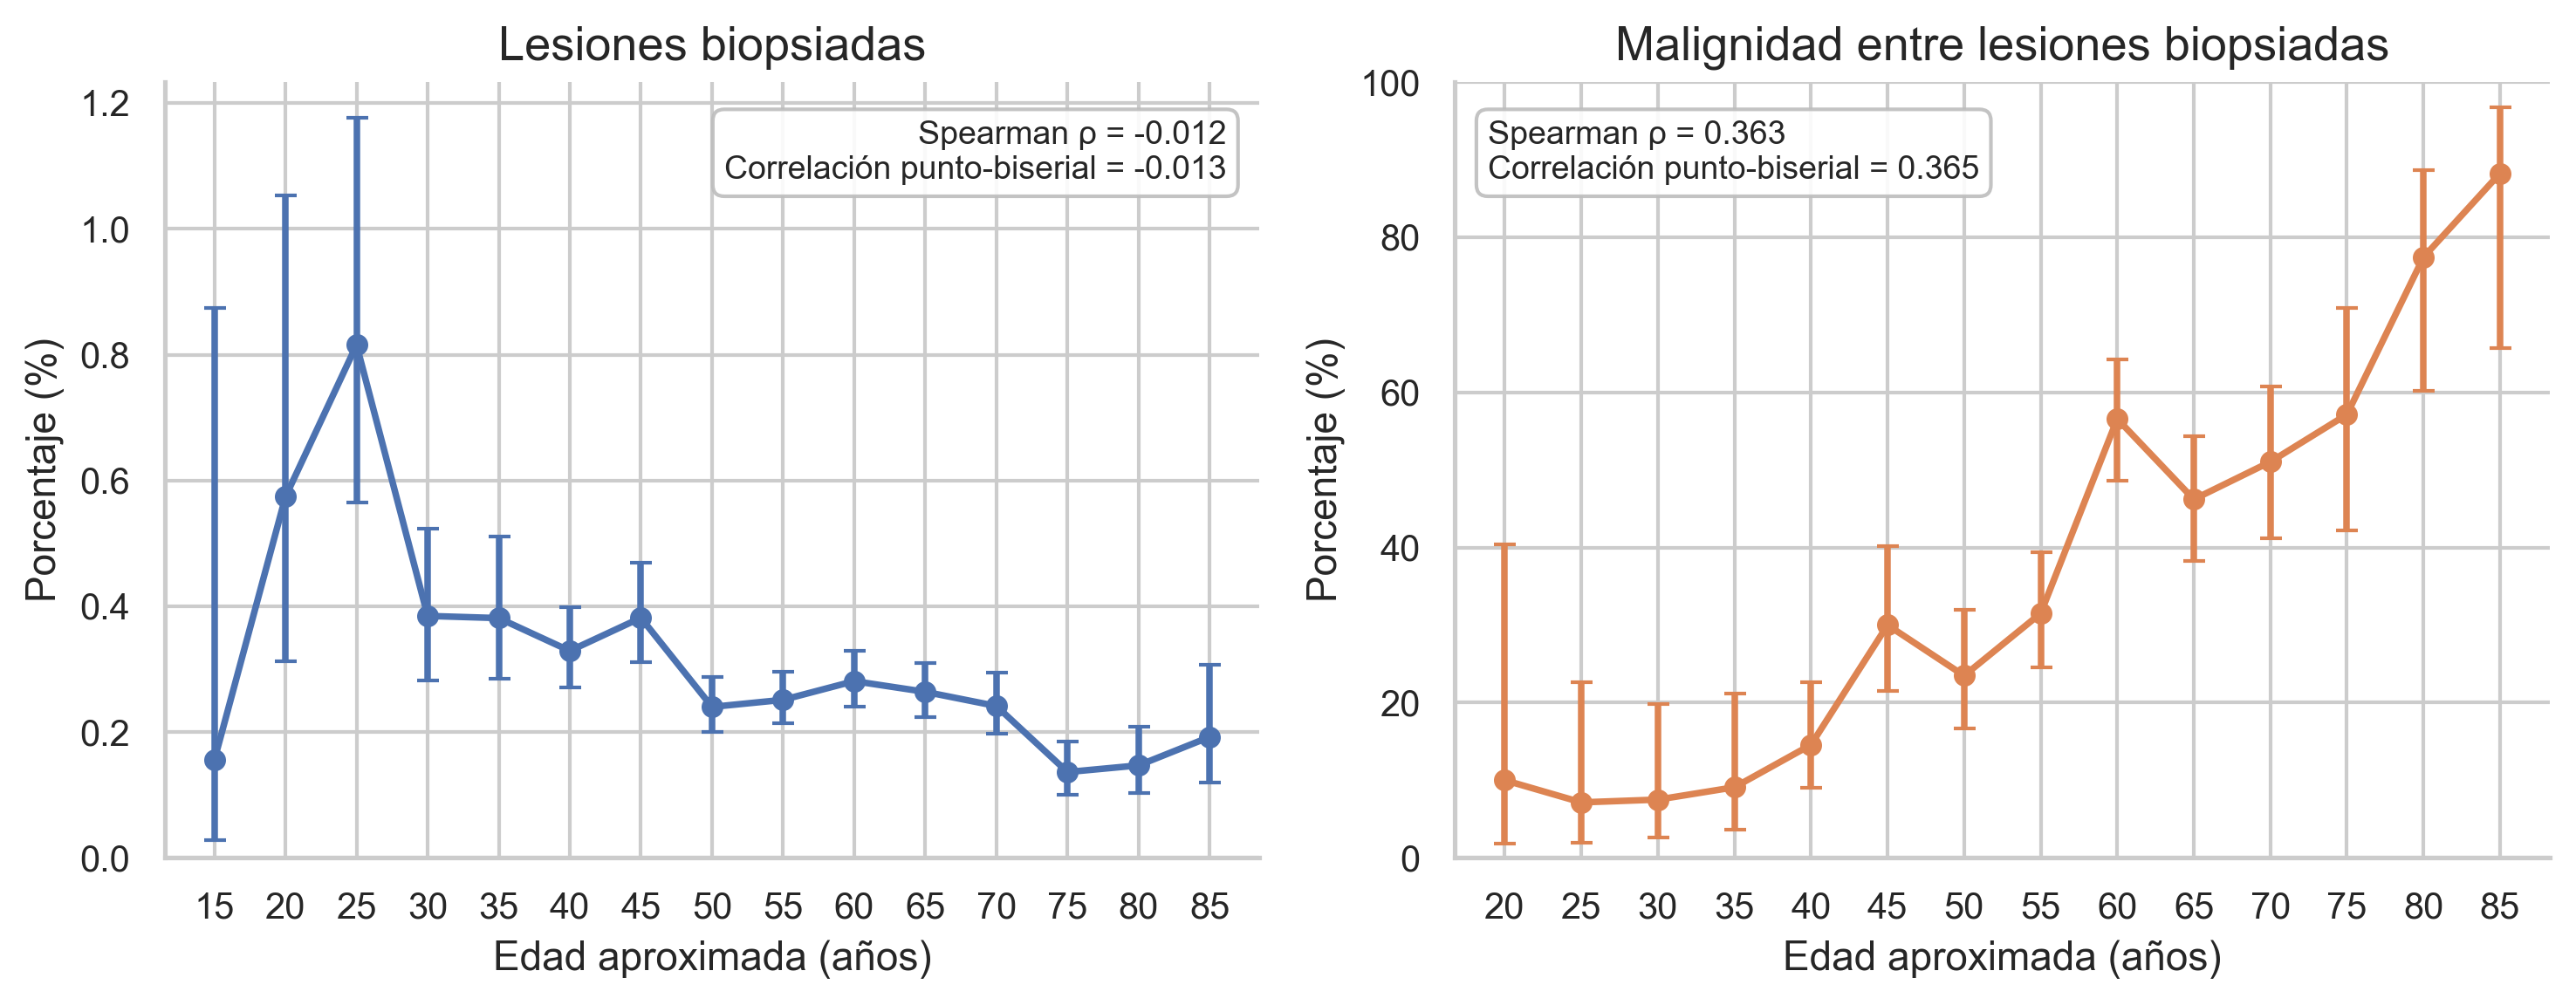

In [87]:
figures["age_predictive_value"]

Figura XX. Relación entre la edad aproximada y las variables objetivo. El panel izquierdo muestra el porcentaje de lesiones biopsiadas por edad y el panel derecho la proporción de malignidad entre las lesiones biopsiadas. Las barras verticales representan los intervalos de confianza del 95% calculados mediante el método de Wilson.

Las lesiones biopsiadas presentan una edad mediana ligeramente inferior, pero la correlación es prácticamente nula y no se observa una tendencia monotónica clara. Las tasas algo superiores en edades jóvenes podrían reflejar que, ante una lesión mínimamente dudosa en un paciente joven, se adopte una actitud más sensible debido al mayor impacto potencial de retrasar un diagnóstico de gravedad. En cambio, entre las lesiones ya biopsiadas se observa un aumento claro de la proporción de malignidad con la edad. Este patrón es clínicamente coherente con la acumulación progresiva de daño cutáneo y con el incremento de la incidencia de lesiones malignas en edades avanzadas. En consecuencia, age_approx parece aportar poco valor predictivo para decidir si una lesión debe ser biopsiada, pero puede constituir una variable relevante para diferenciar lesiones malignas y no malignas dentro de la cohorte biopsiada.

Respecto a los valores missing, estos afectan a 2,798 lesiones (0.70%) correspondientes a 13 pacientes (1.25%). La ausencia de información es completamente consistente a nivel de paciente: todos los pacientes afectados presentan `age_approx` missing en la totalidad de sus lesiones.

La distribución de los valores missing no es homogénea entre centros, sino que se concentra exclusivamente en el Frazer Institute, el Hospital Clínic y el University Hospital of Basel. Este patrón sugiere que la ausencia de información podría estar relacionada con diferencias en los procedimientos de recogida, integración o anonimización de los datos, más que con características clínicas propias de los pacientes o de las lesiones.

Además, las lesiones correspondientes a pacientes con edad missing son casi exclusivamente benignas no biopsiadas, sin observarse una alteración relevante de la distribución diagnóstica respecto al conjunto global. También se detecta un mayor porcentaje de ausencia simultánea de otras variables, aunque este resultado afecta a muy pocos pacientes y debe interpretarse con cautela.

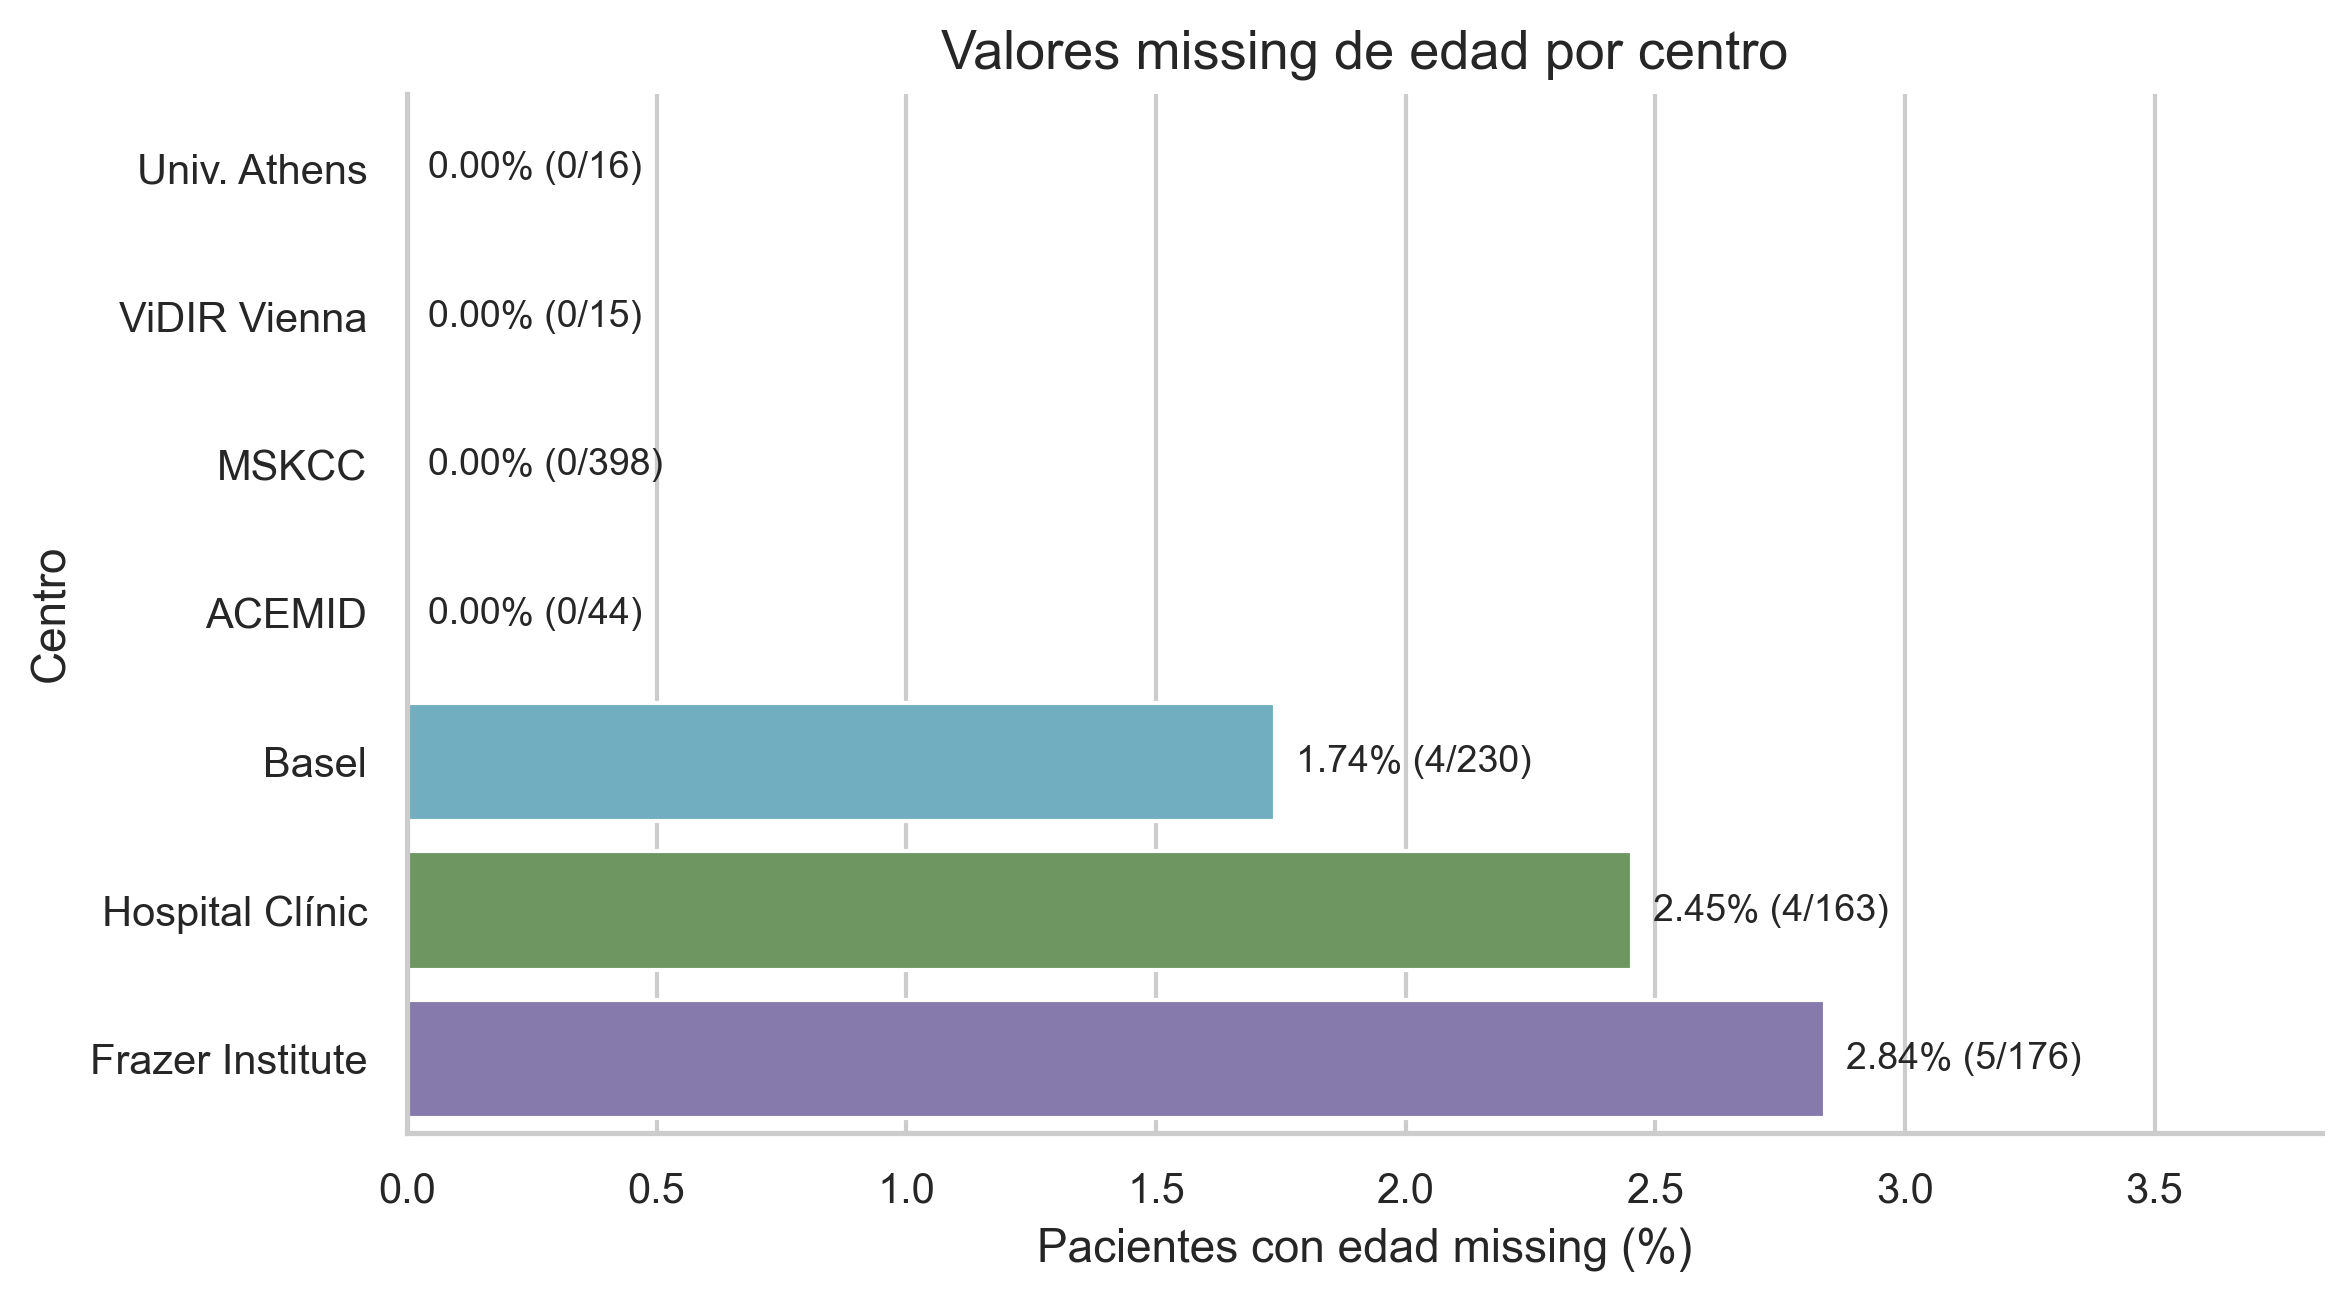

In [86]:
figures["age_missing_attribution"]

Figura XX. Distribución de los pacientes con valores missing en `age_approx` según el centro de procedencia. Las etiquetas muestran el porcentaje de pacientes afectados y, entre paréntesis, el número de pacientes con edad missing respecto al total de pacientes de cada centro.

En conjunto, la evidencia exploratoria no parece compatible con un mecanismo estrictamente Missing Completely At Random (MCAR). El patrón observado es orientativamente más compatible con un mecanismo Missing At Random (MAR) condicionado principalmente por el centro de procedencia (`attribution`) y por la disponibilidad de otros metadatos. No obstante, esta clasificación no puede demostrarse de forma definitiva mediante el análisis exploratorio y tampoco permite descartar completamente un componente MNAR.

Bajo esta hipótesis, tanto la imputación como la eliminación podrían considerarse estrategias de preprocesamiento. Dado el reducido número de pacientes afectados y la limitada información auxiliar disponible, imputar las edades es una opción que añadiría complejidad e incertidumbre con un beneficio previsiblemente escaso.

Por tanto, una estrategia razonable consiste en eliminar los 13 pacientes con edad missing. Los pacientes afectados son:

`IP_0212694`, `IP_0362830`, `IP_1076642`, `IP_1129512`, `IP_3371534`, `IP_3374234`, `IP_3647018`, `IP_6659956`, `IP_6865940`, `IP_7013759`, `IP_7848492`, `IP_7858959` e `IP_9652562`.

Adicionalmente, si el ámbito clínico del modelo se restringe a población adulta, también puede considerarse la exclusión de los ocho pacientes menores de 18 años. Para evaluar conjuntamente el impacto de ambas decisiones, se compara el dataset original con el resultante tras excluir los pacientes con edad missing y los pacientes menores de edad.

| Escenario | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| --- | ---: | ---: | ---: | ---: |
| Dataset original | 1,042 | 100.00 | 401,059 | 100.00 |
| Tras eliminar pacientes con edad missing | 1,029 | 98.75 | 398,261 | 99.30 |
| Tras eliminar además pacientes menores de 18 años | 1,021 | 97.98 | 397,616 | 99.14 |
| Registros eliminados en total | 21 | 2.02 | 3,443 | 0.86 |

Tabla XX. Impacto sobre el tamaño de la cohorte tras excluir los pacientes con edad missing y los pacientes menores de 18 años.

La exclusión conjunta eliminaría 3,438 lesiones `benign_non_biopsied`, una lesión `benign_biopsied`, una lesión `indeterminate_biopsied` y tres lesiones `malignant_biopsied`.

| Categoría diagnóstica | Antes (%) | Después (%) | Diferencia (pp) |
| --- | ---: | ---: | ---: |
| Benign non-biopsied | 99.7337 | 99.7327 | -0.0010 |
| Benign biopsied | 0.1399 | 0.1408 | +0.0010 |
| Indeterminate biopsied | 0.0284 | 0.0284 | -0.0000 |
| Malignant biopsied | 0.0980 | 0.0981 | +0.0001 |

Tabla XX. Distribución de las categorías diagnósticas antes y después de excluir los pacientes con edad missing y los pacientes menores de 18 años. La diferencia se expresa en puntos porcentuales.

Los cambios observados son inferiores a 0.0011 puntos porcentuales en todas las categorías, por lo que la exclusión conjunta no modifica de forma apreciable la composición clínica del conjunto de datos ni el grado de desbalanceo de las variables objetivo.

En consecuencia, se recomienda eliminar los pacientes con `age_approx` missing y excluir adicionalmente a los menores de 18 años si el modelo se define explícitamente para población adulta. Ambas decisiones reducen mínimamente el tamaño de la cohorte, simplifican el preprocesamiento y permiten trabajar con una población más homogénea sin alterar de forma relevante la distribución diagnóstica.

No se consideran necesarias transformaciones específicas de `age_approx` y puede mantenerse en su formato numérico actual. Únicamente deberá estandarizarse o transformarse dentro del pipeline cuando el algoritmo utilizado sea sensible a la escala o requiera modelar relaciones no lineales.

## Variable 'anatom_site_general'

La variable `anatom_site_general` describe la localización anatómica general de cada lesión. Se trata de una variable cualitativa nominal, almacenada en formato `string` y registrada a nivel de lesión. A diferencia de variables como `sex` o `age_approx`, no corresponde a un atributo fijo del paciente, ya que un mismo paciente puede presentar lesiones en múltiples localizaciones anatómicas.

La variable presenta cinco localizaciones anatómicas observadas (`posterior torso`, `lower extremity`, `anterior torso`, `upper extremity` y `head/neck`), además de un pequeño porcentaje de valores missing.

La localización más frecuente fue el torso posterior, con 121,902 lesiones (30.40%), seguida de la extremidad inferior (25.69%), el torso anterior (21.88%) y la extremidad superior (17.59%). Las lesiones localizadas en cabeza/cuello fueron menos frecuentes, representando el 3.00% del conjunto de datos. Los valores missing afectaron a 5,756 lesiones, equivalentes al 1.44% del total.

| Localización anatómica   | Lesiones (n) | Lesiones (%) | Pacientes (n) | Pacientes (%) |
| ------------------------ | -----------: | -----------: | ------------: | ------------: |
| Torso posterior          |      121,902 |        30.40 |         1,015 |         97.41 |
| Extremidad inferior      |      103,028 |        25.69 |         1,014 |         97.31 |
| Torso anterior           |       87,770 |        21.88 |         1,016 |         97.50 |
| Extremidad superior      |       70,557 |        17.59 |         1,016 |         97.50 |
| Cabeza/cuello            |       12,046 |         3.00 |           946 |         90.79 |
| Localización desconocida |        5,756 |         1.44 |             — |             — |

Tabla XX. Distribución de `anatom_site_general` a nivel de lesión y cobertura anatómica a nivel de paciente. El porcentaje de lesiones se calcula respecto al total de lesiones del conjunto de datos. El porcentaje de pacientes indica la proporción de pacientes con al menos una lesión registrada en cada localización anatómica. Las categorías a nivel de paciente no son mutuamente excluyentes, ya que un mismo paciente puede tener lesiones en varias regiones anatómicas. Para la categoría missing no se reporta cobertura a nivel de paciente porque representa ausencia de información anatómica y se analiza por separado.

A nivel de paciente, la cobertura anatómica fue amplia. Más del 97% de los pacientes presentaban al menos una lesión registrada en cada una de las cuatro regiones anatómicas principales: torso anterior, torso posterior, extremidad superior y extremidad inferior. La cobertura en cabeza/cuello también fue elevada, con 946 pacientes (90.79%) con al menos una lesión registrada en esta región.

En relación con las variables objetivo, `anatom_site_general` mostró comportamientos distintos según la hipótesis de modelado considerada.

| Localización anatómica   | Lesiones (n) | Lesiones biopsiadas (n) | Lesiones biopsiadas (%) | Lesiones malignas (n) | % malignas entre biopsiadas |
| ------------------------ | -----------: | ----------------------: | ----------------------: | --------------------: | --------------------------: |
| Torso posterior          |      121,902 |                     351 |                    0.29 |                   103 |                       29.34 |
| Extremidad inferior      |      103,028 |                     203 |                    0.20 |                    73 |                       35.96 |
| Torso anterior           |       87,770 |                     226 |                    0.26 |                    82 |                       36.28 |
| Extremidad superior      |       70,557 |                     161 |                    0.23 |                    57 |                       35.40 |
| Cabeza/cuello            |       12,046 |                     121 |                    1.00 |                    78 |                       64.46 |
| Localización desconocida |        5,756 |                       6 |                    0.10 |                     0 |                        0.00 |

Tabla XX. Relación entre `anatom_site_general` y las variables objetivo de las dos hipótesis de modelado. El porcentaje de lesiones biopsiadas se calcula respecto al total de lesiones de cada localización anatómica. El porcentaje de malignidad se calcula únicamente entre las lesiones biopsiadas de cada localización.

figures["anatom_site_predictive_value"]

Figura XX. Relación entre `anatom_site_general` y las variables objetivo. El panel izquierdo muestra el porcentaje de lesiones biopsiadas en cada localización anatómica y el panel derecho muestra la proporción de malignidad entre las lesiones biopsiadas.

Para evaluar la asociación entre `anatom_site_general` y las variables objetivo se emplearon dos métricas complementarias. En primer lugar, se utilizó el test χ² de independencia para valorar si existía evidencia estadística de asociación entre variables categóricas. Sin embargo, dado el elevado tamaño muestral disponible, pequeñas diferencias pueden resultar estadísticamente significativas aun teniendo escasa relevancia práctica. Por este motivo, la interpretación principal se basó en la V de Cramér, que cuantifica la magnitud de la asociación en una escala entre 0 y 1.

| Análisis                                                           | p-value χ² | V de Cramér | Interpretación       |
| ------------------------------------------------------------------ | ---------: | ----------: | -------------------- |
| Localización anatómica vs biopsia                                  | 6.1434e-58 |      0.0263 | Asociación muy débil |
| Localización anatómica vs malignidad en lesiones biopsiadas        | 5.6090e-10 |      0.2205 | Asociación moderada  |
| Sexo + localización anatómica vs biopsia                           | 4.3018e-63 |      0.0288 | Asociación muy débil |
| Sexo + localización anatómica vs malignidad en lesiones biopsiadas | 2.0612e-11 |      0.2594 | Asociación moderada  |

Tabla XX. Asociación entre `anatom_site_general`, la variable combinada `sex` + `anatom_site_general` y las variables objetivo de las dos hipótesis de modelado. El test χ² evalúa la independencia entre variables categóricas, mientras que la V de Cramér cuantifica la magnitud de la asociación. Dado el elevado tamaño muestral, la interpretación principal se basa en el tamaño del efecto y no únicamente en el valor p.

La asociación entre localización anatómica y decisión de biopsiar una lesión fue estadísticamente significativa, pero de magnitud muy baja (V de Cramér = 0.0263). Las tasas de biopsia fueron reducidas en todas las localizaciones, con valores entre 0.20% y 0.29% en las regiones principales. La excepción fue cabeza/cuello, donde el porcentaje de lesiones biopsiadas alcanzó el 1.00%. Aunque esto sugiere una mayor probabilidad de biopsia en esta localización, el tamaño global del efecto indica que la variable aporta poca capacidad discriminativa para el modelo de recomendación de biopsia.

Por el contrario, entre las lesiones biopsiadas, `anatom_site_general` mostró una asociación más relevante con la malignidad (V de Cramér = 0.2205). La región de cabeza/cuello presentó la mayor proporción de malignidad, con 78 lesiones malignas entre 121 lesiones biopsiadas (64.46%). El resto de localizaciones mostró proporciones más bajas y relativamente similares, situadas entre el 29.34% y el 36.28%.

Dado que la literatura clínica describe diferencias relevantes en la distribución anatómica de los tumores cutáneos según el sexo, se realizó un análisis complementario combinando `sex` y `anatom_site_general`.

| Sexo   | Localización anatómica | Lesiones (n) | Lesiones biopsiadas (n) | Lesiones biopsiadas (%) | Lesiones malignas (n) | % malignas entre biopsiadas |
| ------ | ---------------------- | -----------: | ----------------------: | ----------------------: | --------------------: | --------------------------: |
| Mujer  | Torso posterior        |       33,292 |                     130 |                    0.39 |                    32 |                       24.62 |
| Mujer  | Extremidad inferior    |       37,617 |                     109 |                    0.29 |                    31 |                       28.44 |
| Mujer  | Torso anterior         |       24,042 |                      68 |                    0.28 |                    21 |                       30.88 |
| Mujer  | Extremidad superior    |       24,631 |                      64 |                    0.26 |                    14 |                       21.88 |
| Mujer  | Cabeza/cuello          |        3,140 |                      26 |                    0.83 |                    11 |                       42.31 |
| Hombre | Torso posterior        |       85,052 |                     206 |                    0.24 |                    69 |                       33.50 |
| Hombre | Extremidad inferior    |       62,129 |                      92 |                    0.15 |                    41 |                       44.57 |
| Hombre | Torso anterior         |       61,461 |                     152 |                    0.25 |                    59 |                       38.82 |
| Hombre | Extremidad superior    |       43,815 |                      89 |                    0.20 |                    39 |                       43.82 |
| Hombre | Cabeza/cuello          |        8,615 |                      94 |                    1.09 |                    66 |                       70.21 |

Tabla XX. Relación entre la variable combinada `sex` + `anatom_site_general` y las dos variables objetivo. Los valores missing en `sex` o `anatom_site_general` se excluyeron de este análisis para trabajar únicamente con grupos interpretables.

figures["sex_anatom_site_predictive_value"]

Figura XX. Relación entre la combinación de `sex` y `anatom_site_general` y las variables objetivo. El panel izquierdo muestra el porcentaje de lesiones biopsiadas por sexo y localización anatómica. El panel derecho muestra la proporción de malignidad entre las lesiones biopsiadas.

La variable combinada `sex` + `anatom_site_general` mostró una asociación muy débil con el estado de biopsia (V de Cramér = 0.0288), muy similar a la observada para la localización anatómica aislada. Por tanto, esta combinación no parece aportar valor discriminativo relevante para el modelo de recomendación de biopsia.

En cambio, la asociación con malignidad entre lesiones biopsiadas fue algo mayor que la observada con `anatom_site_general` por separado (V de Cramér = 0.2594 frente a 0.2205). Esto sugiere que `sex` puede aportar información complementaria cuando se combina con la localización anatómica, especialmente para la hipótesis secundaria de clasificación de malignidad.

El grupo con mayor proporción de malignidad fue el de hombres con lesiones en cabeza/cuello, donde 66 de 94 lesiones biopsiadas fueron malignas (70.21%). En hombres también se observaron proporciones relativamente elevadas en extremidad inferior (44.57%) y extremidad superior (43.82%). En mujeres, la localización con mayor proporción de malignidad también fue cabeza/cuello (42.31%), aunque esta estimación se basa en solo 26 lesiones biopsiadas y debe interpretarse con cautela.

Respecto a los valores missing, estos afectaron a 5,756 lesiones (1.44%) correspondientes a 35 pacientes (3.36%). Se identificaron 11 pacientes con localización anatómica missing en todas sus lesiones, que aportaban 2,188 lesiones, y 24 pacientes con missing parcial, que aportaban 3,568 lesiones con localización anatómica missing.

Entre los pacientes con missing parcial, el patrón fue heterogéneo. En la mayoría de casos, el missing afectaba solo a una o dos lesiones. Sin embargo, cinco pacientes presentaban un patrón casi completo, con más del 97% de sus lesiones sin localización anatómica. Por tanto, el grupo de missing parcial incluye tanto casos aislados a nivel de lesión como situaciones cercanas a un missing sistemático a nivel de paciente.

La distribución de los valores missing no fue homogénea entre centros. Los pacientes afectados procedían principalmente de University Hospital of Basel, Memorial Sloan Kettering Cancer Center y Frazer Institute. Este patrón sugiere que la ausencia de información está probablemente relacionada con diferencias en los procedimientos de recogida, integración o codificación de metadatos, más que con características clínicas de las lesiones.

figures["anatom_site_missing_attribution"]

Figura XX. Distribución de los pacientes con valores missing en `anatom_site_general` según el centro de procedencia. Las etiquetas muestran el porcentaje de pacientes afectados y, entre paréntesis, el número de pacientes con missing respecto al total de pacientes de cada centro.

Las lesiones con localización anatómica missing estaban casi exclusivamente concentradas en lesiones benignas no biopsiadas. De las 5,756 lesiones con missing en `anatom_site_general`, 5,750 (99.90%) correspondían a lesiones benignas no biopsiadas y solo 6 (0.10%) a lesiones benignas biopsiadas. No se observaron lesiones indeterminadas ni malignas con localización anatómica missing.

El impacto potencial de excluir todos los pacientes con missing en localización anatómica también fue evaluado. Esta estrategia eliminaría 35 pacientes y 20,733 lesiones, reduciendo el dataset de 1,042 a 1,007 pacientes y de 401,059 a 380,326 lesiones. Esto equivale a excluir el 3.36% de los pacientes y el 5.17% de las lesiones.

| Escenario                                                  | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ---------------------------------------------------------- | ------------: | ------------: | -----------: | -----------: |
| Dataset original                                           |         1,042 |        100.00 |      401,059 |       100.00 |
| Tras eliminar pacientes con localización anatómica missing |         1,007 |         96.64 |      380,326 |        94.83 |
| Registros eliminados                                       |            35 |          3.36 |       20,733 |         5.17 |

Tabla XX. Impacto sobre el tamaño de la cohorte tras excluir los pacientes con valores missing en `anatom_site_general`.

La composición diagnóstica del conjunto de datos apenas se modificó tras eliminar estos pacientes. Las diferencias fueron inferiores a 0.003 puntos porcentuales en todas las categorías diagnósticas, por lo que esta exclusión no alteraría de forma apreciable la composición clínica ni el grado de desbalanceo de las variables objetivo.

| Grupo diagnóstico      | Antes (%) | Después (%) | Diferencia (pp) |
| ---------------------- | --------: | ----------: | --------------: |
| benign_non_biopsied    |   99.7337 |     99.7321 |         -0.0016 |
| benign_biopsied        |    0.1399 |      0.1401 |         +0.0003 |
| malignant_biopsied     |    0.0980 |      0.1002 |         +0.0022 |
| indeterminate_biopsied |    0.0284 |      0.0276 |         -0.0008 |

Tabla XX. Distribución de las categorías diagnósticas antes y después de excluir los pacientes con valores missing en `anatom_site_general`.

Se exploró la posibilidad de imputar los valores missing de `anatom_site_general` utilizando las variables auxiliares `tbp_lv_location` y `tbp_lv_location_simple`. Sin embargo, todas las lesiones con `anatom_site_general` missing presentaban `tbp_lv_location = Unknown` y `tbp_lv_location_simple = Unknown`. Por tanto, estas variables no aportan información útil para una imputación determinista.

En conjunto, la evidencia disponible sugiere que el mecanismo de ausencia de `anatom_site_general` es más compatible con un patrón Missing At Random (MAR) que con un mecanismo Missing Not At Random (MNAR). Los valores missing se concentran en determinados centros y patrones de paciente, y están casi exclusivamente restringidos a lesiones benignas no biopsiadas. Este patrón sugiere que la ausencia de localización anatómica está probablemente relacionada con diferencias en los procedimientos de recogida, integración o codificación de metadatos, más que con características clínicas de mayor gravedad.

No obstante, a diferencia de `sex` o `age_approx`, `anatom_site_general` es una variable definida a nivel de lesión. Por ello, la eliminación completa de todos los pacientes afectados sería posible y tendría un impacto mínimo sobre la composición diagnóstica, pero podría resultar más conservadora de lo necesario. Dado que las variables auxiliares de localización no permiten imputación determinista, las principales opciones de preprocesamiento son: tratar los valores missing como una categoría específica, eliminar únicamente las lesiones con localización missing, o eliminar los pacientes afectados.

Desde el punto de vista del modelado, `anatom_site_general` debe conservarse como predictor categórico. Aunque aporta poca información para la hipótesis de recomendación de biopsia, muestra una asociación más relevante con la malignidad entre lesiones biopsiadas, especialmente por la mayor proporción de malignidad observada en cabeza/cuello. Además, la combinación con `sex` incrementa moderadamente la asociación con malignidad, por lo que puede ser útil considerar esta interacción durante la fase de ingeniería de variables.


## Variable 'clin_size_long_diam_mm'

La variable `clin_size_long_diam_mm` representa el diámetro máximo aproximado de la lesión en milímetros. Se trata de una variable cuantitativa continua, almacenada en formato `float`, registrada directamente a nivel de lesión y sin valores missing. En el conjunto de datos se observan 401,059 lesiones, con valores comprendidos entre 1.00 y 28.40 mm.

| Representación |       n | Media |    DE | Mediana |    Q1 |    Q3 |   IQR | Mínimo | Máximo | Skewness | Kurtosis |
| -------------- | ------: | ----: | ----: | ------: | ----: | ----: | ----: | -----: | -----: | -------: | -------: |
| Original (mm)  | 401,059 | 3.931 | 1.743 |   3.370 | 2.840 | 4.380 | 1.540 |  1.000 | 28.400 |    2.832 |   12.529 |
| `log1p`        | 401,059 | 1.551 | 0.280 |   1.475 | 1.345 | 1.683 | 0.337 |  0.693 |  3.381 |    1.382 |    2.414 |

Tabla XX. Distribución de `clin_size_long_diam_mm` en su escala original y tras aplicar una transformación `log1p`. En la representación original, las medidas de tendencia central, dispersión y rango se expresan en milímetros. En la representación transformada, los valores corresponden a `log(1 + diámetro)` y no conservan una interpretación directa en milímetros. DE: desviación estándar; IQR: rango intercuartílico. La desviación estándar, la *skewness* y la *kurtosis* se calcularon mediante sus estimadores muestrales.

La distribución original es claramente asimétrica a la derecha, con una elevada concentración de lesiones pequeñas y una cola prolongada hacia tamaños superiores. La media es mayor que la mediana y los valores de *skewness* y *kurtosis* confirman una distribución marcadamente asimétrica y leptocúrtica. La transformación `log1p` reduce de forma importante ambas medidas, aunque la distribución continúa siendo moderadamente asimétrica.

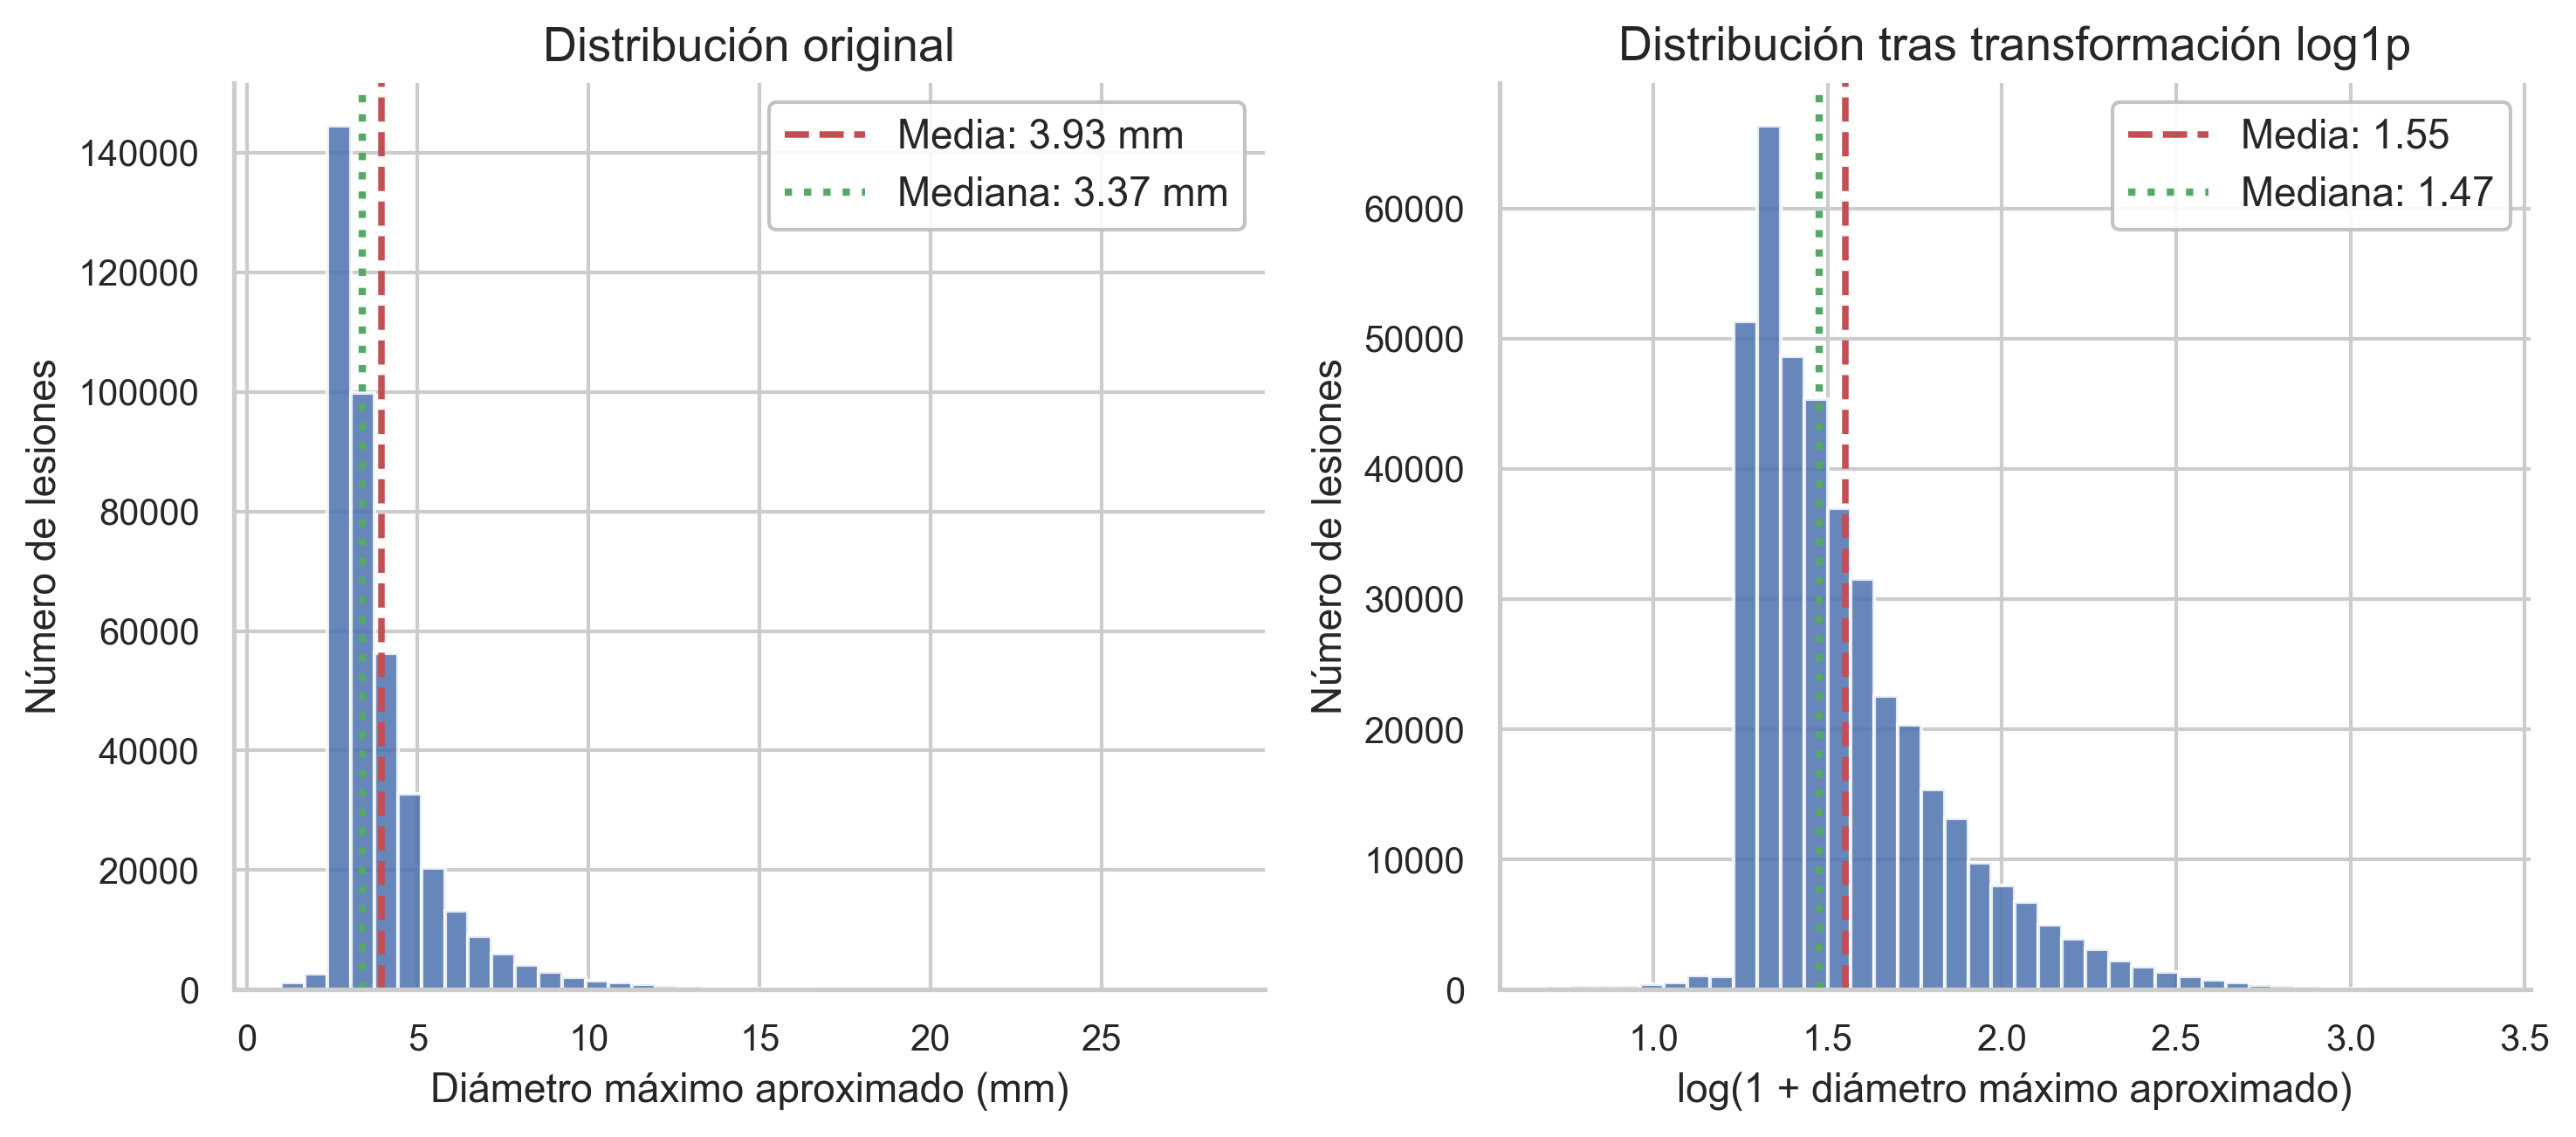

In [144]:
figures["size_distribution"]

Figura XX. Distribución de `clin_size_long_diam_mm` en su escala original y tras aplicar una transformación `log1p`. Las líneas verticales representan la media (roja) y la mediana (verde) de cada distribución.

En cuanto a los valores extremos, la aplicación de la regla de 1.5 × IQR establece un límite inferior de 0.53 mm y un límite superior de 6.69 mm. Dado que el valor mínimo observado es de 1.00 mm, no se identifican outliers inferiores. Por el contrario, 27,365 lesiones, equivalentes al 6.82% del conjunto de datos, presentan un diámetro igual o superior al límite superior.

| Criterio              |         Valor |
| --------------------- | ------------: |
| Límite inferior       |       0.53 mm |
| Límite superior       |       6.69 mm |
| Outliers (n)          |        27,365 |
| Outliers (%)          |          6.82 |
| Rango de los outliers | 6.69–28.40 mm |
| Lesiones >20 mm (n)   |            79 |

Tabla XX. Resumen de los valores extremos de `clin_size_long_diam_mm` según la regla de 1.5 × IQR.

La identificación estadística de estos valores como outliers no implica que sean errores de registro. Los diámetros observados son clínicamente plausibles, el valor máximo es de 28.40 mm y únicamente 79 lesiones superan los 20 mm. Además, los valores elevados no se distribuyen de forma aleatoria entre las categorías diagnósticas, sino que aparecen con mayor frecuencia entre las lesiones biopsiadas.

| Categoría diagnóstica     | Lesiones (n) | Media ± DE (mm) | Mediana [IQR] (mm) | Outliers (n) | Outliers (%) |
| ------------------------- | -----------: | --------------: | -----------------: | -----------: | -----------: |
| Benignas no biopsiadas    |      399,991 |     3.93 ± 1.73 |   3.37 [2.84–4.38] |       27,035 |         6.76 |
| Benignas biopsiadas       |          561 |     5.67 ± 3.16 |   5.13 [3.40–7.31] |          169 |        30.12 |
| Indeterminadas biopsiadas |          114 |     4.98 ± 3.22 |   4.18 [2.60–6.64] |           28 |        24.56 |
| Malignas biopsiadas       |          393 |     5.75 ± 3.90 |   5.14 [2.40–7.87] |          133 |        33.84 |

Tabla XX. Distribución de clin_size_long_diam_mm y frecuencia de valores extremos según la categoría diagnóstica. DE: desviación estándar; IQR: rango intercuartílico. Los outliers se definen mediante el límite superior de 6.69 mm calculado para el conjunto completo.

Las lesiones biopsiadas presentan medias, medianas y dispersiones superiores a las lesiones benignas no biopsiadas. Asimismo, la proporción de outliers se sitúa entre el 24.56% y el 33.84% en las categorías biopsiadas, frente al 6.76% en las lesiones benignas no biopsiadas. Este patrón indica que los valores elevados pueden contener información clínica y predictiva relevante, por lo que no se recomienda eliminarlos ni truncarlos de forma automática.

Se evalua también formalmente la relación entre el tamaño de la lesión y las variables objetivo de las dos hipótesis de modelado. 

| Análisis                              | Mediana grupo negativo (mm) | Mediana grupo positivo (mm) | Mann–Whitney p | Correlación punto-biserial | Spearman | Interpretación                |
| ------------------------------------- | --------------------------: | --------------------------: | -------------: | -------------------------: | -------: | ----------------------------- |
| Tamaño vs biopsia                     |                        3.37 |                        5.10 |        <0.0001 |                     0.0502 |   0.0261 | Asociación positiva muy débil |
| Tamaño vs malignidad entre biopsiadas |                        5.08 |                        5.14 |         0.6653 |                     0.0276 |  -0.0132 | Asociación prácticamente nula |

Tabla XX. Asociación entre `clin_size_long_diam_mm` y las variables objetivo de las dos hipótesis de modelado. En la primera hipótesis, el grupo negativo corresponde a lesiones benignas no biopsiadas y el grupo positivo a lesiones biopsiadas. En la segunda, el grupo negativo incluye lesiones biopsiadas benignas o indeterminadas y el grupo positivo lesiones biopsiadas malignas.

La comparación entre grupos se realiza mediante la prueba de Mann–Whitney U, dado que la distribución del tamaño presenta una marcada asimetría positiva, una cola derecha prolongada y tamaños de grupo muy diferentes. Debido al elevado tamaño muestral de la primera hipótesis, diferencias pequeñas entre las distribuciones pueden producir valores p muy bajos. Por este motivo, la interpretación se basa principalmente en la magnitud de las asociaciones.

La correlación punto-biserial evalúa la asociación lineal entre una variable cuantitativa y un target binario, mientras que Spearman permite detectar una relación monotónica sin asumir linealidad ni normalidad. La concordancia entre ambas medidas ayuda a determinar si el patrón observado es consistente y potencialmente relevante desde el punto de vista predictivo.

Las lesiones biopsiadas presentan un tamaño mediano claramente superior al de las lesiones benignas no biopsiadas (5.10 mm frente a 3.37 mm). Aunque la diferencia resulta estadísticamente significativa, tanto la correlación punto-biserial como la de Spearman son muy reducidas, lo que indica que la asociación global entre tamaño y biopsia es débil. No obstante, al agrupar las lesiones por intervalos se observa un incremento progresivo de la tasa de biopsia a partir de los 5 mm, que alcanza el 2.64% en las lesiones de 15 mm o más. Este patrón sugiere que el tamaño puede aportar información complementaria para la clasificación, aunque su capacidad discriminativa individual es limitada.

Entre las lesiones biopsiadas, en cambio, no se observa una relación consistente entre tamaño y malignidad. Las medianas son prácticamente idénticas, el test de Mann–Whitney no resulta significativo y las dos medidas de asociación se sitúan próximas a cero. Las tasas de malignidad fluctúan entre los distintos intervalos de tamaño, pero sus intervalos de confianza muestran un solapamiento considerable y no se identifica una tendencia lineal o monotónica clara.


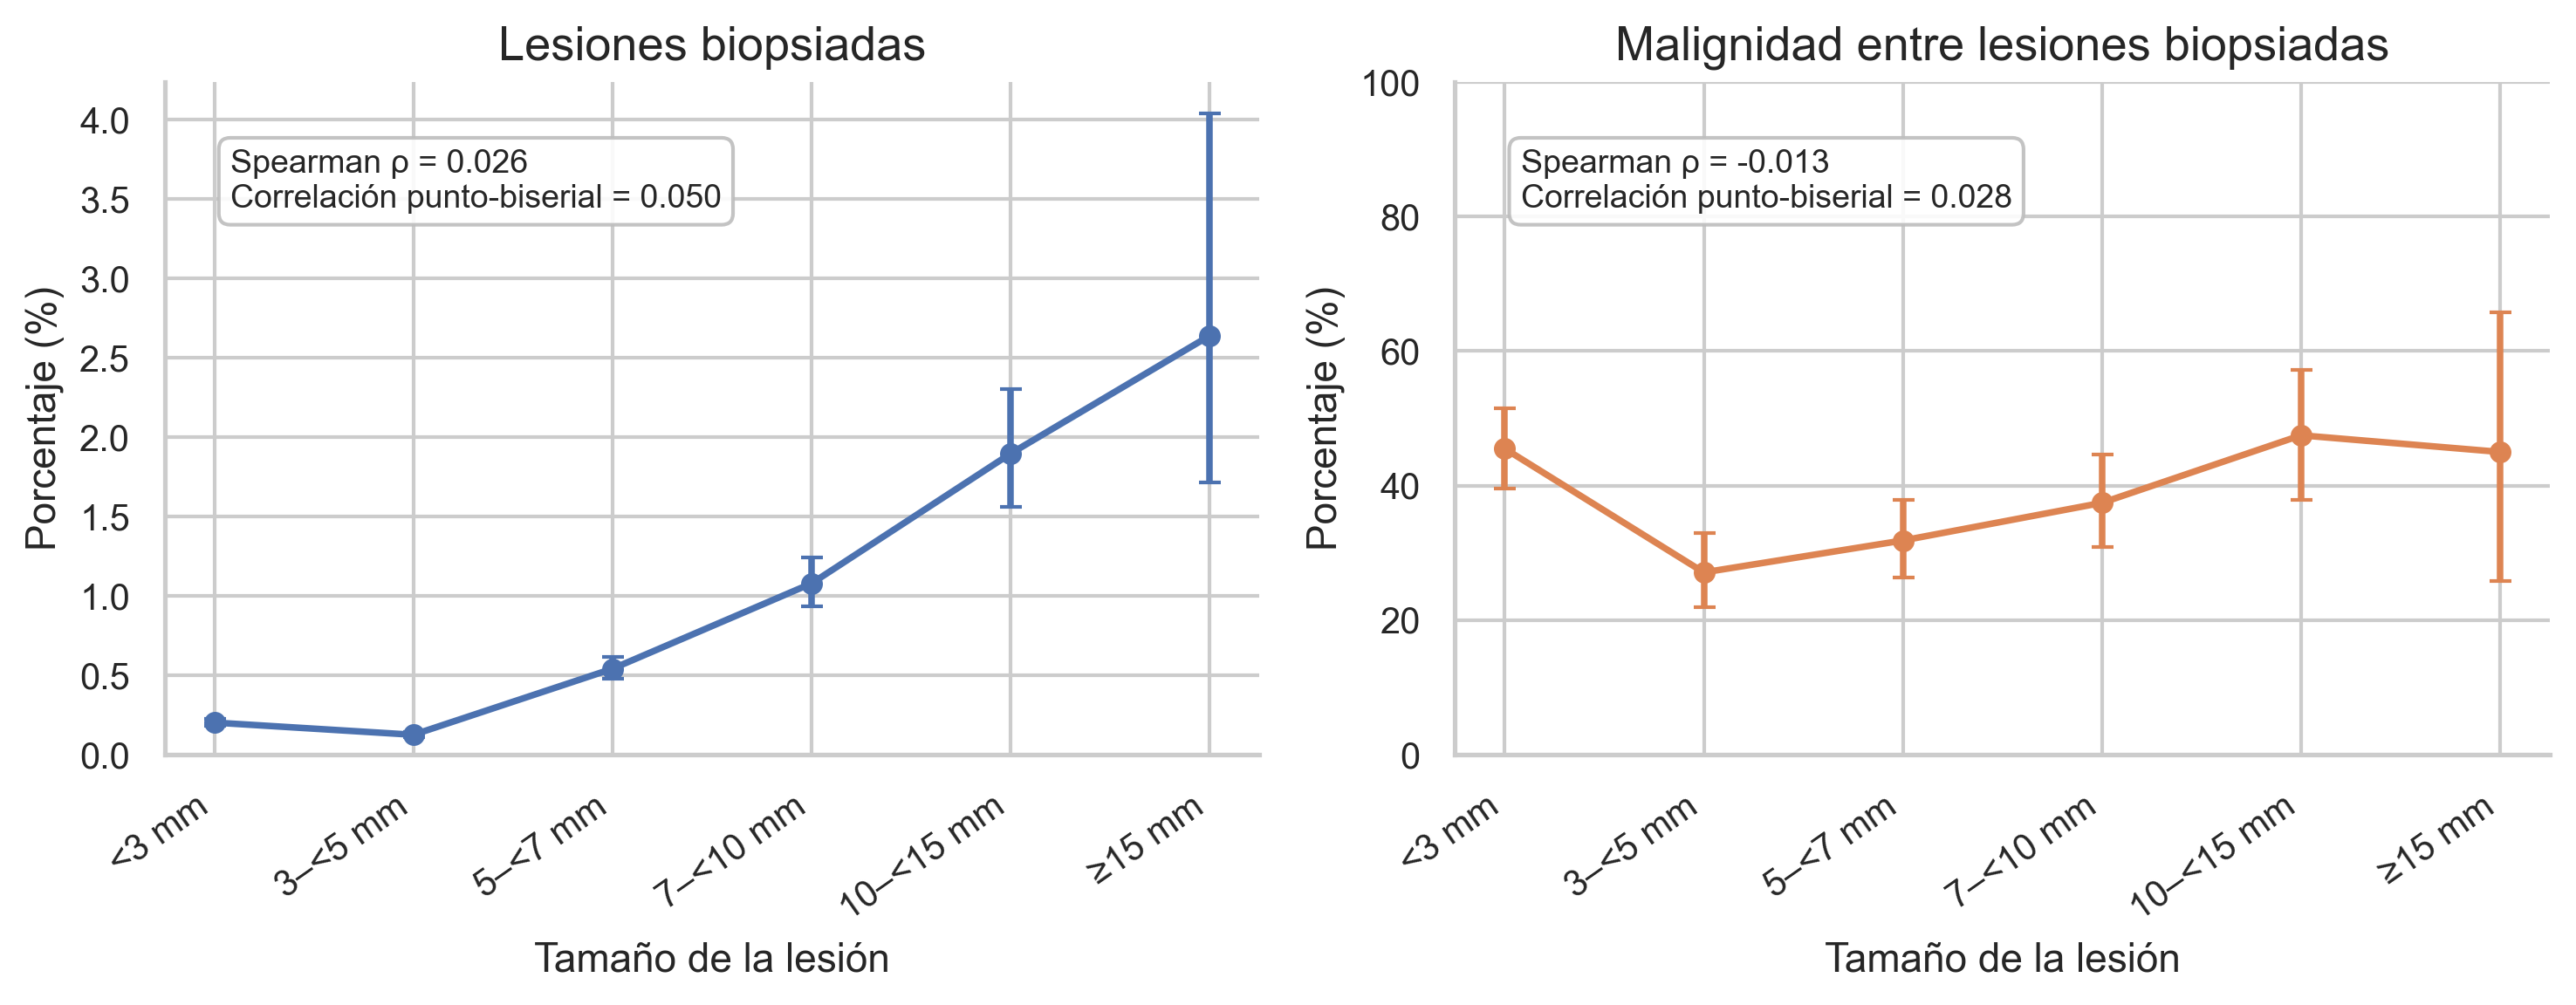

In [161]:
figures["size_predictive_value"]

Figura XX. Tasas de biopsia y malignidad según intervalos de tamaño de la lesión. El panel izquierdo muestra el porcentaje de lesiones biopsiadas en cada intervalo de tamaño y el panel derecho la proporción de malignidad entre las lesiones biopsiadas. Los puntos representan las proporciones observadas y las barras verticales sus intervalos de confianza del 95% calculados mediante el método de Wilson. Las anotaciones muestran las correlaciones de Spearman y punto-biserial para cada hipótesis.

En consecuencia, se recomienda conservar todos los valores de `clin_size_long_diam_mm` y no eliminar ni truncar automáticamente los valores extremos. La transformación de la variable deberá considerarse únicamente cuando lo requiera el algoritmo utilizado.

## Conclusión final